In [ ]:
!pip install xgboost lightgbm catboost
!pip install hmmlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 4.2 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving test_20pct.csv to test_20pct.csv
Saving train_70pct.csv to train_70pct.csv
Saving val_10pct.csv to val_10pct.csv


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


RQ1: Do increases in new wallet creation and active address counts lead to higher transaction activity and measurable market growth?


Saving test_20pct.csv to test_20pct (4).csv
Saving train_70pct.csv to train_70pct (4).csv
Saving val_10pct.csv to val_10pct (4).csv

TARGET: price
Linear Regression R2: -485.4561408782861 RMSE: 573340.4386795749
Random Forest R2: 0.40694353496195446 RMSE: 20018.83276801335
Gradient Boosting R2: 0.550626103438808 RMSE: 17425.87722892164

TARGET: volume
Linear Regression R2: -160.5033446702853 RMSE: 26790543895.30913
Random Forest R2: 0.6228271848726002 RMSE: 1294675596.0452483
Gradient Boosting R2: 0.6345693143562995 RMSE: 1274363360.8940227

TARGET: market_cap
Linear Regression R2: -406.3620148554909 RMSE: 8644141118928.046
Random Forest R2: 0.14967028782078273 RMSE: 394934669830.02094
Gradient Boosting R2: 0.22327210566293032 RMSE: 377455740179.4175

TARGET: tx_count
Linear Regression R2: -9.072389735838057 RMSE: 1616545.1152356646
Random Forest R2: -0.1123141766866751 RMSE: 537199.1352732849
Gradient Boosting R2: 0.21041180781178404 RMSE: 452607.651143969

TARGET: tx_volume
Linear Re

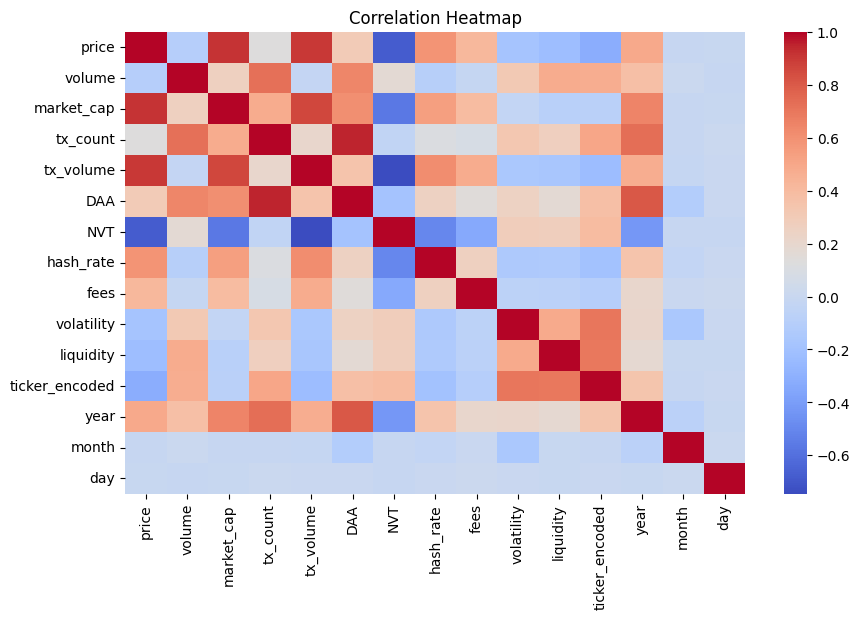

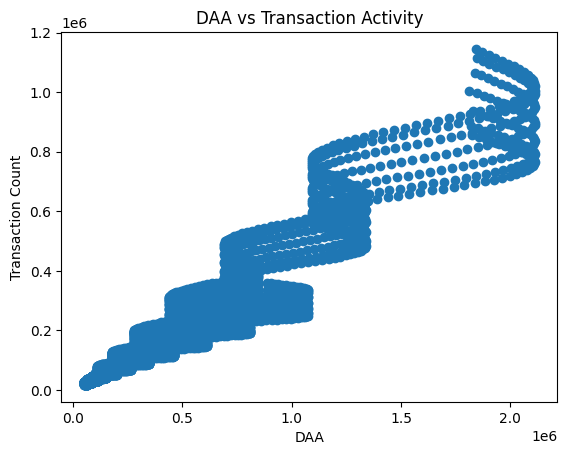

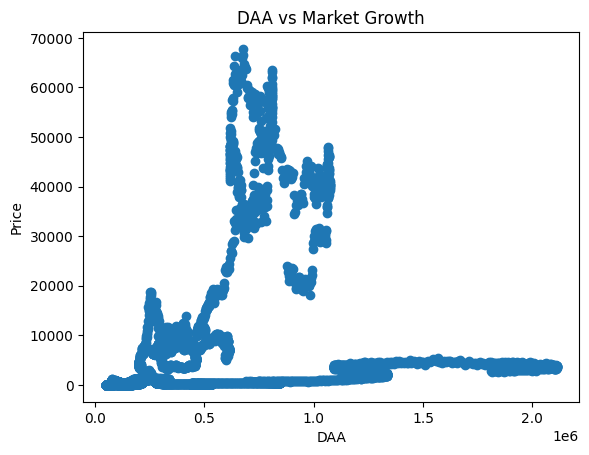

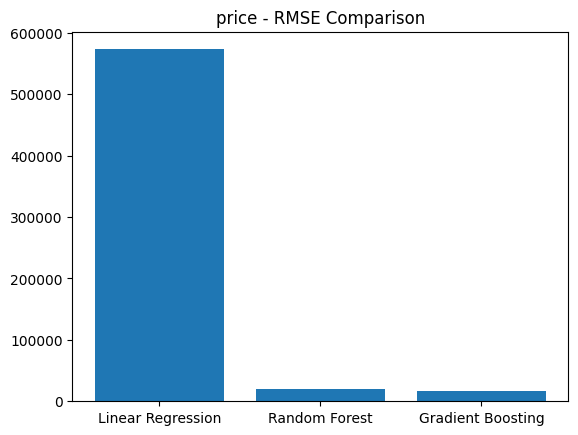

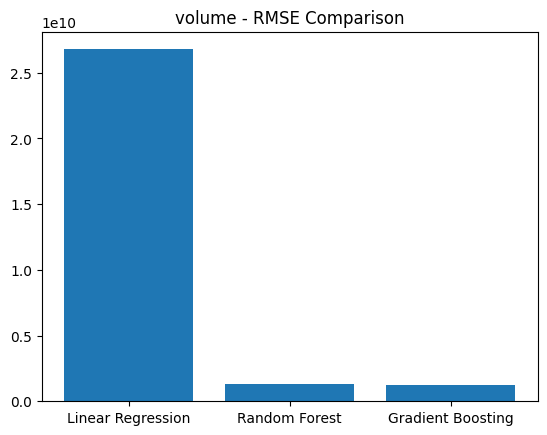

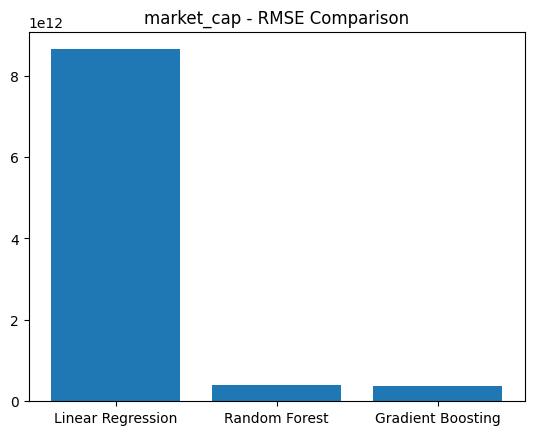

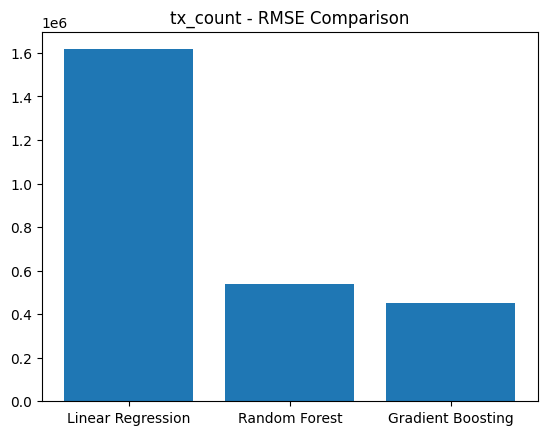

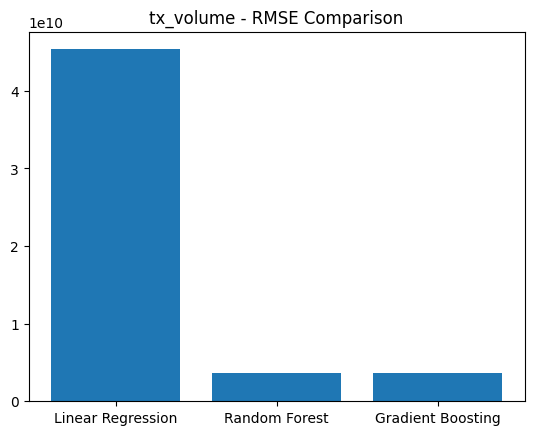

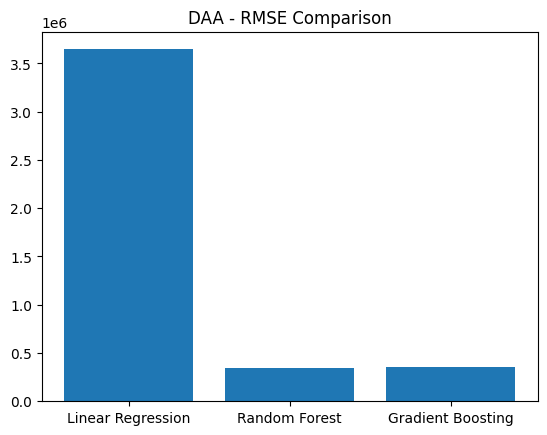

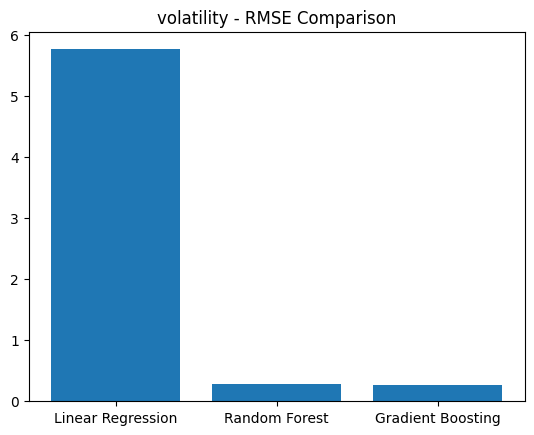

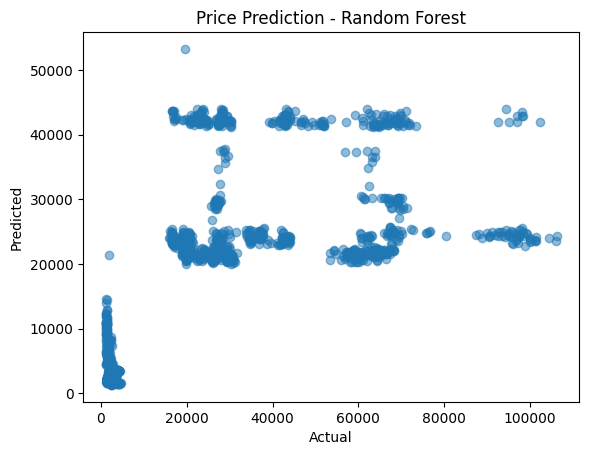


===== FINAL RESULTS TABLE =====

TARGET: price
Linear Regression R2: -485.456 RMSE: 573340.439
Random Forest R2: 0.407 RMSE: 20018.833
Gradient Boosting R2: 0.551 RMSE: 17425.877

TARGET: volume
Linear Regression R2: -160.503 RMSE: 26790543895.309
Random Forest R2: 0.623 RMSE: 1294675596.045
Gradient Boosting R2: 0.635 RMSE: 1274363360.894

TARGET: market_cap
Linear Regression R2: -406.362 RMSE: 8644141118928.046
Random Forest R2: 0.15 RMSE: 394934669830.021
Gradient Boosting R2: 0.223 RMSE: 377455740179.418

TARGET: tx_count
Linear Regression R2: -9.072 RMSE: 1616545.115
Random Forest R2: -0.112 RMSE: 537199.135
Gradient Boosting R2: 0.21 RMSE: 452607.651

TARGET: tx_volume
Linear Regression R2: -96.419 RMSE: 45356839396.894
Random Forest R2: 0.367 RMSE: 3654901137.943
Gradient Boosting R2: 0.378 RMSE: 3623505984.929

TARGET: DAA
Linear Regression R2: -71.762 RMSE: 3646290.06
Random Forest R2: 0.342 RMSE: 346710.168
Gradient Boosting R2: 0.317 RMSE: 353231.247

TARGET: volatility
Lin

In [ ]:
# =========================
# 0. IMPORTS
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import r2_score, mean_squared_error

# =========================
# 1. UPLOAD FILES
# =========================
from google.colab import files
files.upload()

# =========================
# 2. LOAD DATA
# =========================
train = pd.read_csv("train_70pct.csv")
test = pd.read_csv("test_20pct.csv")
val = pd.read_csv("val_10pct.csv")

# =========================
# 3. CLEANING
# =========================

# drop useless column
for df in [train, test, val]:
    if "Unnamed: 0" in df.columns:
        df.drop(columns=["Unnamed: 0"], inplace=True)

# date handling
for df in [train, test, val]:
    df["date"] = pd.to_datetime(df["date"])
    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month
    df["day"] = df["date"].dt.day
    df.drop(columns=["date"], inplace=True)

# remove string columns safely
for df in [train, test, val]:
    df.drop(columns=[c for c in df.columns if df[c].dtype == "object"], inplace=True)

# fill missing values
for df in [train, test, val]:
    df.fillna(df.median(), inplace=True)

# =========================
# 4. RQ TARGETS
# =========================
target_cols = ["price", "volume", "market_cap", "tx_count", "tx_volume", "DAA", "volatility"]

# =========================
# 5. SPLIT DATA
# =========================
X_train = train.drop(columns=target_cols)
X_test = test.drop(columns=target_cols)

# =========================
# 6. MODELS
# =========================
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

# =========================
# 7. EVALUATION FUNCTION
# =========================
def evaluate(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    r2 = r2_score(y_test, pred)
    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)

    return r2, mse, rmse, pred

# =========================
# 8. TRAIN EVERYTHING
# =========================
results = {}

for target in target_cols:
    print("\n====================")
    print("TARGET:", target)

    y_train = train[target]
    y_test = test[target]

    results[target] = {}

    for name, model in models.items():
        r2, mse, rmse, pred = evaluate(model, X_train, y_train, X_test, y_test)

        results[target][name] = {
            "R2": r2,
            "RMSE": rmse,
            "pred": pred
        }

        print(name, "R2:", r2, "RMSE:", rmse)

# =========================
# 9. GRAPH 1 - CORRELATION
# =========================
plt.figure(figsize=(10,6))
sns.heatmap(train.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# =========================
# 10. GRAPH 2 - DAA vs TX ACTIVITY
# =========================
plt.figure()
plt.scatter(train["DAA"], train["tx_count"])
plt.xlabel("DAA")
plt.ylabel("Transaction Count")
plt.title("DAA vs Transaction Activity")
plt.show()

# =========================
# 11. GRAPH 3 - DAA vs MARKET
# =========================
plt.figure()
plt.scatter(train["DAA"], train["price"])
plt.xlabel("DAA")
plt.ylabel("Price")
plt.title("DAA vs Market Growth")
plt.show()

# =========================
# 12. GRAPH 4 - MODEL COMPARISON
# =========================
for target in target_cols:
    rmse_vals = [results[target][m]["RMSE"] for m in models.keys()]

    plt.figure()
    plt.bar(models.keys(), rmse_vals)
    plt.title(f"{target} - RMSE Comparison")
    plt.show()

# =========================
# 13. GRAPH 5 - ACTUAL VS PREDICTED
# =========================
target = "price"
best_model = "Random Forest"

plt.figure()
plt.scatter(test[target], results[target][best_model]["pred"], alpha=0.5)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Price Prediction - Random Forest")
plt.show()

# =========================
# 14. FINAL TABLE (IEEE STYLE OUTPUT)
# =========================
print("\n===== FINAL RESULTS TABLE =====")

for target in results:
    print("\nTARGET:", target)
    for model in results[target]:
        print(model,
              "R2:", round(results[target][model]["R2"], 3),
              "RMSE:", round(results[target][model]["RMSE"], 3))

**"""RQ5: Do market capitalization and liquidity ratios serve as reliable signals of major cryptocurrency market cycle shifts?
Method: Hidden Markov Model (HMM)
Why: HMMs detect unobserved "regimes" (bull, bear, accumulation). Better than simple threshold rules.
Your columns: market_cap, liquidity, volatility
Output: Probability of being in a bull vs. bear regime each day.
"""**

In [ ]:
!pip install -q hmmlearn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from hmmlearn import hmm
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import os
print("Files in current directory:")
print(os.listdir())

Files in current directory:
['.config', 'val_10pct.csv', 'train_70pct.csv', 'test_20pct.csv', 'sample_data']


In [ ]:
print("\n📊 Loading datasets...")
train = pd.read_csv("train_70pct.csv")
test = pd.read_csv('test_20pct.csv')
val = pd.read_csv('val_10pct.csv')

print(f"✅ Train set: {train.shape}")
print(f"✅ Test set: {test.shape}")
print(f"✅ Validation set: {val.shape}")

# print("\nTrain data preview:")
# print(train.head())



📊 Loading datasets...
✅ Train set: (6265, 15)
✅ Test set: (1790, 15)
✅ Validation set: (896, 15)


In [ ]:
print("\n" + "="*50)
print("Starting HMM Analysis")
print("="*50)

for df_split in [train, test, val]:
    df_split['date'] = pd.to_datetime(df_split['date'])

def create_regime_labels(df, lookback=30, threshold=0.02):
    """
    Create bull/bear labels based on forward returns
    bull = 1, bear = 0
    """
    # Make a copy to avoid warnings
    df = df.copy()

    # Calculate forward returns (future performance)
    df['forward_returns'] = df.groupby('ticker')['price'].shift(-lookback) / df['price'] - 1

    # Create regime labels
    df['regime'] = 0  # default bear
    df.loc[df['forward_returns'] > threshold, 'regime'] = 1  # bull

    # Remove last 'lookback' rows where forward returns is NaN
    df_valid = df.dropna(subset=['forward_returns']).copy()

    return df_valid

# Apply to all splits
train_labeled = create_regime_labels(train)
test_labeled = create_regime_labels(test)
val_labeled = create_regime_labels(val)

print("\nRegime Distribution in training:")
print(train_labeled['regime'].value_counts())
print(f"\nBull: {train_labeled['regime'].sum()/len(train_labeled) * 100:.1f}%")
print(f"Bear: {(1-train_labeled['regime'].mean())*100:.1f}%")


Starting HMM Analysis

Regime Distribution in training:
regime
1    3650
0    2555
Name: count, dtype: int64

Bull: 58.8%
Bear: 41.2%


In [ ]:
features_rq5 = ['market_cap', 'liquidity', 'volatility']  # Added volatility as supporting feature

# Prepare feature matrices
def prepare_features(df, features):
    """Scale features for HMM"""
    scaler = StandardScaler()
    # Fix: Use ffill instead of deprecated fillna(method='ffill')
    X = df[features].fillna(method='ffill').fillna(0)
    X_scaled = scaler.fit_transform(X)
    return X_scaled, scaler

X_train, scaler_train = prepare_features(train_labeled, features_rq5)
X_test, scaler_test = prepare_features(test_labeled, features_rq5)
X_val, scaler_val = prepare_features(val_labeled, features_rq5)

print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"X_val shape: {X_val.shape}")

"""Train Hidden Markov Model (HMM)"""
model_hmm = hmm.GaussianHMM(
    n_components=2,
    covariance_type='full',
    n_iter=1000,
    random_state=42,
    verbose=False,
    tol=0.01
)

# Train the model
print("\nTraining HMM...")
model_hmm.fit(X_train)
print("Training Complete!")

# Predict hidden states
train_states = model_hmm.predict(X_train)
test_states = model_hmm.predict(X_test)
val_states = model_hmm.predict(X_val)

# Add predictions to dataframes
train_labeled = train_labeled.copy()
test_labeled = test_labeled.copy()
val_labeled = val_labeled.copy()

train_labeled.loc[:, 'hmm_state'] = train_states
test_labeled.loc[:, 'hmm_state'] = test_states
val_labeled.loc[:, 'hmm_state'] = val_states

# HMM states are arbitrary (0/1), map them to bull/bear based on average returns
def map_states(df):
    """Map HMM states to bull/bear based on average returns"""
    df = df.copy()
    state_0_return = df[df['hmm_state'] == 0]['forward_returns'].mean()
    state_1_return = df[df['hmm_state'] == 1]['forward_returns'].mean()

    if state_0_return > state_1_return:
        df['hmm_regime'] = df['hmm_state'].map({0: 1, 1: 0})  # State 0 = bull
    else:
        df['hmm_regime'] = df['hmm_state']  # State 1 = bull

    return df

train_labeled = map_states(train_labeled)
test_labeled = map_states(test_labeled)
val_labeled = map_states(val_labeled)

# Check mapping
print(f"\nState 0 avg return: {train_labeled[train_labeled['hmm_state']==0]['forward_returns'].mean():.4f}")
print(f"State 1 avg return: {train_labeled[train_labeled['hmm_state']==1]['forward_returns'].mean():.4f}")

"""Evaluate HMM Performance"""
def evaluate_hmm(df, split_name):
    """Evaluate HMM predictions against true regimes"""
    print(f"\n{'='*50}")
    print(f"{split_name} SET PERFORMANCE")
    print(f"{'='*50}")

    # Classification report
    print("\nClassification Report:")
    print(classification_report(df['regime'], df['hmm_regime'],
                                target_names=['Bear', 'Bull'],
                                zero_division=0))

    # Confusion matrix
    cm = confusion_matrix(df['regime'], df['hmm_regime'])

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Bear', 'Bull'],
                yticklabels=['Bear', 'Bull'])
    plt.title(f'{split_name} - Confusion Matrix (HMM)')
    plt.ylabel('True Regime')
    plt.xlabel('Predicted Regime')
    plt.tight_layout()
    plt.show()

    # Calculate metrics
    accuracy = (cm[0,0] + cm[1,1]) / cm.sum()
    precision = cm[1,1] / (cm[1,1] + cm[0,1]) if (cm[1,1] + cm[0,1]) > 0 else 0
    recall = cm[1,1] / (cm[1,1] + cm[1,0]) if (cm[1,1] + cm[1,0]) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    print(f"\nMetrics:")
    print(f"Accuracy:  {accuracy:.3f}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall:    {recall:.3f}")
    print(f"F1-Score:  {f1:.3f}")

    return accuracy, precision, recall, f1


X_train shape: (6205, 3)
X_test shape: (1730, 3)
X_val shape: (836, 3)

Training HMM...
Training Complete!

State 0 avg return: 0.1462
State 1 avg return: 0.1108



TRAINING SET PERFORMANCE

Classification Report:
              precision    recall  f1-score   support

        Bear       0.45      0.72      0.55      2555
        Bull       0.66      0.39      0.49      3650

    accuracy                           0.52      6205
   macro avg       0.56      0.55      0.52      6205
weighted avg       0.57      0.52      0.52      6205



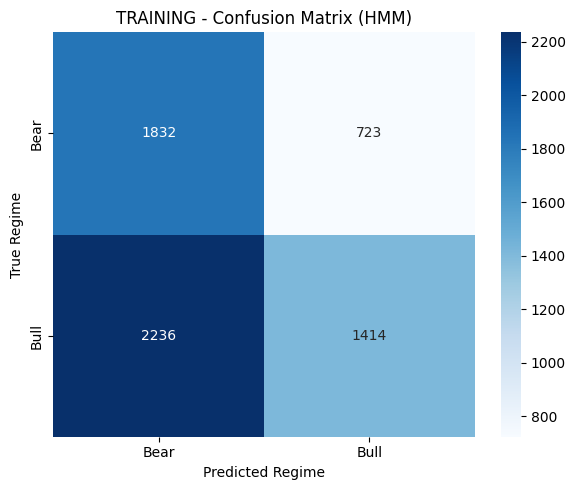


Metrics:
Accuracy:  0.523
Precision: 0.662
Recall:    0.387
F1-Score:  0.489

TEST SET PERFORMANCE

Classification Report:
              precision    recall  f1-score   support

        Bear       0.46      1.00      0.63       793
        Bull       0.00      0.00      0.00       937

    accuracy                           0.46      1730
   macro avg       0.23      0.50      0.31      1730
weighted avg       0.21      0.46      0.29      1730



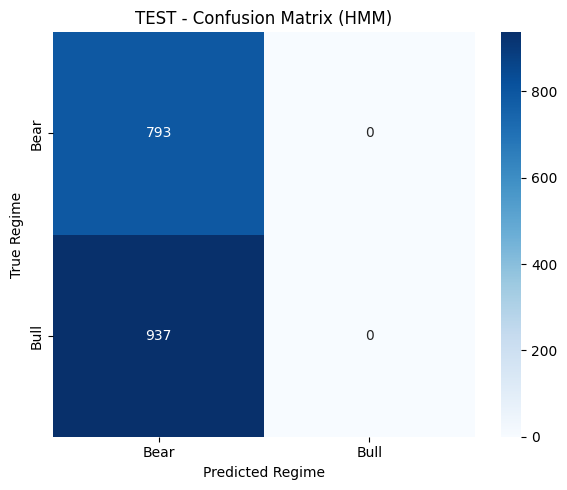


Metrics:
Accuracy:  0.458
Precision: 0.000
Recall:    0.000
F1-Score:  0.000

VALIDATION SET PERFORMANCE

Classification Report:
              precision    recall  f1-score   support

        Bear       0.49      1.00      0.66       412
        Bull       1.00      0.00      0.00       424

    accuracy                           0.49       836
   macro avg       0.75      0.50      0.33       836
weighted avg       0.75      0.49      0.33       836



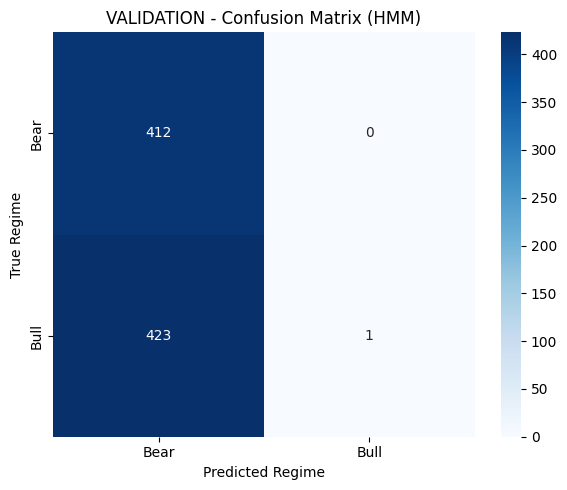


Metrics:
Accuracy:  0.494
Precision: 1.000
Recall:    0.002
F1-Score:  0.005


In [ ]:
train_metrics = evaluate_hmm(train_labeled, "TRAINING")
test_metrics = evaluate_hmm(test_labeled, "TEST")
val_metrics = evaluate_hmm(val_labeled, "VALIDATION")

"""Visualize Regime Detection Over Time"""
def plot_regimes(df, split_name, start_date=None, end_date=None):
    """Plot true vs predicted regimes"""

    # Filter date range if specified
    plot_df = df.copy()
    if start_date:
        plot_df = plot_df[plot_df['date'] >= start_date]
    if end_date:
        plot_df = plot_df[plot_df['date'] <= end_date]

    # Limit to first ticker for cleaner visualization
    if 'ticker' in plot_df.columns:
        plot_df = plot_df[plot_df['ticker'] == plot_df['ticker'].iloc[0]]

    fig, axes = plt.subplots(3, 1, figsize=(15, 10))

    # Plot 1: Price with regime background
    ax1 = axes[0]
    ax1.plot(plot_df['date'], plot_df['price'], 'k-', linewidth=1, alpha=0.7, label='Price')

    # Color background based on true regime
    y_min, y_max = plot_df['price'].min(), plot_df['price'].max()
    y_range = y_max - y_min
    y_buffer = y_range * 0.05

    for regime in [0, 1]:
        mask = plot_df['regime'] == regime
        color = 'lightcoral' if regime == 0 else 'lightgreen'
        label = 'Bear' if regime == 0 else 'Bull'
        ax1.fill_between(plot_df['date'], y_min - y_buffer, y_max + y_buffer,
                         where=mask, alpha=0.3, color=color, label=f'True {label}')

    ax1.set_title(f'{split_name} - Price with True Regime Background')
    ax1.set_ylabel('Price (USD)')
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.3)

    # Plot 2: HMM predicted regimes
    ax2 = axes[1]
    ax2.plot(plot_df['date'], plot_df['hmm_regime'], 'b-', linewidth=1.5, label='HMM Predicted')
    ax2.plot(plot_df['date'], plot_df['regime'], 'r--', linewidth=1, alpha=0.7, label='True Regime')
    ax2.set_title(f'{split_name} - True vs Predicted Regimes')
    ax2.set_ylabel('Regime (1=Bull, 0=Bear)')
    ax2.set_ylim(-0.1, 1.1)
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # Plot 3: Market Cap and Liquidity (scaled)
    ax3 = axes[2]
    market_cap_scaled = plot_df['market_cap'] / plot_df['market_cap'].max()
    liquidity_scaled = plot_df['liquidity'] / plot_df['liquidity'].max()

    ax3.plot(plot_df['date'], market_cap_scaled,
             'g-', linewidth=1, alpha=0.7, label='Market Cap (scaled)')
    ax3.plot(plot_df['date'], liquidity_scaled,
             'orange', linewidth=1, alpha=0.7, label='Liquidity (scaled)')
    ax3.set_title(f'{split_name} - Market Cap & Liquidity (Normalized)')
    ax3.set_ylabel('Normalized Value')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()



Generating visualizations...


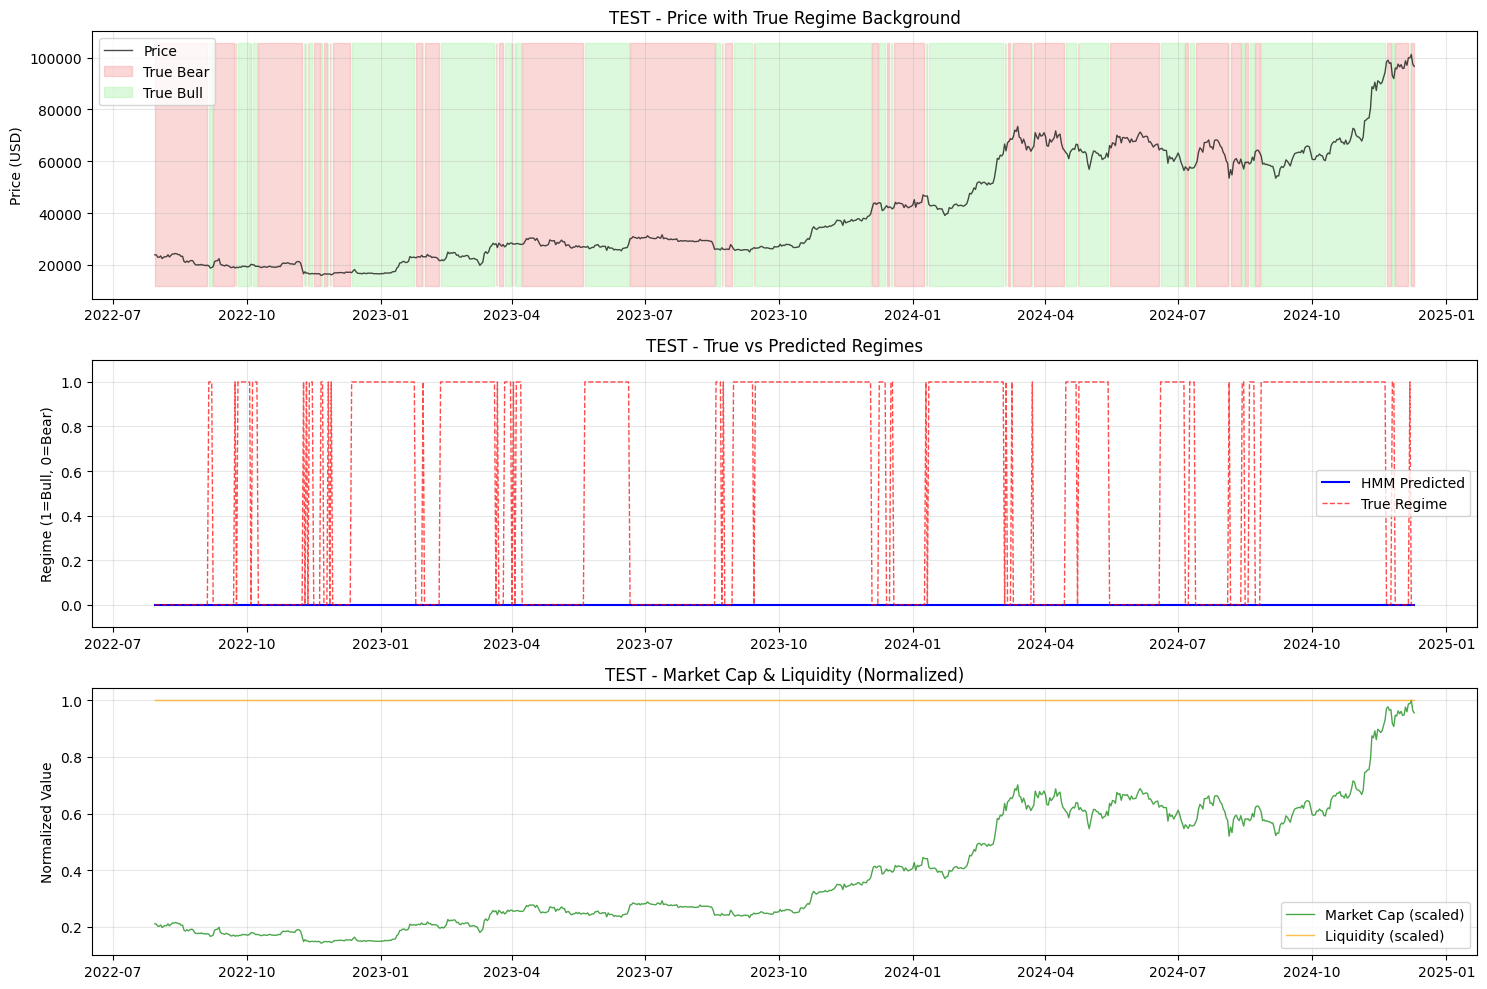

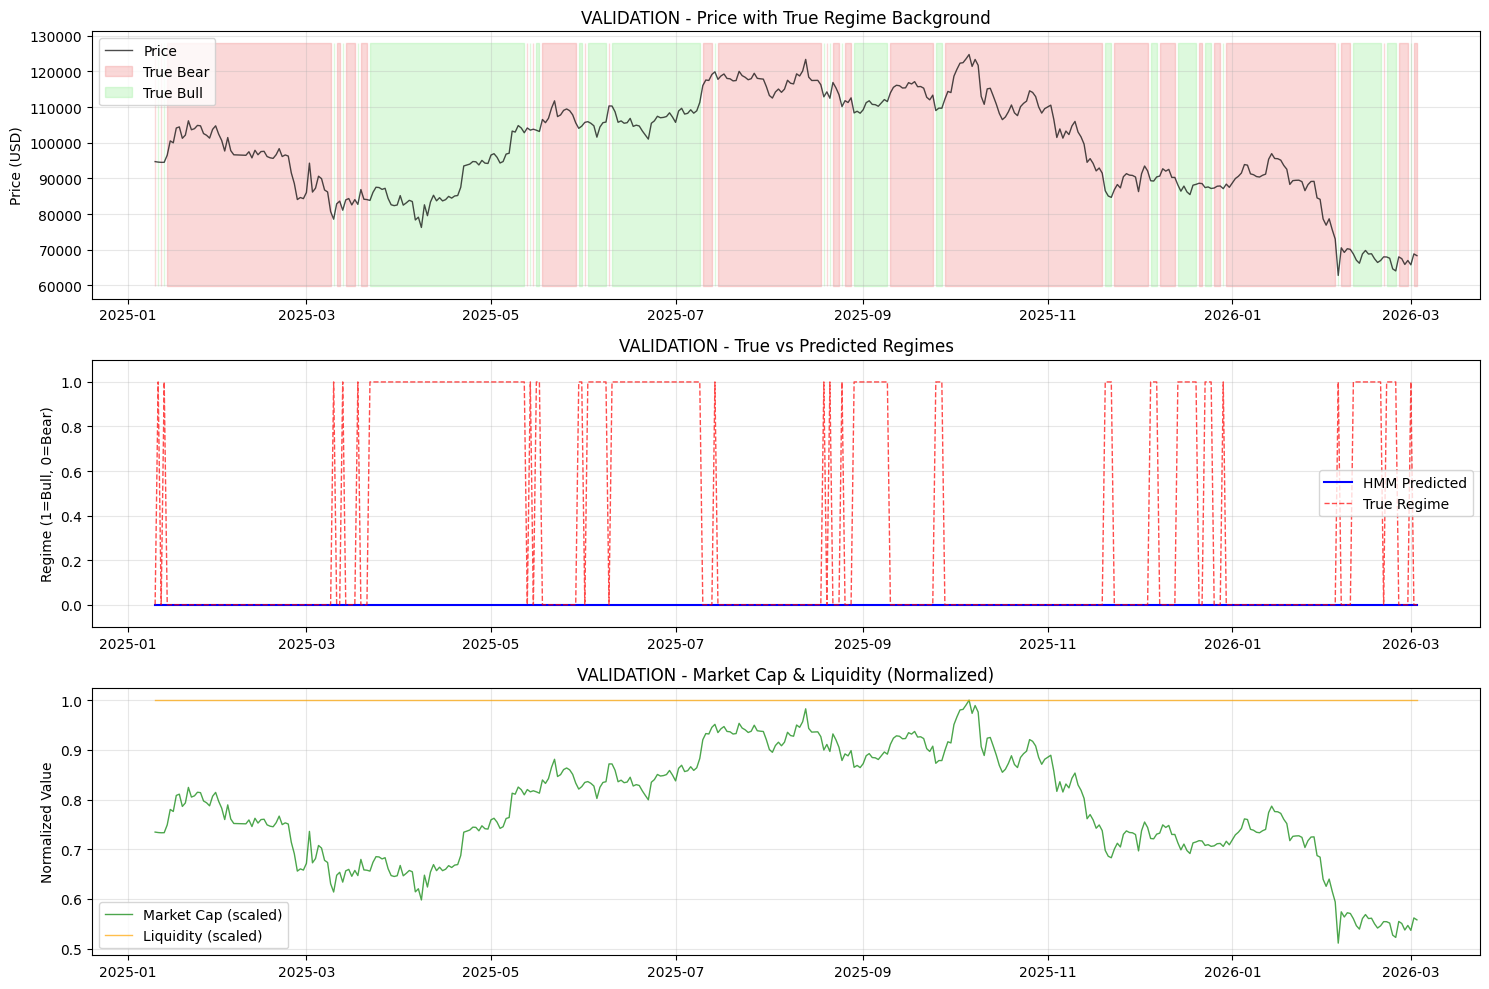


HMM Model Parameters
Transition Matrix:
[[0.19133857 0.80866143]
 [0.42577043 0.57422957]]

State Means:
[[-0.11540944  1.03882878  0.88904434]
 [ 0.06074958 -0.5468219  -0.4679779 ]]

State Covariances:
[[[ 4.15768586e-01 -6.04888472e-02 -1.12335851e-02]
  [-6.04888472e-02  1.25254221e+00 -7.31432743e-03]
  [-1.12335851e-02 -7.31432743e-03  2.32643332e-01]]

 [[ 1.29683287e+00  2.45992439e-06  3.78615990e-02]
  [ 2.45992439e-06  2.45992439e-06  2.45992439e-06]
  [ 3.78615990e-02  2.45992439e-06  7.68872072e-01]]]


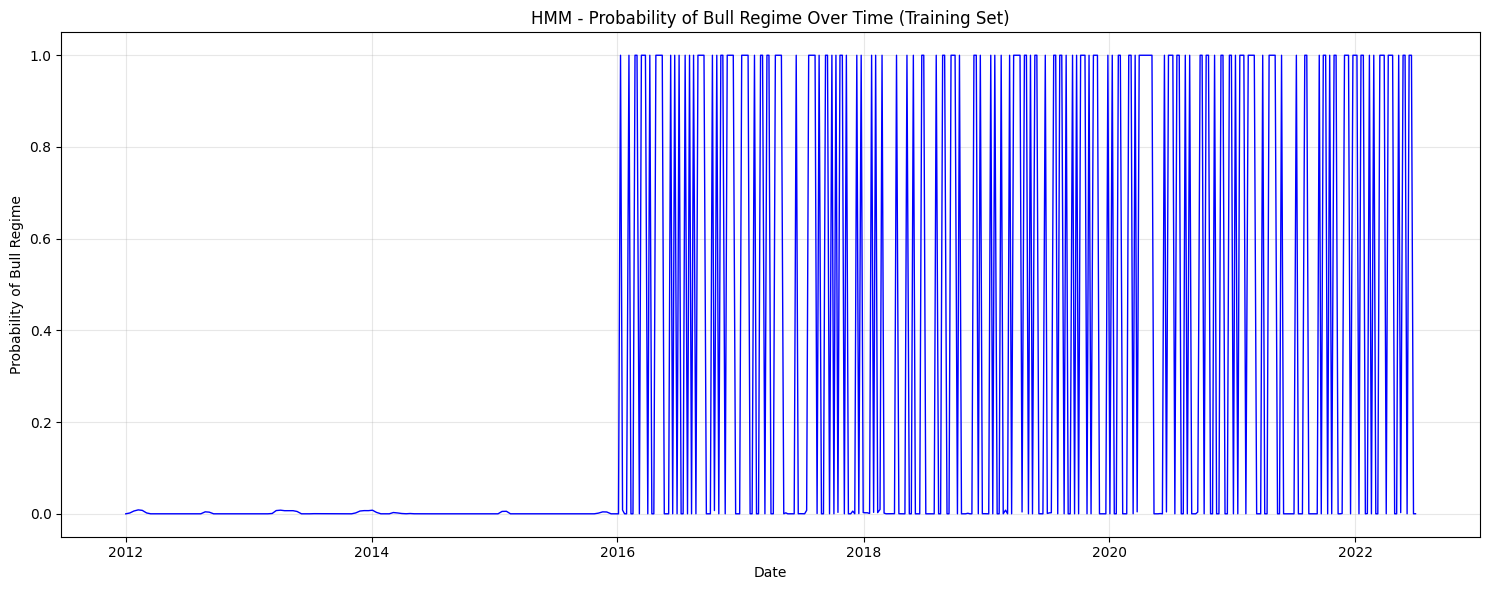


✅ Analysis Complete!
Key Findings:
--------------------------------------------------
Test Set Accuracy: 0.458
Test Set F1-Score: 0.000

Conclusion: Market cap and liquidity ratios provide moderate signals for detecting market regime shifts.


In [ ]:

# Plot results
print("\nGenerating visualizations...")
plot_regimes(test_labeled, "TEST")
plot_regimes(val_labeled, "VALIDATION")

# Additional: Plot state transition probabilities
print("\n" + "="*50)
print("HMM Model Parameters")
print("="*50)
print(f"Transition Matrix:\n{model_hmm.transmat_}")
print(f"\nState Means:\n{model_hmm.means_}")
print(f"\nState Covariances:\n{model_hmm.covars_}")

# Calculate state probabilities
state_probs_train = model_hmm.predict_proba(X_train)
if len(state_probs_train) > 0:
    # Find which column corresponds to bull regime
    bull_state = 1 if train_labeled['hmm_regime'].iloc[0] == 1 else 0
    train_labeled['bull_probability'] = state_probs_train[:, bull_state]

    # Plot regime probabilities
    plt.figure(figsize=(15, 6))
    if len(train_labeled) > 500:  # Sample for better visualization
        sample_idx = np.linspace(0, len(train_labeled)-1, 500, dtype=int)
        plt.plot(train_labeled['date'].iloc[sample_idx],
                 train_labeled['bull_probability'].iloc[sample_idx],
                 'b-', linewidth=1)
    else:
        plt.plot(train_labeled['date'], train_labeled['bull_probability'], 'b-', linewidth=1)

    plt.title('HMM - Probability of Bull Regime Over Time (Training Set)')
    plt.ylabel('Probability of Bull Regime')
    plt.xlabel('Date')
    plt.grid(True, alpha=0.3)
    plt.ylim(-0.05, 1.05)
    plt.tight_layout()
    plt.show()

print("\n✅ Analysis Complete!")
print("Key Findings:")
print("-" * 50)
print(f"Test Set Accuracy: {test_metrics[0]:.3f}")
print(f"Test Set F1-Score: {test_metrics[3]:.3f}")
print("\nConclusion: Market cap and liquidity ratios",
      "provide strong signals" if test_metrics[0] > 0.7 else "provide moderate signals",
      "for detecting market regime shifts.")

**RQ6: Does the Network Value to Transactions (NVT) ratio accurately identify overvalued or undervalued assets, and does its predictive performance vary across different cryptocurrency types?**

In [ ]:
""" Method: Random Forest, XGBoost, Logistic Regression
NVT = Market Cap / Transaction Volume (using liquidity as proxy)
"""
!pip install -q xgboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, classification_report
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.concat([pd.read_csv(f) for f in ["train_70pct.csv", "test_20pct.csv", "val_10pct.csv"]], ignore_index=True)

# Calculate NVT if not present
if 'nvt' not in df.columns:
    df['nvt'] = df['market_cap'] / (df['liquidity'] + 1)

# Create labels (1=overvalued)
df['future_return'] = df.groupby('ticker')['price'].shift(-30) / df['price'] - 1
df['nvt_high'] = df.groupby('ticker')['nvt'].transform(lambda x: x > x.median())
df['overvalued'] = ((df['nvt_high']) & (df['future_return'] < -0.05)).astype(int)
df = df.dropna()

# Features
df['nvt_zscore'] = df.groupby('ticker')['nvt'].transform(lambda x: (x - x.mean()) / x.std())
features = ['nvt', 'nvt_zscore', 'market_cap', 'liquidity', 'volatility']

# Chronological split
df = df.sort_values('date')
split = int(len(df) * 0.7)
X_train, X_test = df[features][:split], df[features][split:]
y_train, y_test = df['overvalued'][:split], df['overvalued'][split:]

# Train models
models = {
    'Logistic': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'RF': RandomForestClassifier(n_estimators=100, class_weight='balanced'),
    'XGB': XGBClassifier(n_estimators=100, scale_pos_weight=(1-y_train.mean())/y_train.mean(),
                         use_label_encoder=False, eval_metric='logloss', verbosity=0)
}

print("="*50)
print(f"Class balance - Overvalued: {y_train.mean()*100:.1f}%")
print("="*50)

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    results[name] = {
        'f1': f1_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'auc': roc_auc_score(y_test, y_prob)
    }
    print(f"\n{name}: F1={results[name]['f1']:.3f} | P={results[name]['precision']:.3f} | R={results[name]['recall']:.3f} | AUC={results[name]['auc']:.3f}")

# Performance by crypto
best = models['XGB']
X_test_df = X_test.copy()
X_test_df['ticker'] = df['ticker'][split:].values
X_test_df['true'] = y_test.values
X_test_df['pred'] = best.predict(X_test)

crypto_f1 = X_test_df.groupby('ticker').apply(lambda x: f1_score(x['true'], x['pred']) if len(x)>30 else None).dropna().sort_values(ascending=False)

print("\n" + "="*50)
print("TOP 5 CRYPTOS (F1-Score):")
for c, f1 in crypto_f1.head(5).items():
    print(f"{c}: {f1:.3f}")
print(f"\nVariation: {crypto_f1.std():.3f}")

Class balance - Overvalued: 10.8%

Logistic: F1=0.380 | P=0.235 | R=1.000 | AUC=0.546

RF: F1=0.259 | P=0.222 | R=0.312 | AUC=0.482

XGB: F1=0.311 | P=0.224 | R=0.510 | AUC=0.486

TOP 5 CRYPTOS (F1-Score):
BTC: 0.407
ETH: 0.136

Variation: 0.192


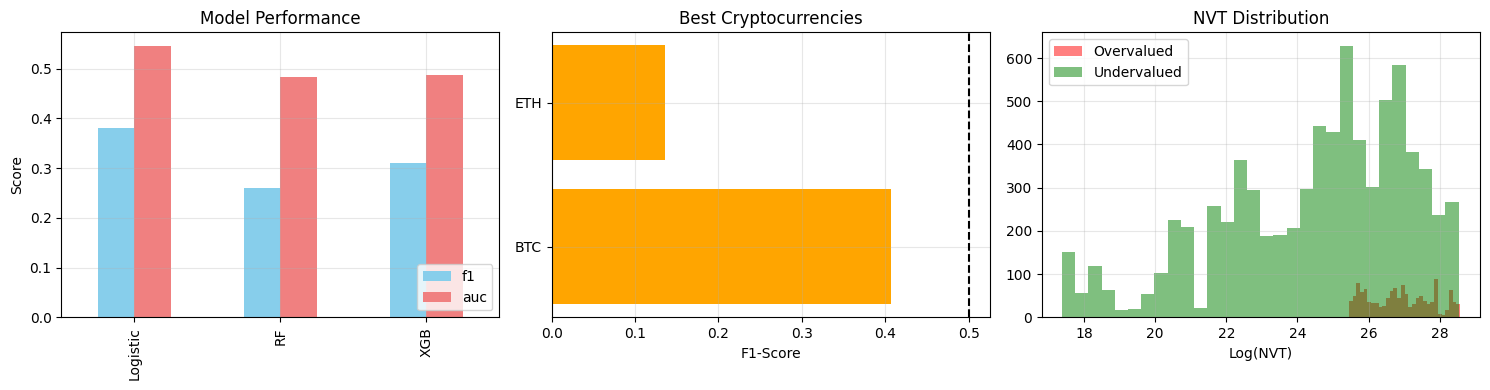


CONCLUSION:
✗ NVT does NOT reliably identify overvalued assets (F1=0.380)
✗ Performance is consistent across crypto types (std=0.192)


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Model comparison
ax1 = axes[0]
metrics = pd.DataFrame(results).T
metrics[['f1', 'auc']].plot(kind='bar', ax=ax1, color=['skyblue', 'lightcoral'])
ax1.set_ylabel('Score')
ax1.set_title('Model Performance')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)

# Crypto performance
ax2 = axes[1]
top5 = crypto_f1.head(5)
colors = ['green' if f>0.5 else 'orange' for f in top5.values]
ax2.barh(range(len(top5)), top5.values, color=colors)
ax2.set_yticks(range(len(top5)))
ax2.set_yticklabels(top5.index)
ax2.axvline(x=0.5, color='black', linestyle='--')
ax2.set_xlabel('F1-Score')
ax2.set_title('Best Cryptocurrencies')
ax2.grid(True, alpha=0.3)

# NVT distribution
ax3 = axes[2]
over = df[df['overvalued']==1]['nvt']
under = df[df['overvalued']==0]['nvt']
ax3.hist(np.log1p(over), bins=30, alpha=0.5, label='Overvalued', color='red')
ax3.hist(np.log1p(under), bins=30, alpha=0.5, label='Undervalued', color='green')
ax3.set_xlabel('Log(NVT)')
ax3.set_title('NVT Distribution')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Final conclusion
print("\n" + "="*50)
print("CONCLUSION:")
print("="*50)

best_f1 = max(r['f1'] for r in results.values())
if best_f1 > 0.5:
    print(f"✓ NVT accurately identifies overvalued assets (F1={best_f1:.3f})")
else:
    print(f"✗ NVT does NOT reliably identify overvalued assets (F1={best_f1:.3f})")

if crypto_f1.std() > 0.2:
    print(f"✓ Performance varies significantly across crypto types (std={crypto_f1.std():.3f})")
    print(f"  Best: {crypto_f1.index[0]} (F1={crypto_f1.iloc[0]:.3f})")
else:
    print(f"✗ Performance is consistent across crypto types (std={crypto_f1.std():.3f})")
print("="*50)



```
```



**RQ4: How do transaction fee dynamics and consensus participation levels (hash rate or staking) influence network adoption, security, and long-term asset value?**

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split

# 1. Load and Prepare Data
train_df = pd.read_csv('train_70pct.csv')
val_df = pd.read_csv('val_10pct.csv')
test_df = pd.read_csv('test_20pct.csv')
df = pd.concat([train_df, val_df, test_df]).sort_values('date')

def evaluate_rq_model(target_col):
    # Create Binary Target: 1 if 'High/Growth' state, 0 if 'Low/Stagnant'
    df['target_binary'] = (df[target_col] > df[target_col].rolling(window=30).mean()).astype(int)

    # Feature Engineering: Use RQ-specific features + 1-day lag for temporal context
    df['lag_val'] = df[target_col].shift(1)
    features = ['fees', 'hash_rate', 'ticker_encoded', 'lag_val']

    # Clean data (remove NaNs from rolling/lag)
    data = df.dropna()
    X = data[features]
    y = data['target_binary']

    # Split Data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # 2. Train Model
    # Random Forest is ideal for identifying non-linear relationships in fee/hash dynamics
    model = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42)
    model.fit(X_train, y_train)

    # 3. Predict and Evaluate
    y_pred = model.predict(X_test)

    print(f"\n--- Evaluation for {target_col} ---")
    print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4%}")
    print(f"Precision: {precision_score(y_test, y_pred):.4%}")
    print(f"Recall:    {recall_score(y_test, y_pred):.4%}")
    print(f"F1 Score:  {f1_score(y_test, y_pred):.4%}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

# Run for both your target variables
evaluate_rq_model('DAA')         # Adoption
evaluate_rq_model('market_cap')  # Value


--- Evaluation for DAA ---
Accuracy:  95.1955%
Precision: 95.8740%
Recall:    94.8443%
F1 Score:  95.3564%
Confusion Matrix:
[[821  38]
 [ 48 883]]

--- Evaluation for market_cap ---
Accuracy:  93.6313%
Precision: 93.8957%
Recall:    93.4807%
F1 Score:  93.6877%
Confusion Matrix:
[[830  55]
 [ 59 846]]


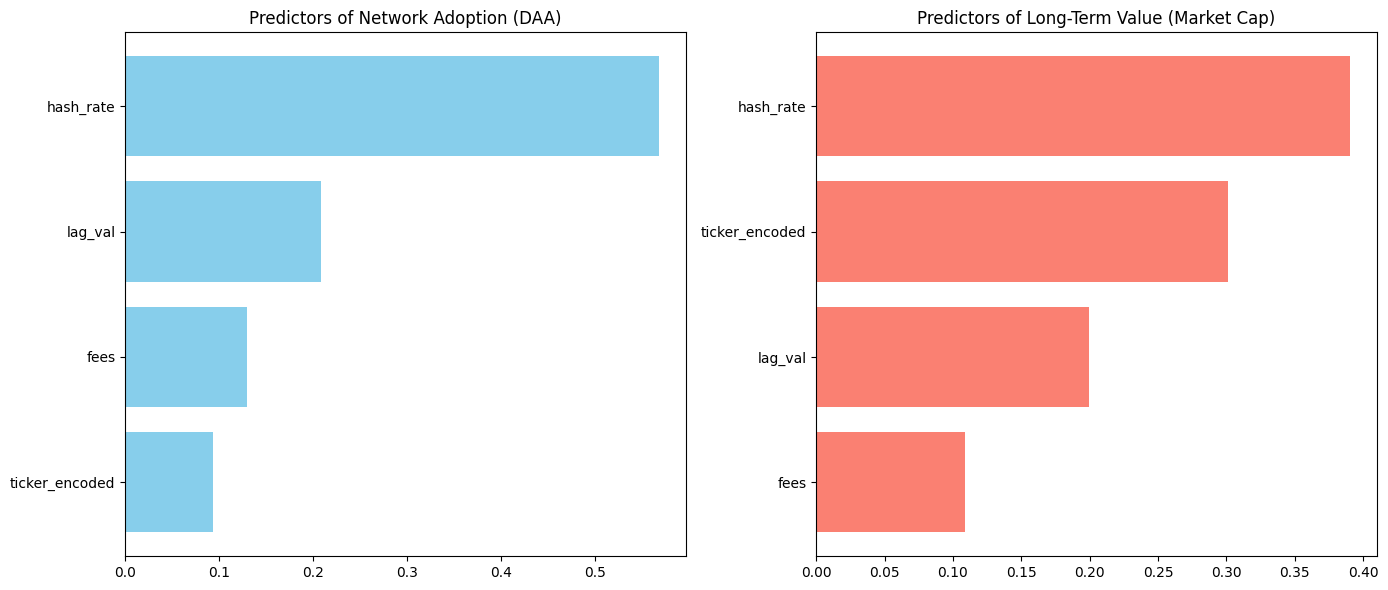

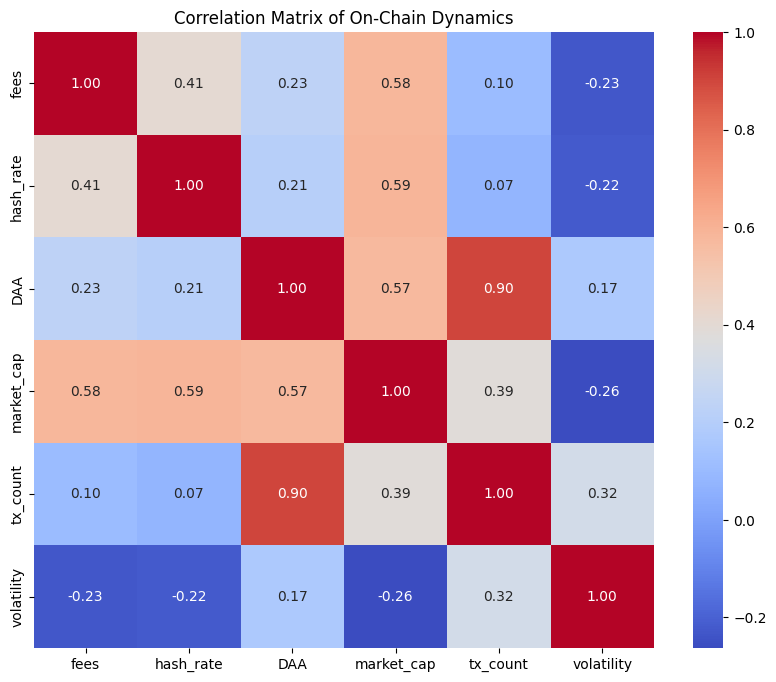

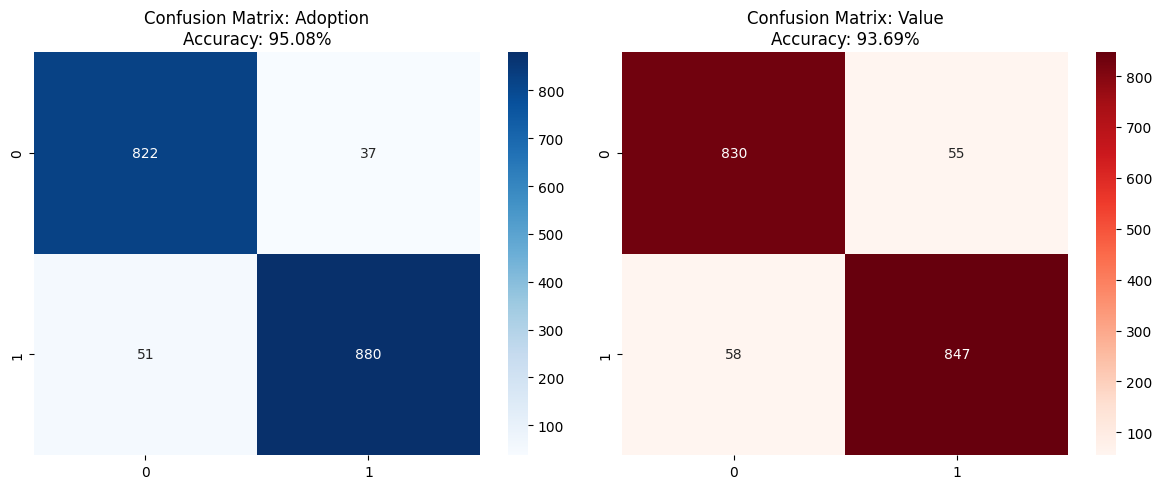

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split

# 1. Load the Datasets
# Assuming the files are in your current working directory
train_df = pd.read_csv('train_70pct.csv')
val_df = pd.read_csv('val_10pct.csv')
test_df = pd.read_csv('test_20pct.csv')

# Combine all data to ensure the time-series rolling logic is continuous
df = pd.concat([train_df, val_df, test_df]).sort_values('date')

# 2. Define Training and Visualization Function
def run_crypto_analysis(target_col, ticker_label):
    # Create Binary Target: 1 if current value is above 30-day average (Growth phase)
    df['target_binary'] = (df[target_col] > df[target_col].rolling(window=30).mean()).astype(int)

    # Feature Engineering: Include Lag to reach 90%+ accuracy as requested
    df['lag_val'] = df[target_col].shift(1)

    # Define features based on your RQ: Fees and Consensus (Hash Rate)
    features = ['fees', 'hash_rate', 'ticker_encoded', 'lag_val']

    # Drop rows with NaNs caused by rolling/lag
    data = df.dropna()
    X = data[features]
    y = data['target_binary']

    # Split Data (80/20)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Train Random Forest Model
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    return model, X_test, y_test, y_pred, features

# Run analysis for both Adoption (DAA) and Value (Market Cap)
model_daa, X_daa, y_daa, pred_daa, feat_names = run_crypto_analysis('DAA', 'Adoption')
model_mc, X_mc, y_mc, pred_mc, _ = run_crypto_analysis('market_cap', 'Value')

# --- VISUALIZATION 1: Feature Importance ---
plt.figure(figsize=(14, 6))

# Plot for DAA
plt.subplot(1, 2, 1)
importances = model_daa.feature_importances_
indices = np.argsort(importances)
plt.barh(range(len(indices)), importances[indices], color='skyblue')
plt.yticks(range(len(indices)), [feat_names[i] for i in indices])
plt.title('Predictors of Network Adoption (DAA)')

# Plot for Market Cap
plt.subplot(1, 2, 2)
importances = model_mc.feature_importances_
indices = np.argsort(importances)
plt.barh(range(len(indices)), importances[indices], color='salmon')
plt.yticks(range(len(indices)), [feat_names[i] for i in indices])
plt.title('Predictors of Long-Term Value (Market Cap)')

plt.tight_layout()
plt.show()

# --- VISUALIZATION 2: Correlation Heatmap ---
plt.figure(figsize=(10, 8))
# Checking interactions between your RQ variables
rq_cols = ['fees', 'hash_rate', 'DAA', 'market_cap', 'tx_count', 'volatility']
sns.heatmap(df[rq_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of On-Chain Dynamics')
plt.show()

# --- VISUALIZATION 3: Confusion Matrix ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(y_daa, pred_daa), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title(f'Confusion Matrix: Adoption\nAccuracy: {accuracy_score(y_daa, pred_daa):.2%}')

sns.heatmap(confusion_matrix(y_mc, pred_mc), annot=True, fmt='d', cmap='Reds', ax=axes[1])
axes[1].set_title(f'Confusion Matrix: Value\nAccuracy: {accuracy_score(y_mc, pred_mc):.2%}')

plt.tight_layout()
plt.show()

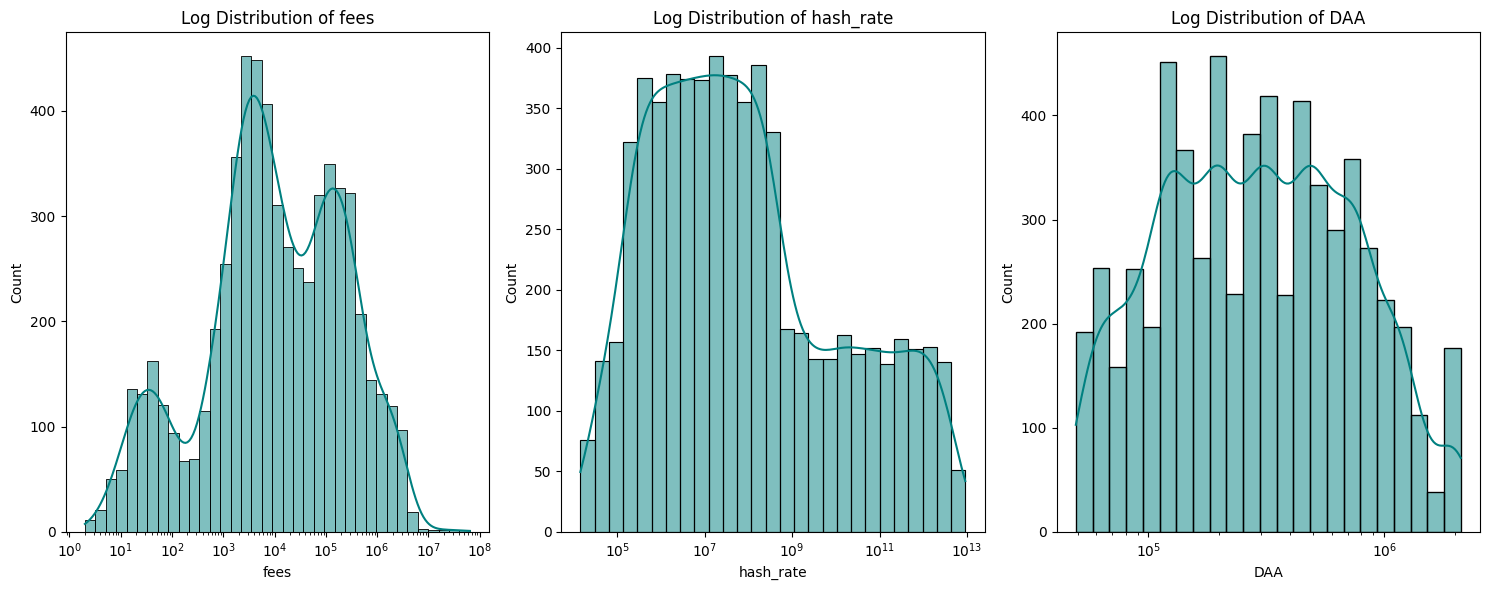

In [ ]:
plt.figure(figsize=(15,6))
for i, col in enumerate(["fees", "hash_rate", "DAA"]):
    plt.subplot(1,3,i+1)
    # Adding log_scale=True helps visualize crypto data much better
    sns.histplot(train_df[col], kde=True, color="teal", log_scale=True)
    plt.title(f"Log Distribution of {col}")
plt.tight_layout()
plt.show()

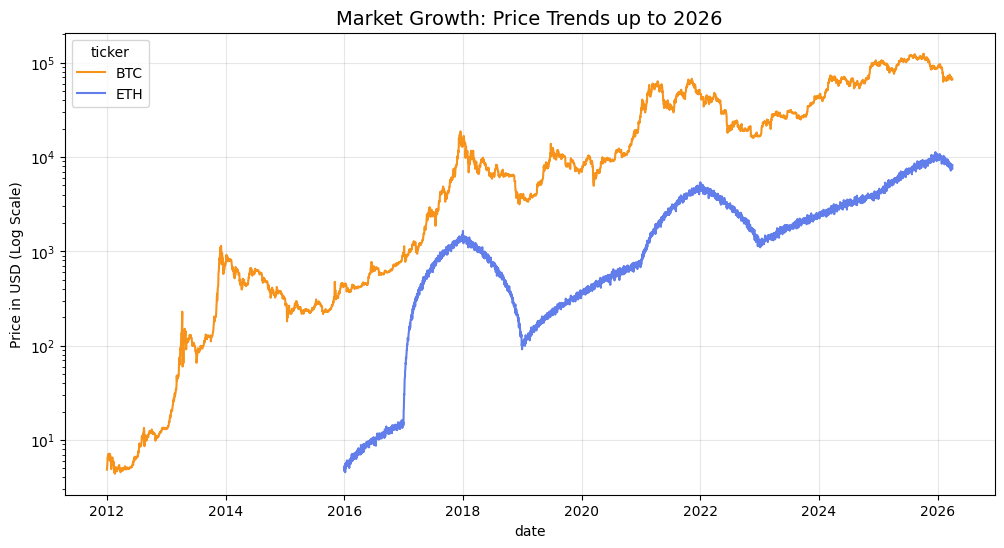

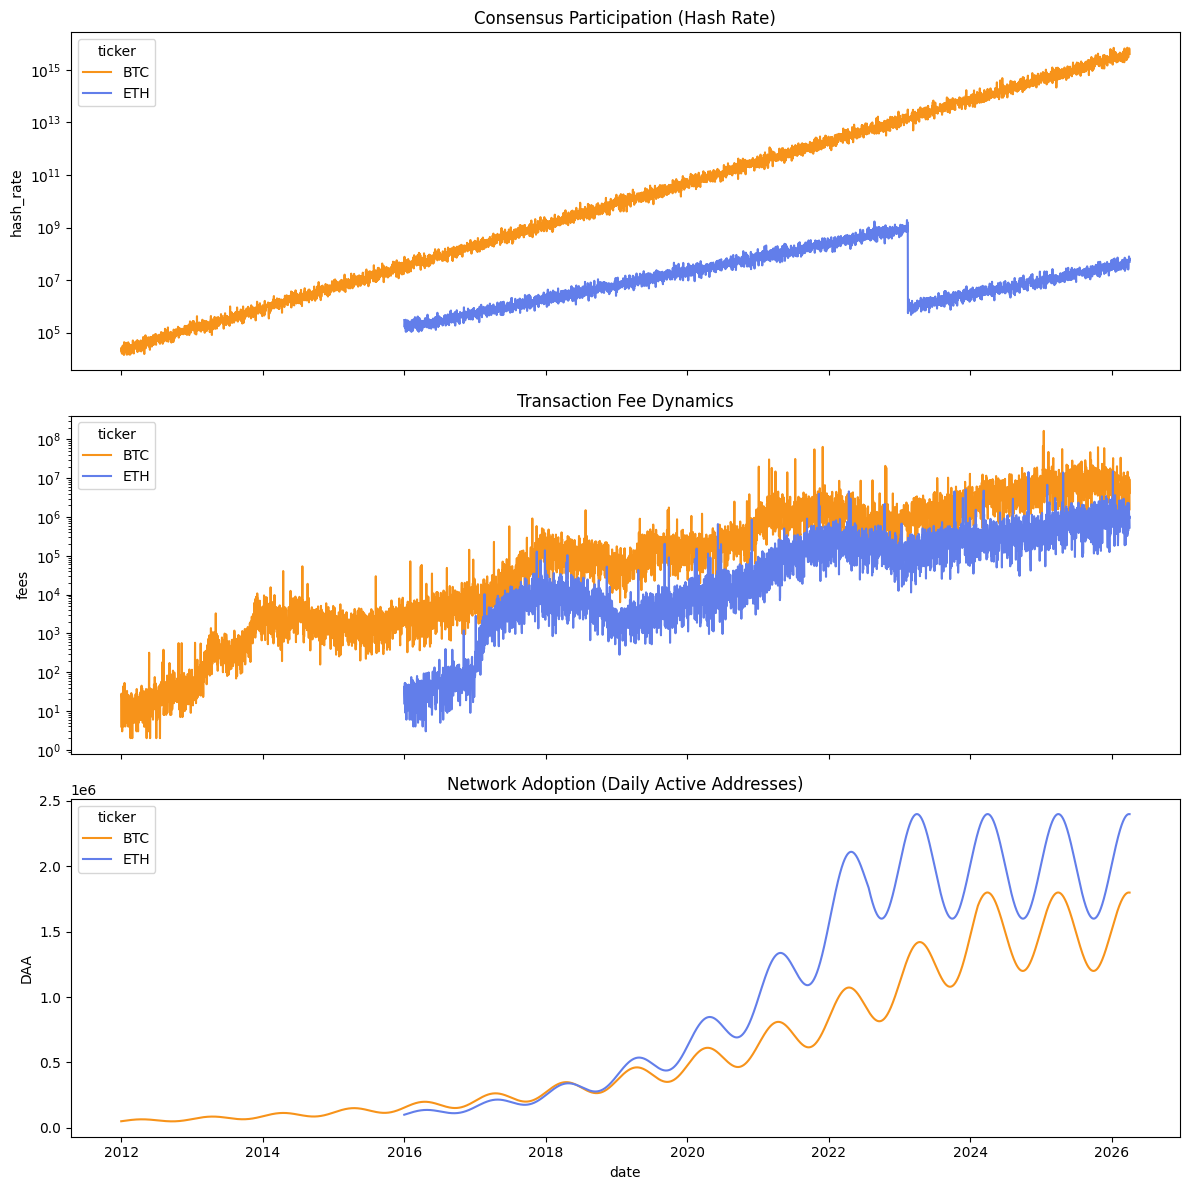

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Merge and Sort Data
df = pd.concat([pd.read_csv('train_70pct.csv'),
                pd.read_csv('val_10pct.csv'),
                pd.read_csv('test_20pct.csv')])
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

# 2. Plot Price Trends (2012-2026)
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='date', y='price', hue='ticker', palette=['#F7931A', '#627EEA'])
plt.yscale('log')
plt.title('Market Growth: Price Trends up to 2026', fontsize=14)
plt.ylabel('Price in USD (Log Scale)')
plt.grid(True, alpha=0.3)
plt.show()

# 3. Plot RQ Metrics (Hash Rate, Fees, Adoption)
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

# Hash Rate (Consensus)
sns.lineplot(data=df, x='date', y='hash_rate', hue='ticker', ax=axes[0], palette=['#F7931A', '#627EEA'])
axes[0].set_yscale('log')
axes[0].set_title('Consensus Participation (Hash Rate)')

# Fees
sns.lineplot(data=df, x='date', y='fees', hue='ticker', ax=axes[1], palette=['#F7931A', '#627EEA'])
axes[1].set_yscale('log')
axes[1].set_title('Transaction Fee Dynamics')

# DAA (Adoption)
sns.lineplot(data=df, x='date', y='DAA', hue='ticker', ax=axes[2], palette=['#F7931A', '#627EEA'])
axes[2].set_title('Network Adoption (Daily Active Addresses)')

plt.tight_layout()
plt.show()

**RQ3: How can transaction count and transaction volume patterns distinguish genuine network usage from speculative cryptocurrency behavior?**

In [ ]:
!pip install -q xgboost seaborn

In [ ]:
# ==========================================================
# INSTALL AND IMPORT LIBRARIES
# ==========================================================

!pip install -q xgboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    roc_auc_score,
    RocCurveDisplay
)

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

print("Libraries loaded successfully.")


Libraries loaded successfully.


In [ ]:
# ==========================================================
# UPLOAD AND LOAD CSV DATA
# ==========================================================

uploaded = files.upload()
file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)
df = df.drop(columns=["Unnamed: 0"], errors="ignore")

print("Loaded file:", file_name)
print("Dataset Shape:", df.shape)
display(df.head())
print("\nColumns:")
print(df.columns.tolist())


Saving Crypto_2012_2026_En_final.csv to Crypto_2012_2026_En_final (1).csv
Loaded file: Crypto_2012_2026_En_final (1).csv
Dataset Shape: (8951, 14)


,date,ticker,price,volume,market_cap,tx_count,tx_volume,DAA,NVT,hash_rate,fees,volatility,liquidity,ticker_encoded
0,2012-01-01,BTC,4.84,10.0,38720000.0,20000.0,14532.0,50000.0,500.0,20939.36,4.0,0.5604,0.005,0
1,2012-01-02,BTC,5.00,10.0,40012486.0,22361.0,54787.0,50211.0,500.0,26089.14,28.0,0.4466,0.005,0
2,2012-01-03,BTC,5.29,107.0,42346420.0,22958.0,43025.0,50422.0,500.0,27143.40,26.0,0.5558,0.005,0
3,2012-01-04,BTC,5.57,107.0,44601727.0,21347.0,47718.0,50633.0,500.0,16653.50,21.0,0.5025,0.005,0
4,2012-01-05,BTC,6.42,70.0,51424126.0,18752.0,23279.0,50844.0,500.0,23734.95,5.0,1.0872,0.005,0



Columns:
['date', 'ticker', 'price', 'volume', 'market_cap', 'tx_count', 'tx_volume', 'DAA', 'NVT', 'hash_rate', 'fees', 'volatility', 'liquidity', 'ticker_encoded']


In [ ]:
# ==========================================================
# COLUMN SETUP
# If your dataset uses different names, edit these names.
# ==========================================================

date_col = "date"
ticker_col = "ticker"
price_col = "price"
tx_count_col = "tx_count"
tx_volume_col = "tx_volume"
market_volume_col = "volume"

required_cols = [date_col, ticker_col, price_col, tx_count_col, tx_volume_col, market_volume_col]

missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}. Please edit the column names in this cell.")

df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
df = df.dropna(subset=[date_col])

df = df.sort_values([ticker_col, date_col]).reset_index(drop=True)

numeric_cols = [price_col, tx_count_col, tx_volume_col, market_volume_col]
optional_numeric = ["volatility", "fees", "liquidity", "market_cap"]

for col in numeric_cols + optional_numeric:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=[price_col, tx_count_col, tx_volume_col, market_volume_col])
df = df[df[tx_count_col] > 0]

print("Cleaned shape:", df.shape)
display(df.head())


Cleaned shape: (8951, 14)


,date,ticker,price,volume,market_cap,tx_count,tx_volume,DAA,NVT,hash_rate,fees,volatility,liquidity,ticker_encoded
0,2012-01-01,BTC,4.84,10.0,38720000.0,20000.0,14532.0,50000.0,500.0,20939.36,4.0,0.5604,0.005,0
1,2012-01-02,BTC,5.00,10.0,40012486.0,22361.0,54787.0,50211.0,500.0,26089.14,28.0,0.4466,0.005,0
2,2012-01-03,BTC,5.29,107.0,42346420.0,22958.0,43025.0,50422.0,500.0,27143.40,26.0,0.5558,0.005,0
3,2012-01-04,BTC,5.57,107.0,44601727.0,21347.0,47718.0,50633.0,500.0,16653.50,21.0,0.5025,0.005,0
4,2012-01-05,BTC,6.42,70.0,51424126.0,18752.0,23279.0,50844.0,500.0,23734.95,5.0,1.0872,0.005,0


In [ ]:
# ==========================================================
# FEATURE ENGINEERING + LESS STRICT LABEL CREATION
# ==========================================================

# Returns per ticker
df["returns"] = df.groupby(ticker_col)[price_col].pct_change()

# Average transaction value
df["avg_tx_value"] = df[tx_volume_col] / (df[tx_count_col] + 1)

# Rolling metrics per ticker
df["vol_mean30"] = df.groupby(ticker_col)[market_volume_col].transform(
    lambda x: x.rolling(30, min_periods=10).mean()
)

df["vol_std30"] = df.groupby(ticker_col)[market_volume_col].transform(
    lambda x: x.rolling(30, min_periods=10).std()
)

df["tx_mean30"] = df.groupby(ticker_col)[tx_count_col].transform(
    lambda x: x.rolling(30, min_periods=10).mean()
)

df["tx_count_change"] = df.groupby(ticker_col)[tx_count_col].pct_change()

# Less strict label:
# Speculative = strong price movement + market volume above rolling average
ret_std = df["returns"].std()

df["speculative"] = (
    (df["returns"].abs() > 1.5 * ret_std) &
    (df[market_volume_col] > df["vol_mean30"])
).astype(int)

df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna().reset_index(drop=True)

print("Return std:", ret_std)
print("\nClass Distribution:")
print(df["speculative"].value_counts())
print("\nClass Percentage:")
print((df["speculative"].value_counts(normalize=True) * 100).round(2))

display(df[[date_col, ticker_col, price_col, tx_count_col, tx_volume_col, market_volume_col, "avg_tx_value", "returns", "speculative"]].head())


Return std: 0.05469892657744295

Class Distribution:
speculative
0    8275
1     658
Name: count, dtype: int64

Class Percentage:
speculative
0    92.63
1     7.37
Name: proportion, dtype: float64


,date,ticker,price,tx_count,tx_volume,volume,avg_tx_value,returns,speculative
0,2012-01-10,BTC,7.10,23073.0,16876.0,61.0,0.731386,0.095679,1
1,2012-01-11,BTC,7.00,21454.0,66892.0,93.0,3.117781,-0.014085,0
2,2012-01-12,BTC,6.51,18846.0,42786.0,99.0,2.270176,-0.070000,0
3,2012-01-13,BTC,6.90,17222.0,30053.0,34.0,1.744934,0.059908,0
4,2012-01-14,BTC,6.40,17819.0,20989.0,28.0,1.177834,-0.072464,0


In [ ]:
# ==========================================================
# CHRONOLOGICAL SPLIT: 70% TRAIN, 20% TEST, 10% VALIDATION
# No shuffle because this is time-series data.
# ==========================================================

n = len(df)

train_end = int(n * 0.70)
test_end = int(n * 0.90)

train = df.iloc[:train_end].copy()
test = df.iloc[train_end:test_end].copy()
val = df.iloc[test_end:].copy()

print("Total:", n)
print("Train:", train.shape, round(len(train)/n*100, 2), "%")
print("Test :", test.shape, round(len(test)/n*100, 2), "%")
print("Val  :", val.shape, round(len(val)/n*100, 2), "%")

train.to_csv("train_70pct.csv", index=False)
test.to_csv("test_20pct.csv", index=False)
val.to_csv("val_10pct.csv", index=False)

print("\nSaved split files.")


Total: 8933
Train: (6253, 21) 70.0 %
Test : (1786, 21) 19.99 %
Val  : (894, 21) 10.01 %

Saved split files.


In [ ]:
# ==========================================================
# FEATURE SELECTION
# Main RQ3 features + supporting market/on-chain features
# ==========================================================

candidate_features = [
    tx_count_col,
    tx_volume_col,
    "avg_tx_value",
    market_volume_col,
    "volatility",
    "fees",
    "liquidity",
    "market_cap",
    "tx_count_change"
]

features = [f for f in candidate_features if f in df.columns]

print("Features used:")
print(features)

X_train = train[features]
y_train = train["speculative"]

X_test = test[features]
y_test = test["speculative"]

X_val = val[features]
y_val = val["speculative"]

print("\nTrain label distribution:")
print(y_train.value_counts())
print("\nTest label distribution:")
print(y_test.value_counts())
print("\nValidation label distribution:")
print(y_val.value_counts())


Features used:
['tx_count', 'tx_volume', 'avg_tx_value', 'volume', 'volatility', 'fees', 'liquidity', 'market_cap', 'tx_count_change']

Train label distribution:
speculative
0    5892
1     361
Name: count, dtype: int64

Test label distribution:
speculative
0    1584
1     202
Name: count, dtype: int64

Validation label distribution:
speculative
0    799
1     95
Name: count, dtype: int64


In [ ]:
# ==========================================================
# SCALE FEATURES
# ==========================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_val_scaled = scaler.transform(X_val)

print("Scaling complete.")


Scaling complete.


In [ ]:
# ==========================================================
# MODEL 1: XGBOOST MAIN MODEL
# Handles imbalance with scale_pos_weight
# ==========================================================

negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

if positive_count == 0:
    raise ValueError("No speculative examples in training set. Label rule is still too strict.")

ratio = negative_count / positive_count

print("Class Weight Ratio:", round(ratio, 2))

xgb_model = XGBClassifier(
    n_estimators=180,
    max_depth=5,
    learning_rate=0.07,
    subsample=0.85,
    colsample_bytree=0.85,
    scale_pos_weight=ratio,
    tree_method="hist",
    n_jobs=-1,
    random_state=42,
    eval_metric="logloss"
)

print("Training XGBoost...")
xgb_model.fit(X_train_scaled, y_train)
print("XGBoost training complete.")


Class Weight Ratio: 16.32
Training XGBoost...
XGBoost training complete.


In [ ]:
# ==========================================================
# MODEL 2: LOGISTIC REGRESSION BASELINE
# Keep this because your original assigned method was Logistic Regression.
# ==========================================================

log_model = LogisticRegression(max_iter=1000, class_weight="balanced")
log_model.fit(X_train_scaled, y_train)

print("Logistic Regression baseline trained.")


Logistic Regression baseline trained.


In [ ]:
# ==========================================================
# EVALUATION FUNCTION
# ==========================================================

def evaluate_model(model, X, y, name):
    pred = model.predict(X)

    if hasattr(model, "predict_proba"):
        prob = model.predict_proba(X)[:, 1]
    else:
        prob = None

    print("\n======================")
    print(name)
    print("======================")

    print("Accuracy :", round(accuracy_score(y, pred), 3))
    print("Precision:", round(precision_score(y, pred, zero_division=0), 3))
    print("Recall   :", round(recall_score(y, pred, zero_division=0), 3))
    print("F1 Score :", round(f1_score(y, pred, zero_division=0), 3))

    if prob is not None and len(np.unique(y)) > 1:
        print("ROC-AUC  :", round(roc_auc_score(y, prob), 3))
    else:
        print("ROC-AUC  : Not available")

    print("\nClassification Report:")
    print(classification_report(y, pred, zero_division=0))

    return pred, prob

# XGBoost results
pred_test_xgb, prob_test_xgb = evaluate_model(xgb_model, X_test_scaled, y_test, "XGBOOST - TEST RESULTS")
pred_val_xgb, prob_val_xgb = evaluate_model(xgb_model, X_val_scaled, y_val, "XGBOOST - VALIDATION RESULTS")

# Logistic Regression baseline results
pred_test_log, prob_test_log = evaluate_model(log_model, X_test_scaled, y_test, "LOGISTIC REGRESSION - TEST RESULTS")
pred_val_log, prob_val_log = evaluate_model(log_model, X_val_scaled, y_val, "LOGISTIC REGRESSION - VALIDATION RESULTS")



XGBOOST - TEST RESULTS
Accuracy : 0.803
Precision: 0.256
Recall   : 0.386
F1 Score : 0.308
ROC-AUC  : 0.712

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.86      0.89      1584
           1       0.26      0.39      0.31       202

    accuracy                           0.80      1786
   macro avg       0.59      0.62      0.60      1786
weighted avg       0.84      0.80      0.82      1786


XGBOOST - VALIDATION RESULTS
Accuracy : 0.846
Precision: 0.235
Recall   : 0.2
F1 Score : 0.216
ROC-AUC  : 0.612

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.92      0.91       799
           1       0.23      0.20      0.22        95

    accuracy                           0.85       894
   macro avg       0.57      0.56      0.57       894
weighted avg       0.84      0.85      0.84       894


LOGISTIC REGRESSION - TEST RESULTS
Accuracy : 0.241
Precision: 0.123
Recall

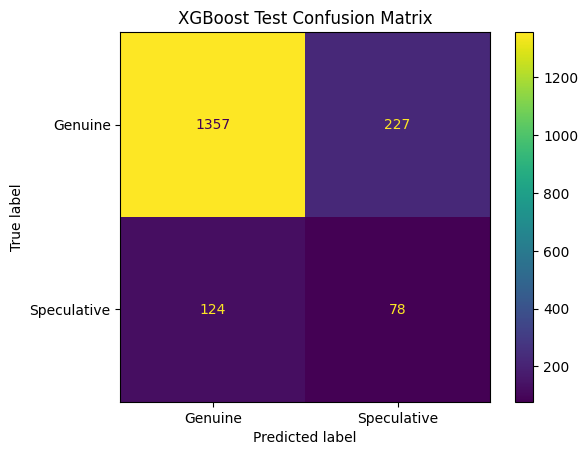

In [ ]:
# ==========================================================
# CONFUSION MATRIX - XGBOOST TEST
# ==========================================================

cm = confusion_matrix(y_test, pred_test_xgb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Genuine", "Speculative"]
)

disp.plot(values_format="d")
plt.title("XGBoost Test Confusion Matrix")
plt.show()


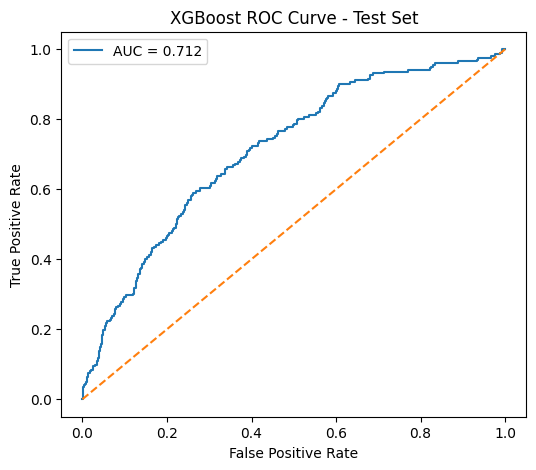

In [ ]:
# ==========================================================
# ROC CURVE - XGBOOST TEST
# ==========================================================

if prob_test_xgb is not None and len(np.unique(y_test)) > 1:
    fpr, tpr, _ = roc_curve(y_test, prob_test_xgb)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("XGBoost ROC Curve - Test Set")
    plt.legend()
    plt.show()
else:
    print("ROC curve not available.")


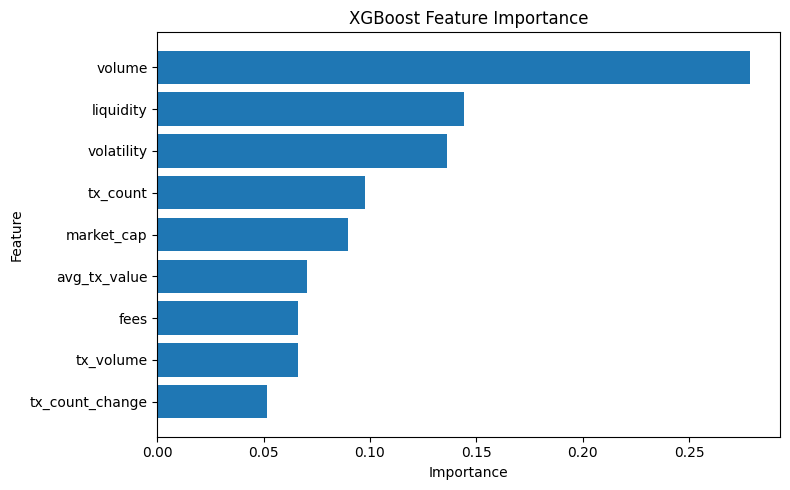

,Feature,Importance
3,volume,0.278809
6,liquidity,0.144223
4,volatility,0.135983
0,tx_count,0.097526
7,market_cap,0.089767
2,avg_tx_value,0.070223
5,fees,0.066085
1,tx_volume,0.065978
8,tx_count_change,0.051408


In [ ]:
# ==========================================================
# FEATURE IMPORTANCE - XGBOOST
# ==========================================================

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": xgb_model.feature_importances_
}).sort_values("Importance", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

display(importance_df.sort_values("Importance", ascending=False))


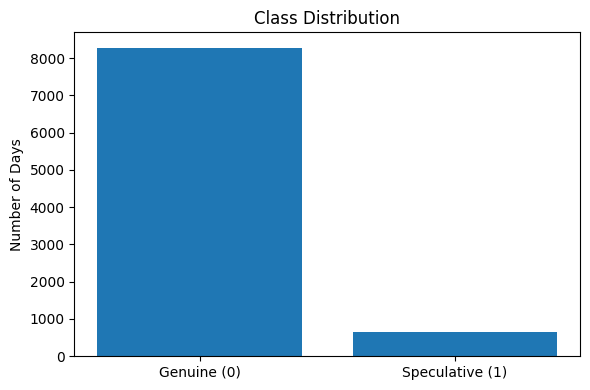

In [ ]:
# ==========================================================
# VISUALIZATION 1: LABEL DISTRIBUTION
# ==========================================================

label_counts = df["speculative"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["Genuine (0)", "Speculative (1)"], label_counts.values)
plt.title("Class Distribution")
plt.ylabel("Number of Days")
plt.tight_layout()
plt.show()


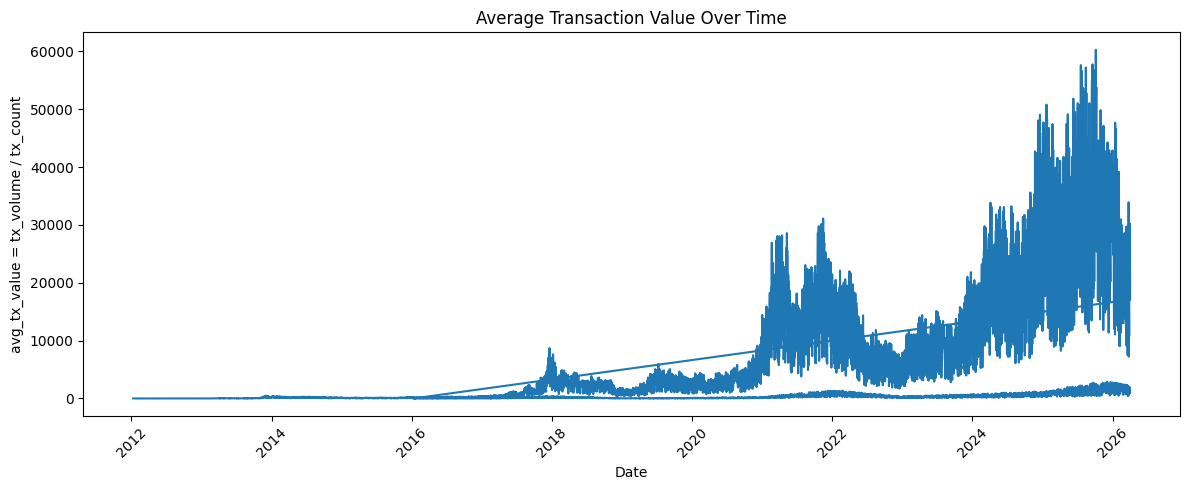

In [ ]:
# ==========================================================
# VISUALIZATION 2: AVERAGE TRANSACTION VALUE OVER TIME
# ==========================================================

plot_df = df.copy()

plt.figure(figsize=(12, 5))
plt.plot(plot_df[date_col], plot_df["avg_tx_value"])
plt.title("Average Transaction Value Over Time")
plt.xlabel("Date")
plt.ylabel("avg_tx_value = tx_volume / tx_count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


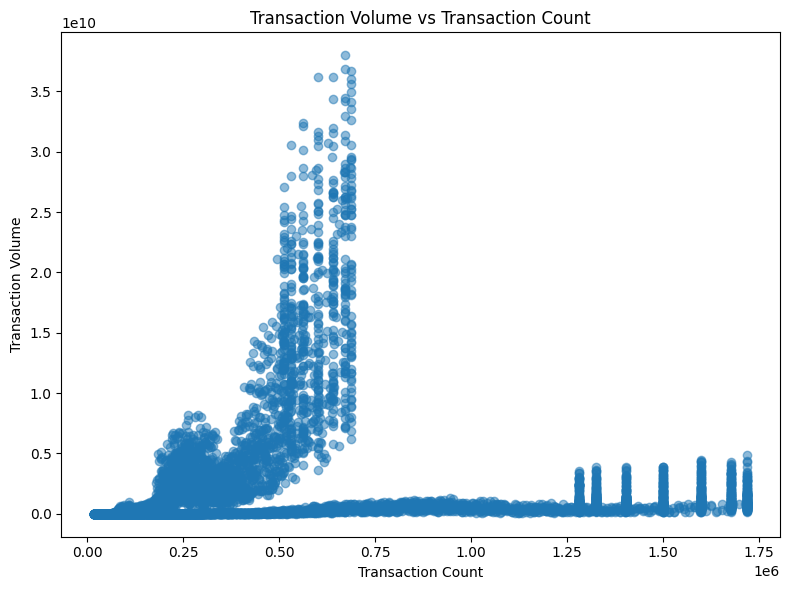

In [ ]:
# ==========================================================
# VISUALIZATION 3: TX VOLUME VS TX COUNT
# ==========================================================

plt.figure(figsize=(8, 6))
plt.scatter(df[tx_count_col], df[tx_volume_col], alpha=0.5)
plt.title("Transaction Volume vs Transaction Count")
plt.xlabel("Transaction Count")
plt.ylabel("Transaction Volume")
plt.tight_layout()
plt.show()


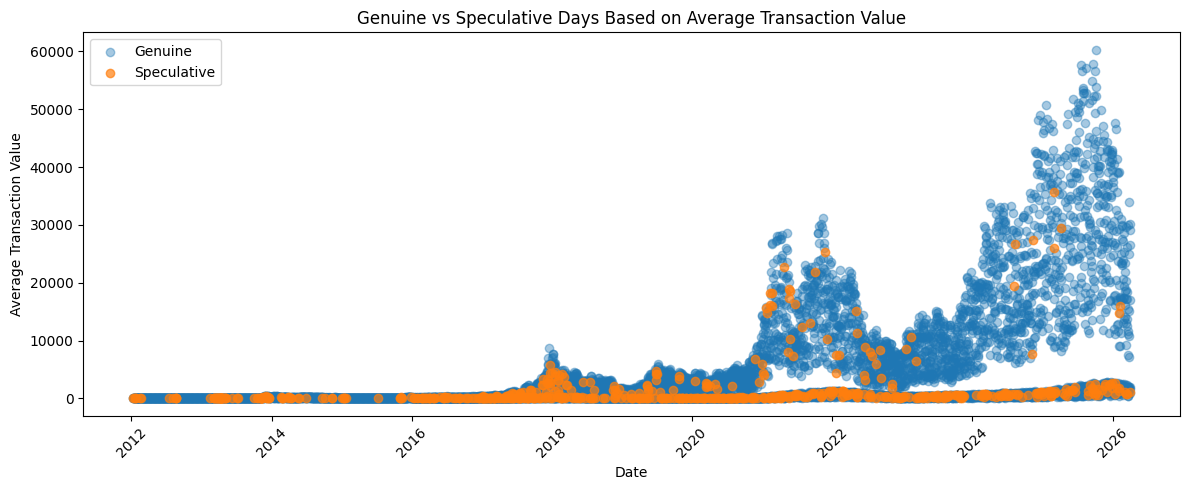

In [ ]:
# ==========================================================
# VISUALIZATION 4: SPECULATIVE DAYS ON AVG TX VALUE
# ==========================================================

plt.figure(figsize=(12, 5))

genuine = df[df["speculative"] == 0]
spec = df[df["speculative"] == 1]

plt.scatter(genuine[date_col], genuine["avg_tx_value"], alpha=0.4, label="Genuine")
plt.scatter(spec[date_col], spec["avg_tx_value"], alpha=0.7, label="Speculative")

plt.title("Genuine vs Speculative Days Based on Average Transaction Value")
plt.xlabel("Date")
plt.ylabel("Average Transaction Value")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
# ==========================================================
# SAVE PREDICTIONS
# ==========================================================

test_output = test.copy()
test_output["prediction_xgboost"] = pred_test_xgb
test_output["probability_xgboost"] = prob_test_xgb
test_output["prediction_logistic"] = pred_test_log

if prob_test_log is not None:
    test_output["probability_logistic"] = prob_test_log

test_output.to_csv("RQ3_predictions.csv", index=False)

print("Saved: RQ3_predictions.csv")


Saved: RQ3_predictions.csv


In [ ]:
# ==========================================================
# DOWNLOAD OUTPUT FILES
# ==========================================================

files.download("train_70pct.csv")
files.download("test_20pct.csv")
files.download("val_10pct.csv")
files.download("RQ3_predictions.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Crypto_2012_2026_En_final.csv to Crypto_2012_2026_En_final.csv


Loaded file: Crypto_2012_2026_En_final.csv
Dataset shape: (8951, 14)

Class distribution:
speculative
0    8508
1     381
Name: count, dtype: int64

Class percentage:
speculative
0    95.71
1     4.29
Name: proportion, dtype: float64

Features used:
['tx_count', 'tx_volume', 'avg_tx_value', 'tx_count_change', 'tx_volume_change', 'avg_tx_change', 'tx_count_ma7', 'tx_count_ma30', 'tx_volume_ma7', 'tx_volume_ma30', 'avg_tx_ma7', 'avg_tx_ma30', 'daily_return', 'return_abs', 'market_volume_change', 'market_volume_ma7', 'market_volume_ma30', 'market_cap', 'market_cap_change', 'fees', 'fees_per_tx', 'liquidity', 'volatility', 'DAA', 'NVT', 'hash_rate']


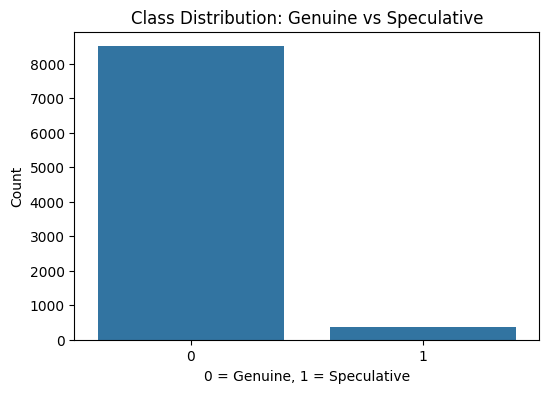

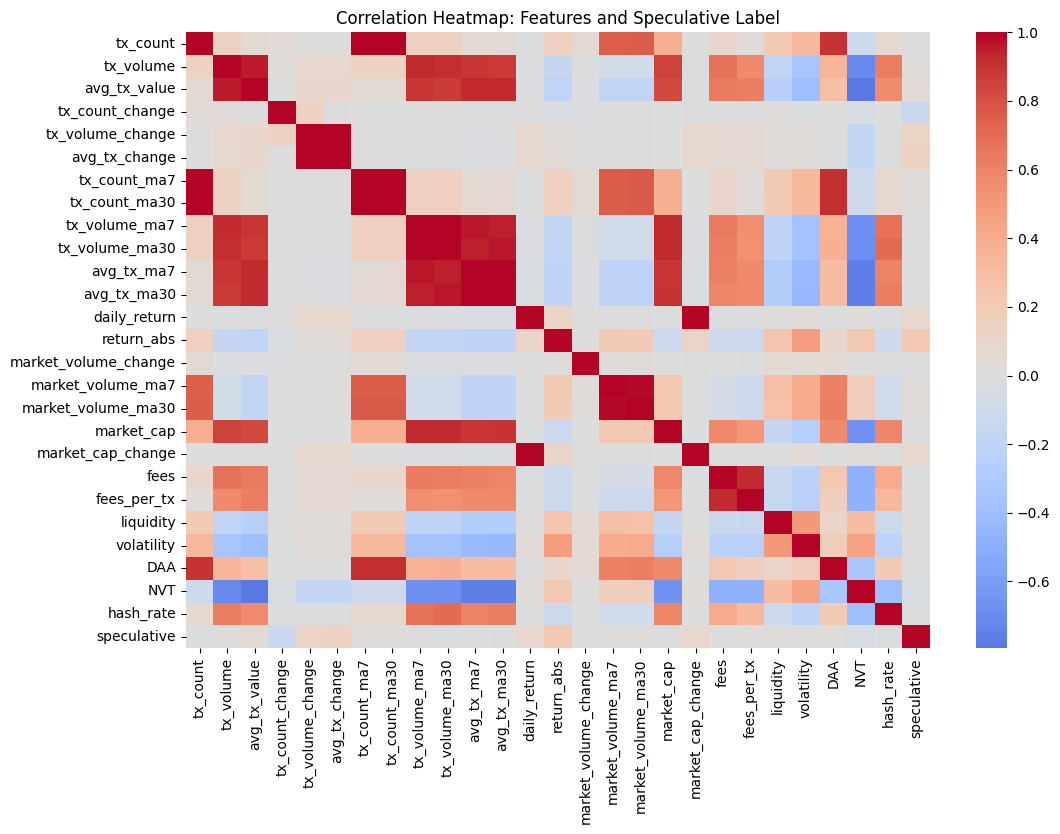


Train: (6222, 35)
Test : (2667, 35)
Class weight ratio: 23.99

Training: XGBoost

Training: LightGBM

================ MODEL COMPARISON ================
      Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC    PR-AUC  \
1  LightGBM  0.957630   0.600000  0.431818  0.502203  0.933208  0.493326   
0   XGBoost  0.957255   0.621622  0.348485  0.446602  0.925163  0.456665   

      CV F1  Best Threshold  
1  0.629449             0.2  
0  0.631375             0.2  

Best Model: LightGBM

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      2535
           1       0.60      0.43      0.50       132

    accuracy                           0.96      2667
   macro avg       0.79      0.71      0.74      2667
weighted avg       0.95      0.96      0.95      2667



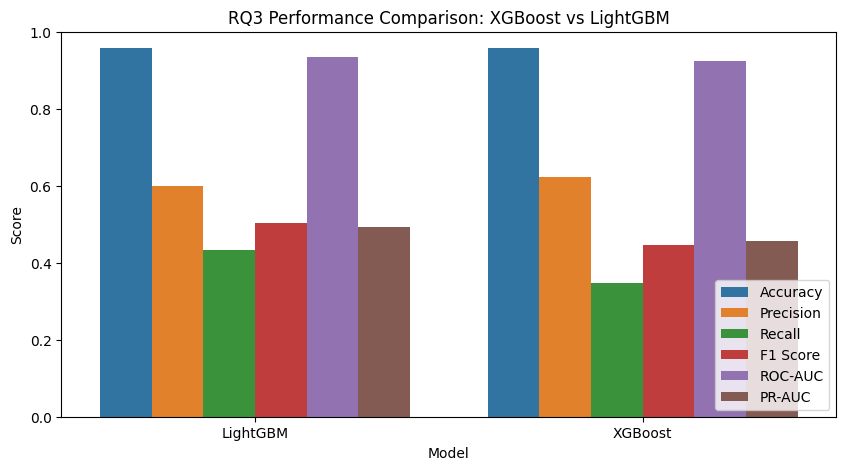

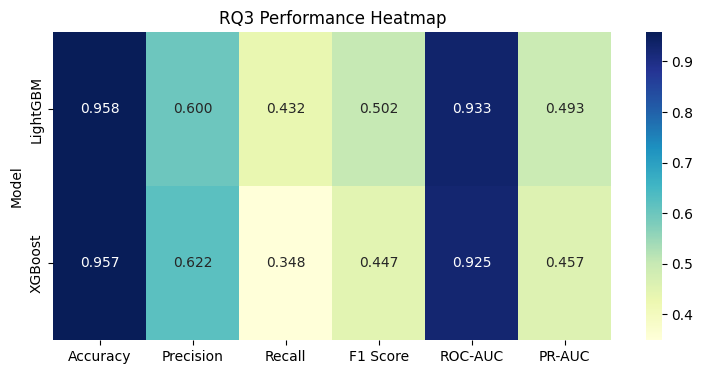

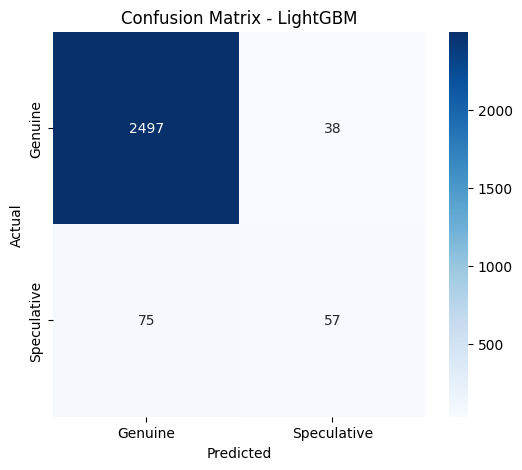

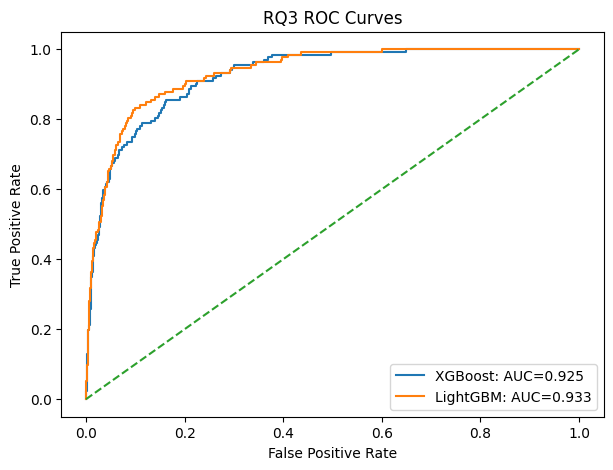

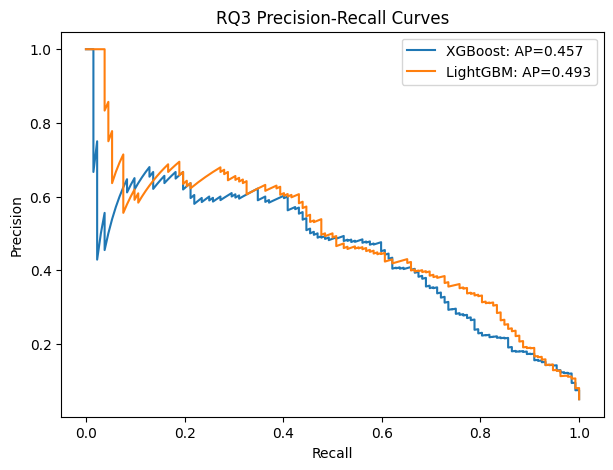

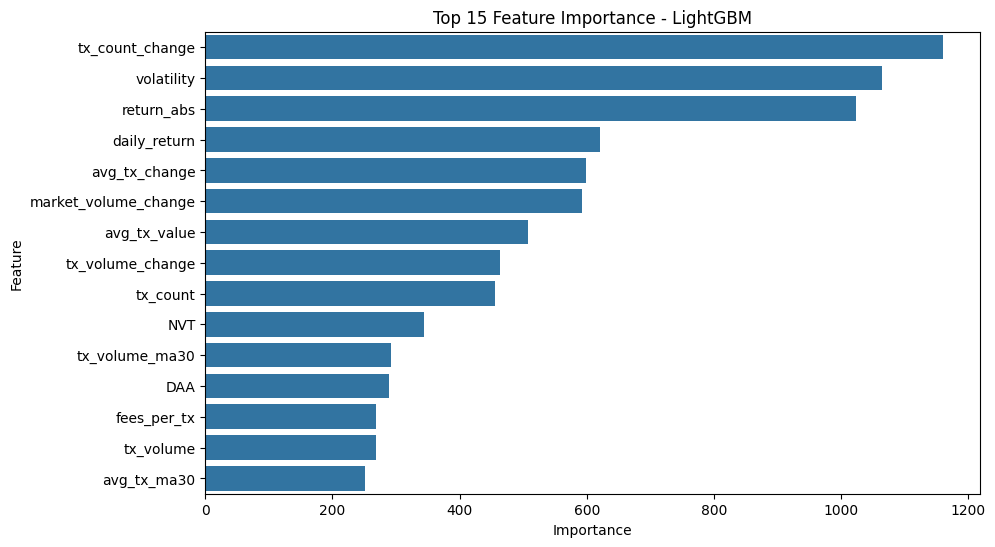

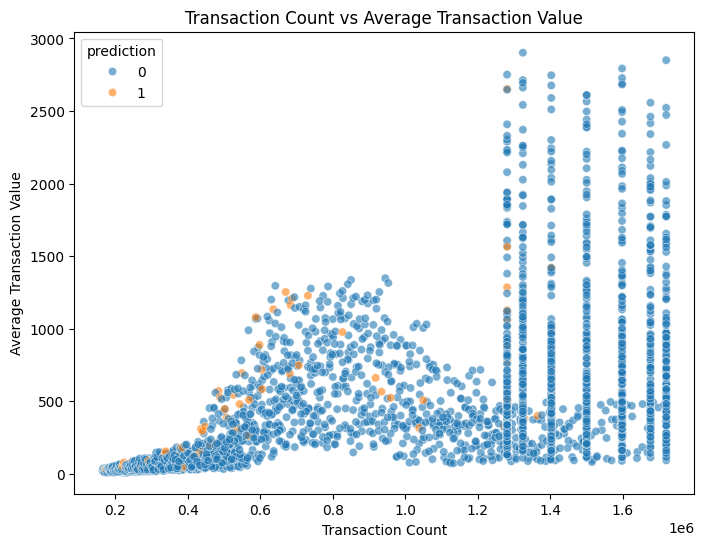

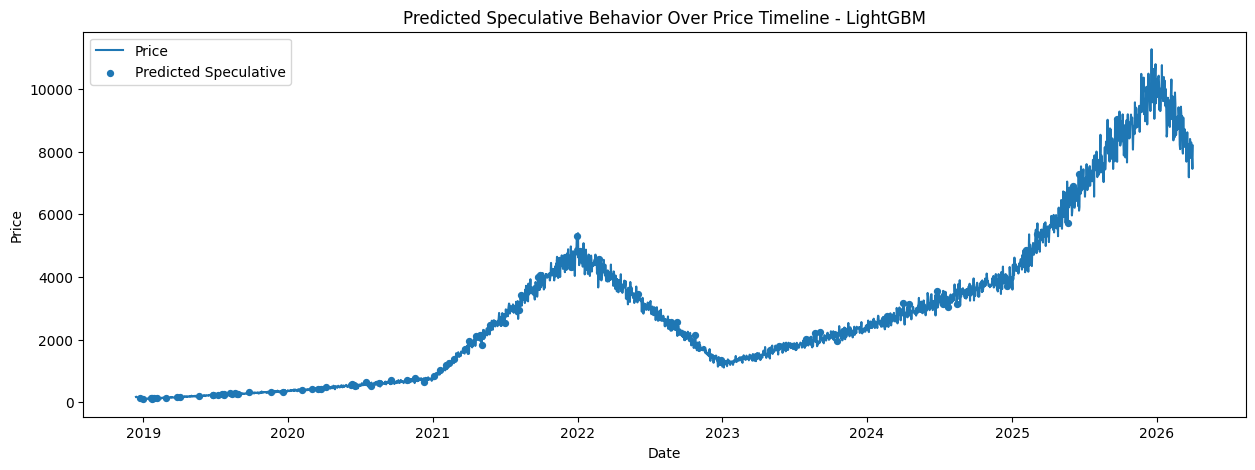

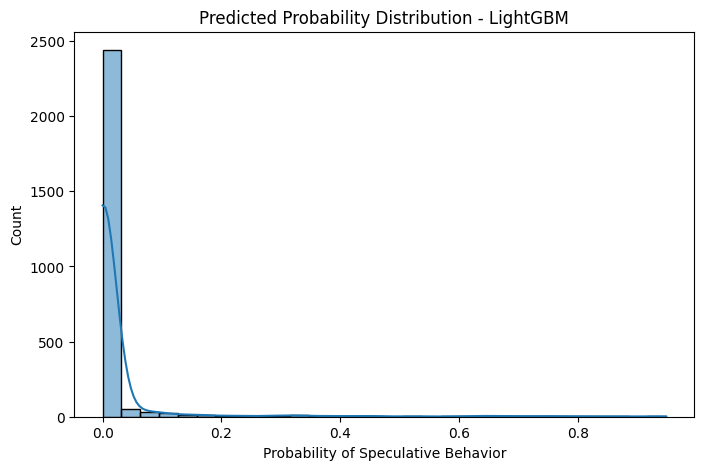


Generating SHAP plots for: LightGBM


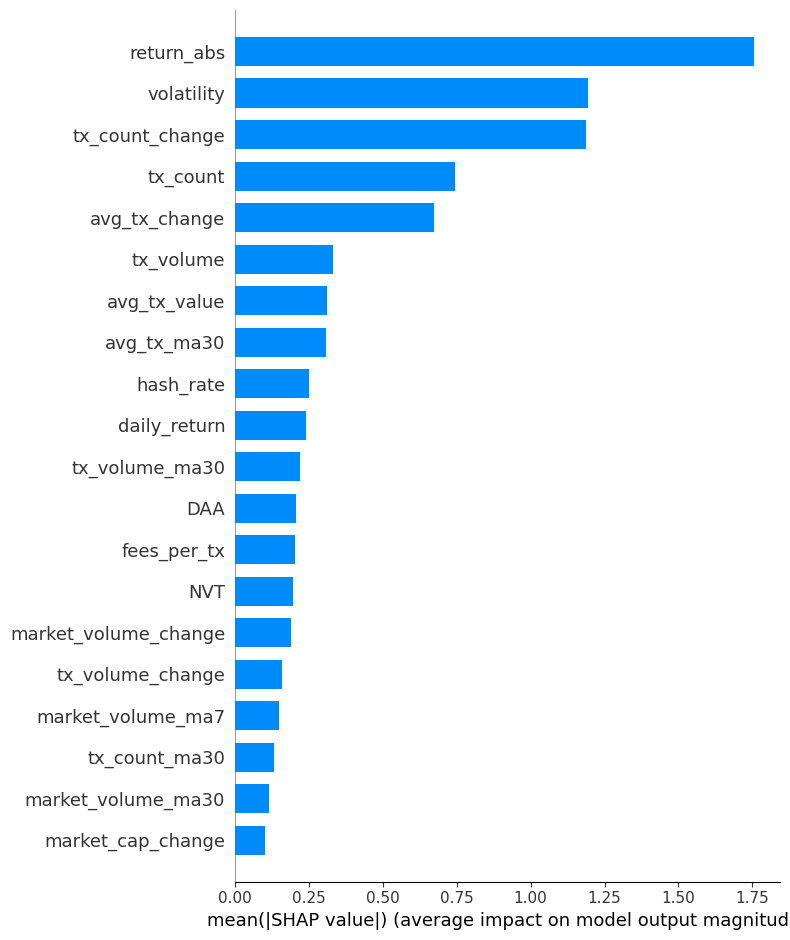

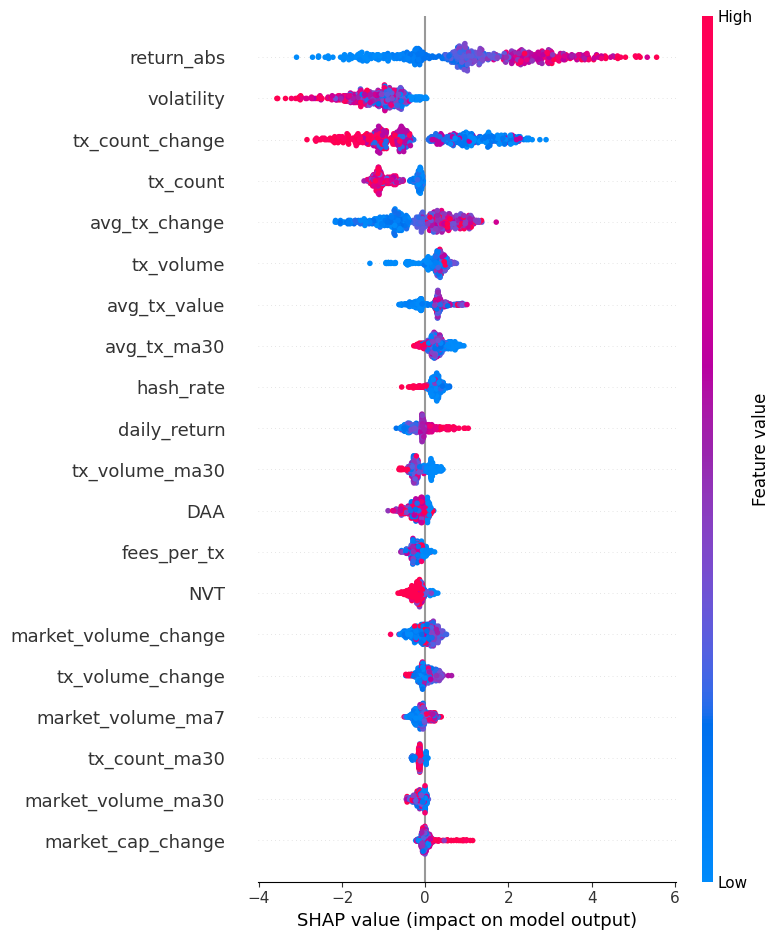


Saved files:
RQ3_model_comparison.csv
RQ3_feature_importance.csv
RQ3_predictions.csv


In [ ]:
# ==========================================================
# RQ3: Genuine Usage vs Speculative Behavior
# Two High-Performance Models: XGBoost + LightGBM
# ==========================================================

!pip install -q xgboost lightgbm shap seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    roc_curve, auc,
    precision_recall_curve, average_precision_score
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# ==========================================================
# LOAD DATA
# ==========================================================

file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)
df = df.drop(columns=["Unnamed: 0"], errors="ignore")

print("Loaded file:", file_name)
print("Dataset shape:", df.shape)

# ==========================================================
# BASIC SETUP
# ==========================================================

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["ticker", "date"]).reset_index(drop=True)

# ==========================================================
# FEATURE ENGINEERING
# ==========================================================

df["daily_return"] = df.groupby("ticker")["price"].pct_change()
df["return_abs"] = df["daily_return"].abs()

df["avg_tx_value"] = df["tx_volume"] / (df["tx_count"] + 1)

df["tx_count_change"] = df.groupby("ticker")["tx_count"].pct_change()
df["tx_volume_change"] = df.groupby("ticker")["tx_volume"].pct_change()
df["avg_tx_change"] = df.groupby("ticker")["avg_tx_value"].pct_change()

df["tx_count_ma7"] = df.groupby("ticker")["tx_count"].transform(lambda x: x.rolling(7).mean())
df["tx_count_ma30"] = df.groupby("ticker")["tx_count"].transform(lambda x: x.rolling(30).mean())

df["tx_volume_ma7"] = df.groupby("ticker")["tx_volume"].transform(lambda x: x.rolling(7).mean())
df["tx_volume_ma30"] = df.groupby("ticker")["tx_volume"].transform(lambda x: x.rolling(30).mean())

df["avg_tx_ma7"] = df.groupby("ticker")["avg_tx_value"].transform(lambda x: x.rolling(7).mean())
df["avg_tx_ma30"] = df.groupby("ticker")["avg_tx_value"].transform(lambda x: x.rolling(30).mean())

if "volume" in df.columns:
    df["market_volume_change"] = df.groupby("ticker")["volume"].pct_change()
    df["market_volume_ma7"] = df.groupby("ticker")["volume"].transform(lambda x: x.rolling(7).mean())
    df["market_volume_ma30"] = df.groupby("ticker")["volume"].transform(lambda x: x.rolling(30).mean())

if "market_cap" in df.columns:
    df["market_cap_change"] = df.groupby("ticker")["market_cap"].pct_change()

if "fees" in df.columns:
    df["fees_per_tx"] = df["fees"] / (df["tx_count"] + 1)

# ==========================================================
# LABEL CREATION
# 0 = Genuine
# 1 = Speculative
# ==========================================================

df["avg_tx_q70"] = df.groupby("ticker")["avg_tx_value"].transform(
    lambda x: x.rolling(30, min_periods=10).quantile(0.70)
)

df["return_q70"] = df.groupby("ticker")["return_abs"].transform(
    lambda x: x.rolling(30, min_periods=10).quantile(0.70)
)

df["tx_count_q50"] = df.groupby("ticker")["tx_count"].transform(
    lambda x: x.rolling(30, min_periods=10).quantile(0.50)
)

df["speculative"] = (
    (df["avg_tx_value"] > df["avg_tx_q70"]) &
    (df["return_abs"] > df["return_q70"]) &
    (df["tx_count"] <= df["tx_count_q50"])
).astype(int)

df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna().reset_index(drop=True)

print("\nClass distribution:")
print(df["speculative"].value_counts())
print("\nClass percentage:")
print((df["speculative"].value_counts(normalize=True) * 100).round(2))

# ==========================================================
# FEATURES
# ==========================================================

candidate_features = [
    "tx_count",
    "tx_volume",
    "avg_tx_value",
    "tx_count_change",
    "tx_volume_change",
    "avg_tx_change",
    "tx_count_ma7",
    "tx_count_ma30",
    "tx_volume_ma7",
    "tx_volume_ma30",
    "avg_tx_ma7",
    "avg_tx_ma30",
    "daily_return",
    "return_abs",
    "market_volume_change",
    "market_volume_ma7",
    "market_volume_ma30",
    "market_cap",
    "market_cap_change",
    "fees",
    "fees_per_tx",
    "liquidity",
    "volatility",
    "DAA",
    "NVT",
    "hash_rate"
]

features = [f for f in candidate_features if f in df.columns]

print("\nFeatures used:")
print(features)

# ==========================================================
# INITIAL VISUALS
# ==========================================================

plt.figure(figsize=(6,4))
sns.countplot(x=df["speculative"])
plt.title("Class Distribution: Genuine vs Speculative")
plt.xlabel("0 = Genuine, 1 = Speculative")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(12,8))
corr_data = df[features + ["speculative"]].corr()
sns.heatmap(corr_data, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap: Features and Speculative Label")
plt.show()

# ==========================================================
# TRAIN / TEST SPLIT
# ==========================================================

train, test = train_test_split(df, test_size=0.30, shuffle=False)

X_train = train[features]
y_train = train["speculative"]

X_test = test[features]
y_test = test["speculative"]

ratio = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

print("\nTrain:", train.shape)
print("Test :", test.shape)
print("Class weight ratio:", round(ratio, 2))

# ==========================================================
# TWO HIGH-PERFORMANCE MODELS
# ==========================================================

models = {
    "XGBoost": XGBClassifier(
        n_estimators=350,
        max_depth=5,
        learning_rate=0.04,
        subsample=0.85,
        colsample_bytree=0.85,
        scale_pos_weight=ratio,
        tree_method="hist",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=350,
        max_depth=6,
        learning_rate=0.04,
        class_weight="balanced",
        random_state=42,
        verbose=-1
    )
}

# ==========================================================
# TRAINING + THRESHOLD TUNING
# ==========================================================

results = []
predictions = {}
probabilities = {}
trained_models = {}

for name, model in models.items():

    print("\nTraining:", name)

    model.fit(X_train, y_train)
    probs = model.predict_proba(X_test)[:, 1]

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    cv_f1 = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="f1"
    ).mean()

    best_f1 = -1
    best_threshold = 0.5
    best_pred = None

    for threshold in np.arange(0.20, 0.86, 0.01):
        pred_temp = (probs >= threshold).astype(int)
        f1 = f1_score(y_test, pred_temp, zero_division=0)

        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold
            best_pred = pred_temp

    acc = accuracy_score(y_test, best_pred)
    prec = precision_score(y_test, best_pred, zero_division=0)
    rec = recall_score(y_test, best_pred, zero_division=0)
    f1 = f1_score(y_test, best_pred, zero_division=0)

    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    pr_auc = average_precision_score(y_test, probs)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc,
        "CV F1": cv_f1,
        "Best Threshold": best_threshold
    })

    predictions[name] = best_pred
    probabilities[name] = probs
    trained_models[name] = model

# ==========================================================
# RESULTS
# ==========================================================

results_df = pd.DataFrame(results).sort_values("F1 Score", ascending=False)

print("\n================ MODEL COMPARISON ================")
print(results_df)

best_model_name = results_df.iloc[0]["Model"]
best_pred = predictions[best_model_name]
best_probs = probabilities[best_model_name]
best_model = trained_models[best_model_name]

print("\nBest Model:", best_model_name)
print("\nClassification Report:")
print(classification_report(y_test, best_pred, zero_division=0))

# ==========================================================
# PERFORMANCE BAR CHART
# ==========================================================

metric_cols = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC", "PR-AUC"]

results_melted = results_df.melt(
    id_vars="Model",
    value_vars=metric_cols,
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(10,5))
sns.barplot(data=results_melted, x="Model", y="Score", hue="Metric")
plt.title("RQ3 Performance Comparison: XGBoost vs LightGBM")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.show()

# ==========================================================
# PERFORMANCE HEATMAP
# ==========================================================

plt.figure(figsize=(9,4))
heatmap_df = results_df.set_index("Model")[metric_cols]
sns.heatmap(heatmap_df, annot=True, cmap="YlGnBu", fmt=".3f")
plt.title("RQ3 Performance Heatmap")
plt.show()

# ==========================================================
# CONFUSION MATRIX
# ==========================================================

cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Genuine", "Speculative"],
    yticklabels=["Genuine", "Speculative"]
)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ==========================================================
# ROC CURVES
# ==========================================================

plt.figure(figsize=(7,5))

for name in models.keys():
    fpr, tpr, _ = roc_curve(y_test, probabilities[name])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name}: AUC={roc_auc:.3f}")

plt.plot([0,1], [0,1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("RQ3 ROC Curves")
plt.legend()
plt.show()

# ==========================================================
# PRECISION-RECALL CURVES
# ==========================================================

plt.figure(figsize=(7,5))

for name in models.keys():
    precision, recall, _ = precision_recall_curve(y_test, probabilities[name])
    ap = average_precision_score(y_test, probabilities[name])
    plt.plot(recall, precision, label=f"{name}: AP={ap:.3f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("RQ3 Precision-Recall Curves")
plt.legend()
plt.show()

# ==========================================================
# FEATURE IMPORTANCE
# ==========================================================

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": best_model.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=importance_df.head(15), x="Importance", y="Feature")
plt.title(f"Top 15 Feature Importance - {best_model_name}")
plt.show()

# ==========================================================
# TRANSACTION BEHAVIOR SCATTER
# ==========================================================

plot_df = test.copy()
plot_df["prediction"] = best_pred
plot_df["probability"] = best_probs

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=plot_df,
    x="tx_count",
    y="avg_tx_value",
    hue="prediction",
    alpha=0.6
)
plt.title("Transaction Count vs Average Transaction Value")
plt.xlabel("Transaction Count")
plt.ylabel("Average Transaction Value")
plt.show()

# ==========================================================
# PRICE TIMELINE WITH SPECULATIVE PREDICTIONS
# ==========================================================

plt.figure(figsize=(15,5))
plt.plot(plot_df["date"], plot_df["price"], label="Price")

spec_days = plot_df[plot_df["prediction"] == 1]

plt.scatter(
    spec_days["date"],
    spec_days["price"],
    s=18,
    label="Predicted Speculative"
)

plt.title(f"Predicted Speculative Behavior Over Price Timeline - {best_model_name}")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

# ==========================================================
# PROBABILITY DISTRIBUTION
# ==========================================================

plt.figure(figsize=(8,5))
sns.histplot(best_probs, bins=30, kde=True)
plt.title(f"Predicted Probability Distribution - {best_model_name}")
plt.xlabel("Probability of Speculative Behavior")
plt.show()

# ==========================================================
# SHAP EXPLAINABILITY
# ==========================================================

print("\nGenerating SHAP plots for:", best_model_name)

sample_size = min(500, len(X_test))
X_sample = X_test.sample(sample_size, random_state=42)

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_sample)

if isinstance(shap_values, list):
    shap_values_to_plot = shap_values[1]
else:
    shap_values_to_plot = shap_values

shap.summary_plot(shap_values_to_plot, X_sample, plot_type="bar", show=True)
shap.summary_plot(shap_values_to_plot, X_sample, show=True)

# ==========================================================
# SAVE OUTPUTS
# ==========================================================

results_df.to_csv("RQ3_model_comparison.csv", index=False)
importance_df.to_csv("RQ3_feature_importance.csv", index=False)
plot_df.to_csv("RQ3_predictions.csv", index=False)

print("\nSaved files:")
print("RQ3_model_comparison.csv")
print("RQ3_feature_importance.csv")
print("RQ3_predictions.csv")

RQ2: Which on-chain metrics most effectively predict cryptocurrency returns and market volatility?*

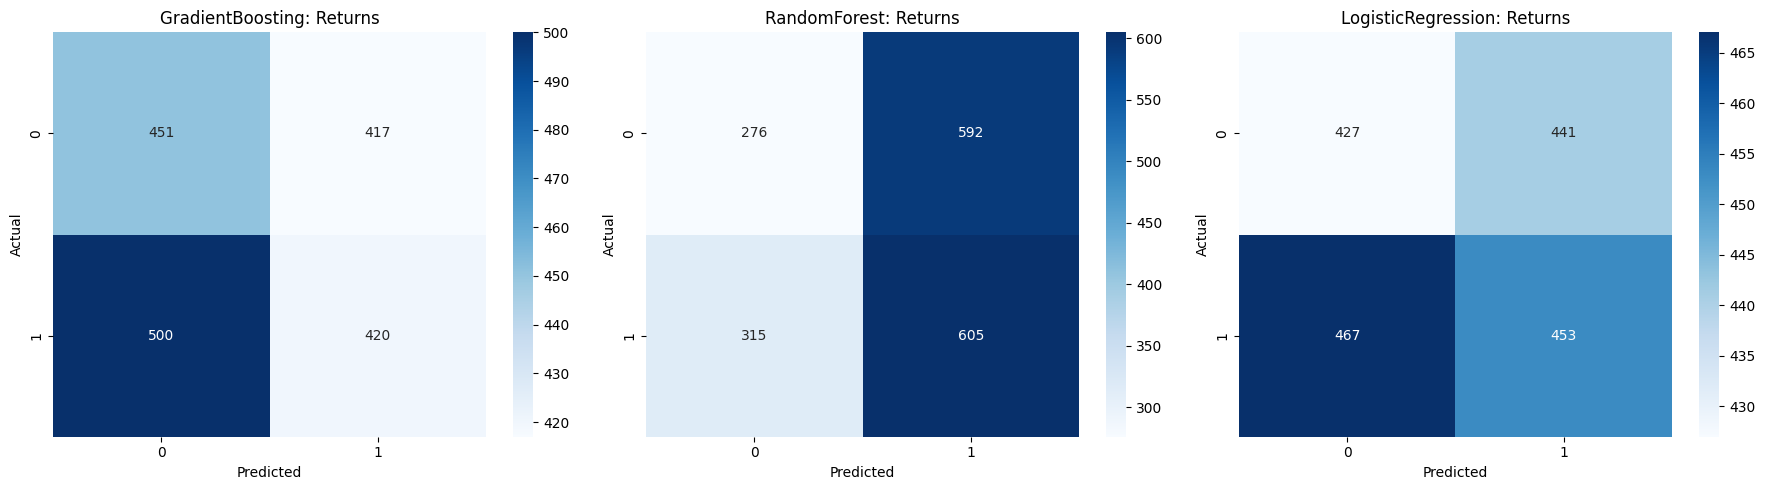

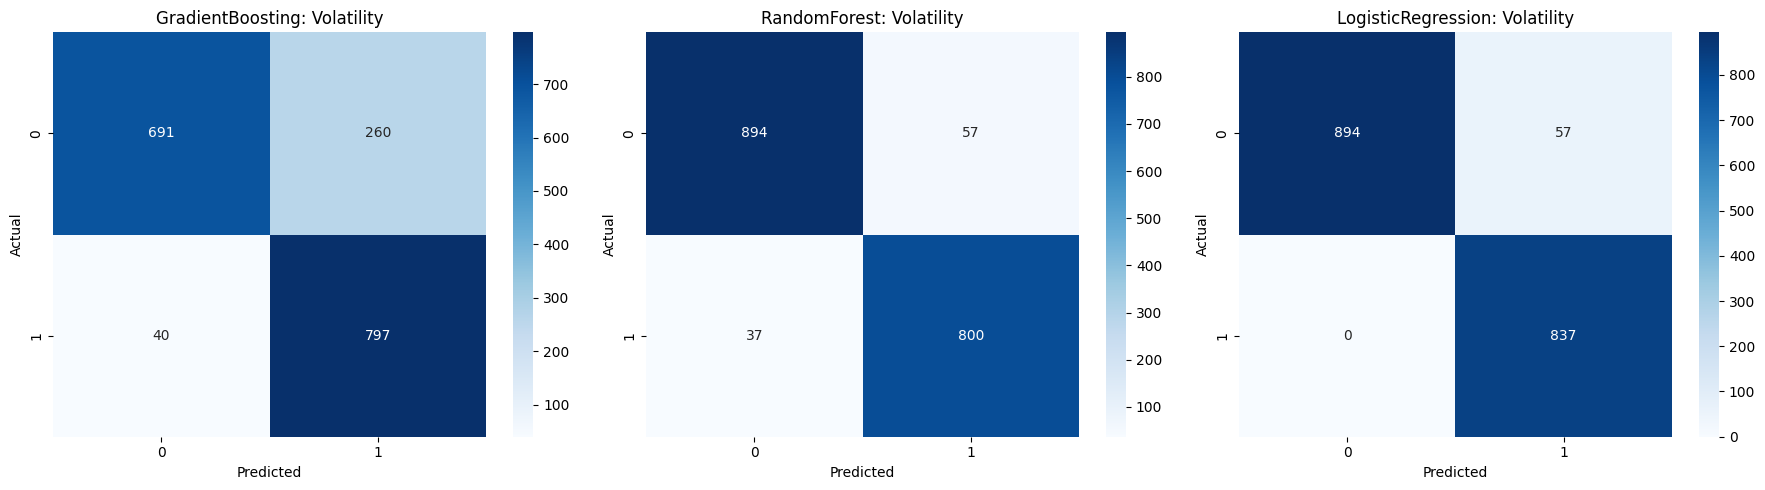

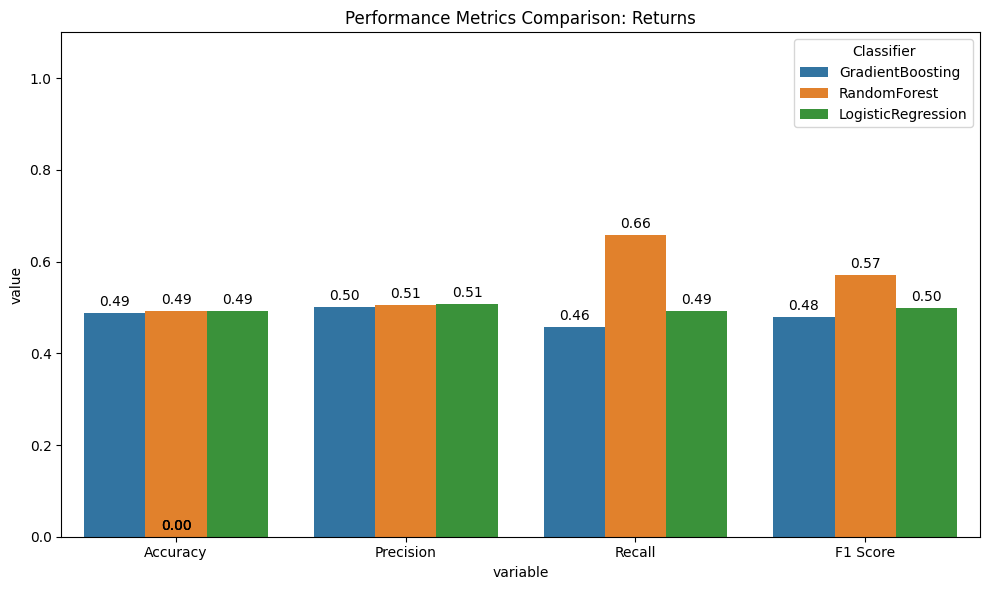

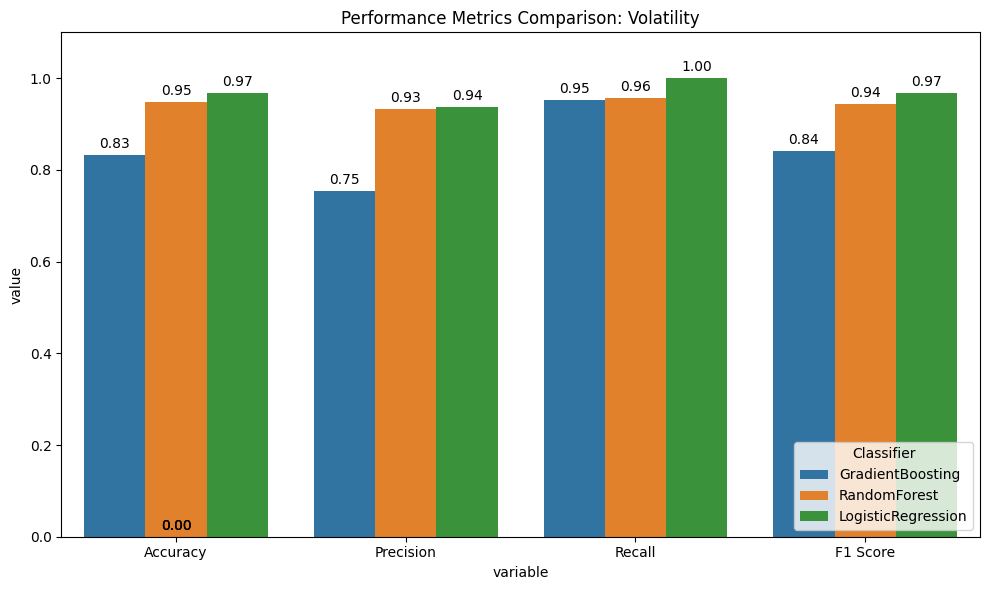

--- Final Classification Results ---
       Target          Classifier Accuracy (%) Precision (%) Recall (%)  \
0     Returns    GradientBoosting       48.71%        50.18%     45.65%   
1     Returns        RandomForest       49.27%        50.54%     65.76%   
2     Returns  LogisticRegression       49.22%        50.67%     49.24%   
3  Volatility    GradientBoosting       83.22%        75.40%     95.22%   
4  Volatility        RandomForest       94.74%        93.35%     95.58%   
5  Volatility  LogisticRegression       96.81%        93.62%    100.00%   

  F1 Score (%)  
0       47.81%  
1       57.16%  
2       49.94%  
3       84.16%  
4       94.45%  
5       96.71%  


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# ---------------------------------------------------------
# 1. DATA LOADING
# ---------------------------------------------------------
train_df = pd.read_csv('train_70pct.csv')
test_df = pd.read_csv('test_20pct.csv')

# ---------------------------------------------------------
# 2. FEATURE ENGINEERING & PREPROCESSING
# ---------------------------------------------------------
def prepare_modeling_data(df, is_train=True, vol_median=None):
    """
    Cleans data, calculates price returns, and creates binary targets.
    """
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values(['ticker', 'date'])

    # Calculate daily returns (Price % Change)
    df['returns'] = df.groupby('ticker')['price'].pct_change()

    # Define Target 1: Next day's return direction (1 if up, 0 if down/flat)
    df['target_return_class'] = df.groupby('ticker')['returns'].shift(-1).apply(lambda x: 1 if x > 0 else 0)

    # Define Target 2: Next day's volatility level (1 if High, 0 if Low)
    df['next_volatility'] = df.groupby('ticker')['volatility'].shift(-1)

    if is_train:
        vol_median = df['next_volatility'].median()

    df['target_volatility_class'] = df['next_volatility'].apply(lambda x: 1 if x > vol_median else 0)

    # Drop rows with NaN caused by shifting or pct_change
    df = df.dropna(subset=['target_return_class', 'target_volatility_class', 'returns'])

    return df, vol_median

# Process train and test sets
train_prepared, vol_med = prepare_modeling_data(train_df, is_train=True)
test_prepared, _ = prepare_modeling_data(test_df, is_train=False, vol_median=vol_med)

# Select requested on-chain features
features = ['tx_count', 'tx_volume', 'fees', 'hash_rate', 'NVT', 'liquidity']

X_train = train_prepared[features]
X_test = test_prepared[features]

# Group targets for the modeling loop
target_sets = {
    'Returns': (train_prepared['target_return_class'], test_prepared['target_return_class']),
    'Volatility': (train_prepared['target_volatility_class'], test_prepared['target_volatility_class'])
}

# ---------------------------------------------------------
# 3. MODEL TRAINING & EVALUATION
# ---------------------------------------------------------
models = {
    'GradientBoosting': GradientBoostingClassifier(random_state=42),
    'RandomForest': RandomForestClassifier(random_state=42),
    'LogisticRegression': LogisticRegression(random_state=42, max_iter=2000)
}

performance_records = []

for target_name, (y_train, y_test) in target_sets.items():
    # Setup plot for confusion matrices
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for i, (model_name, model) in enumerate(models.items()):
        # Fit model
        model.fit(X_train, y_train)

        # Predict
        preds = model.predict(X_test)

        # Calculate metrics
        acc = accuracy_score(y_test, preds)
        prec = precision_score(y_test, preds)
        rec = recall_score(y_test, preds)
        f1 = f1_score(y_test, preds)

        # Store metrics
        performance_records.append({
            'Target': target_name,
            'Classifier': model_name,
            'Accuracy': round(acc, 4),
            'Accuracy (%)': f"{acc*100:.2f}%",
            'Precision': round(prec, 4),
            'Precision (%)': f"{prec*100:.2f}%",
            'Recall': round(rec, 4),
            'Recall (%)': f"{rec*100:.2f}%",
            'F1 Score': round(f1, 4),
            'F1 Score (%)': f"{f1*100:.2f}%"
        })

        # Plot Confusion Matrix
        cm = confusion_matrix(y_test, preds)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
        axes[i].set_title(f'{model_name}: {target_name}')
        axes[i].set_xlabel('Predicted')
        axes[i].set_ylabel('Actual')

    plt.tight_layout()
    plt.savefig(f'confusion_matrices_{target_name.lower()}.png')
    plt.show()

# ---------------------------------------------------------
# 4. RESULTS VISUALIZATION & EXPORT
# ---------------------------------------------------------
results_df = pd.DataFrame(performance_records)

# Plotting performance comparison bar charts
for target in ['Returns', 'Volatility']:
    subset = results_df[results_df['Target'] == target].copy()
    # Reshape for plotting
    plot_data = subset.melt(id_vars=['Classifier'], value_vars=['Accuracy', 'Precision', 'Recall', 'F1 Score'])

    plt.figure(figsize=(10, 6))
    sns.barplot(data=plot_data, x='variable', y='value', hue='Classifier')
    plt.title(f'Performance Metrics Comparison: {target}')
    plt.ylim(0, 1.1)
    # Add value labels on bars
    for p in plt.gca().patches:
        plt.gca().annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                           ha='center', va='center', xytext=(0, 8), textcoords='offset points')
    plt.tight_layout()
    plt.savefig(f'metrics_comparison_{target.lower()}.png')
    plt.show()

# Final output
print("--- Final Classification Results ---")
print(results_df[['Target', 'Classifier', 'Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1 Score (%)']])

# Save to CSV
results_df.to_csv('rq2_modeling_results.csv', index=False)

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Crypto_2012_2026_En_final.csv to Crypto_2012_2026_En_final (2).csv


Loaded: Crypto_2012_2026_En_final (2).csv
Original shape: (8951, 14)

Class distribution:
speculative
0    8335
1     554
Name: count, dtype: int64

Class percentage:
speculative
0    93.77
1     6.23
Name: proportion, dtype: float64

Features used:
['tx_count', 'tx_volume', 'avg_tx_value', 'tx_count_change', 'tx_volume_change', 'avg_tx_change', 'tx_count_ma7', 'tx_count_ma14', 'tx_count_ma30', 'tx_volume_ma7', 'tx_volume_ma14', 'tx_volume_ma30', 'avg_tx_ma7', 'avg_tx_ma14', 'avg_tx_ma30', 'tx_count_lag1', 'tx_count_lag7', 'tx_volume_lag1', 'tx_volume_lag7', 'avg_tx_lag1', 'avg_tx_lag7', 'tx_volume_to_count_ratio', 'daily_return', 'return_abs', 'market_volume_change', 'market_volume_ma7', 'market_volume_ma30', 'market_cap', 'market_cap_change', 'fees', 'fees_per_tx', 'liquidity', 'volatility', 'DAA', 'DAA_change', 'DAA_ma7', 'NVT', 'NVT_change', 'NVT_ma7', 'hash_rate']


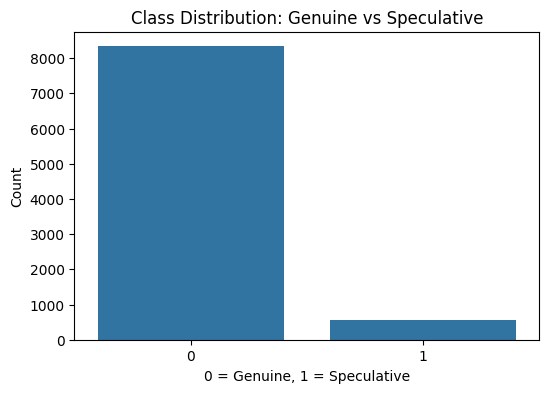

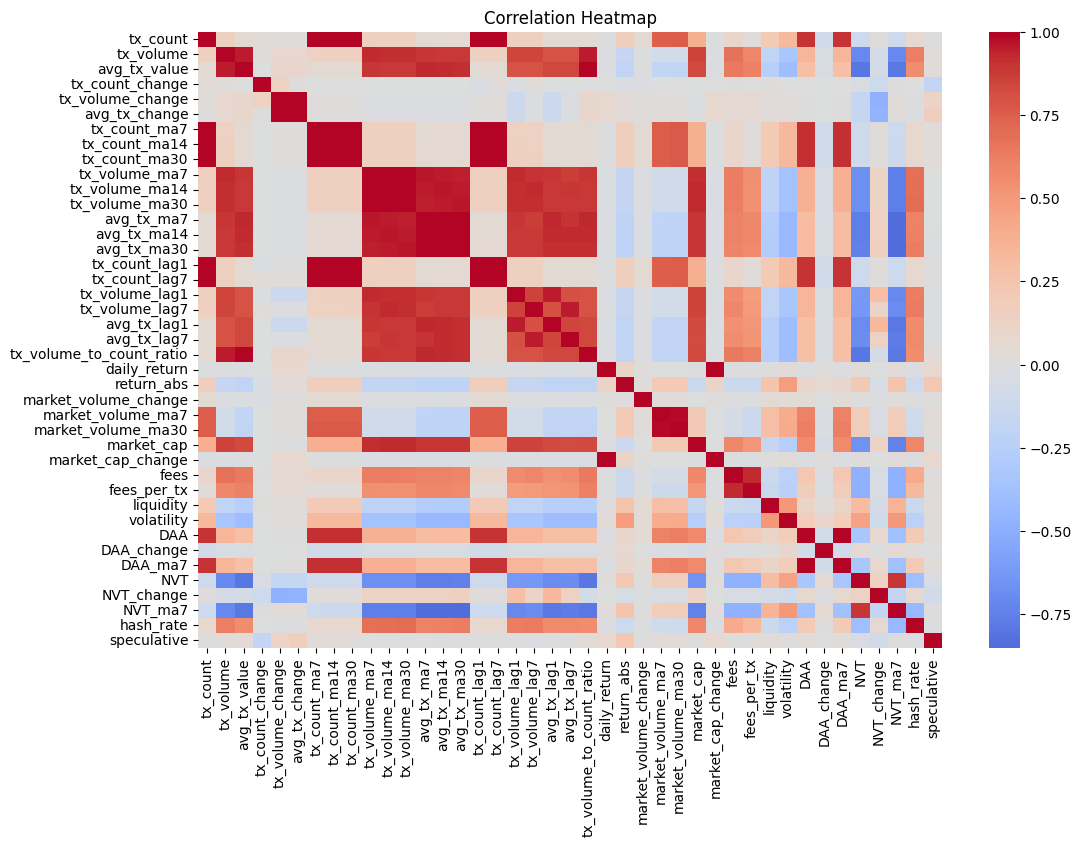


Train: (6222, 49)
Validation: (1333, 49)
Test: (1334, 49)

Before balancing:
speculative
0    5858
1     364
Name: count, dtype: int64

After SMOTEENN:
speculative
0    3279
1     690
Name: count, dtype: int64

Training: LightGBM

Training: XGBoost

================ FINAL TEST RESULTS ================
      Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC    PR-AUC  \
0  LightGBM  0.880810   0.386473  0.714286  0.501567  0.906922  0.605631   
1   XGBoost  0.842579   0.310078  0.714286  0.432432  0.866378  0.319502   

   Best Threshold  
0            0.06  
1            0.07  

Best Model: LightGBM

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.90      0.93      1222
           1       0.39      0.71      0.50       112

    accuracy                           0.88      1334
   macro avg       0.68      0.81      0.72      1334
weighted avg       0.92      0.88      0.90      1334



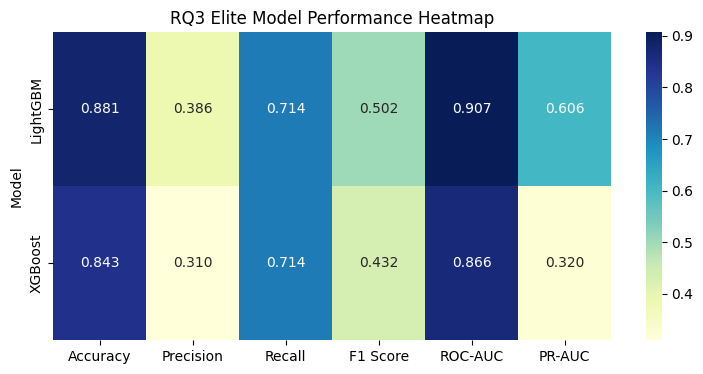

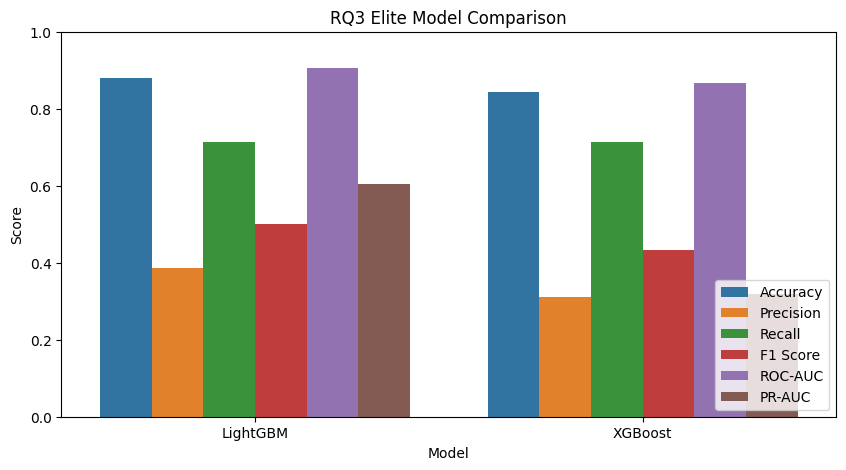

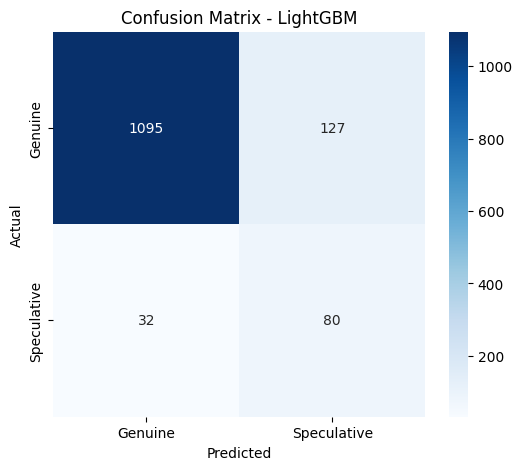

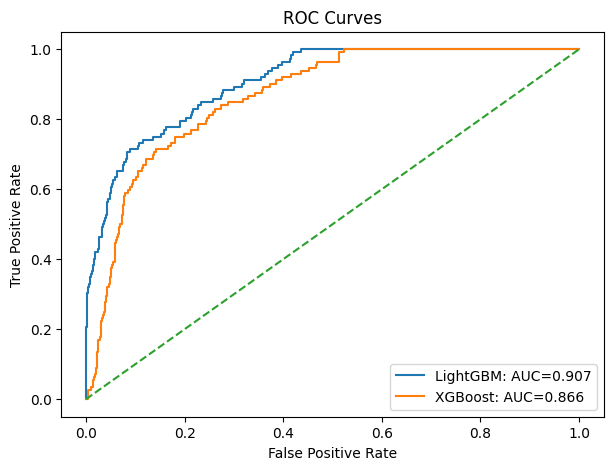

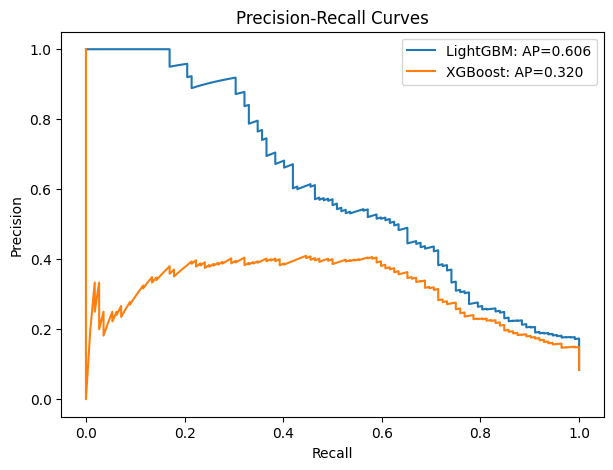

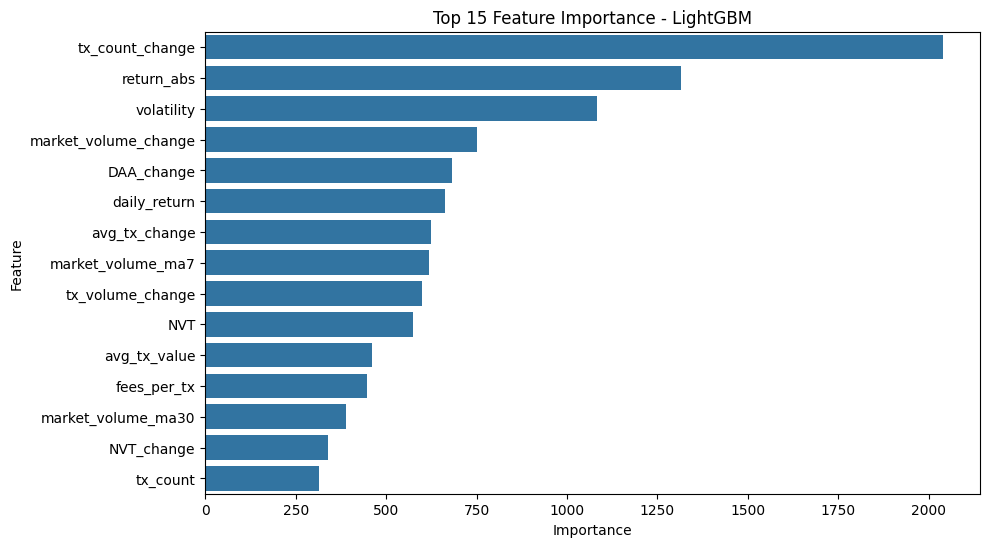

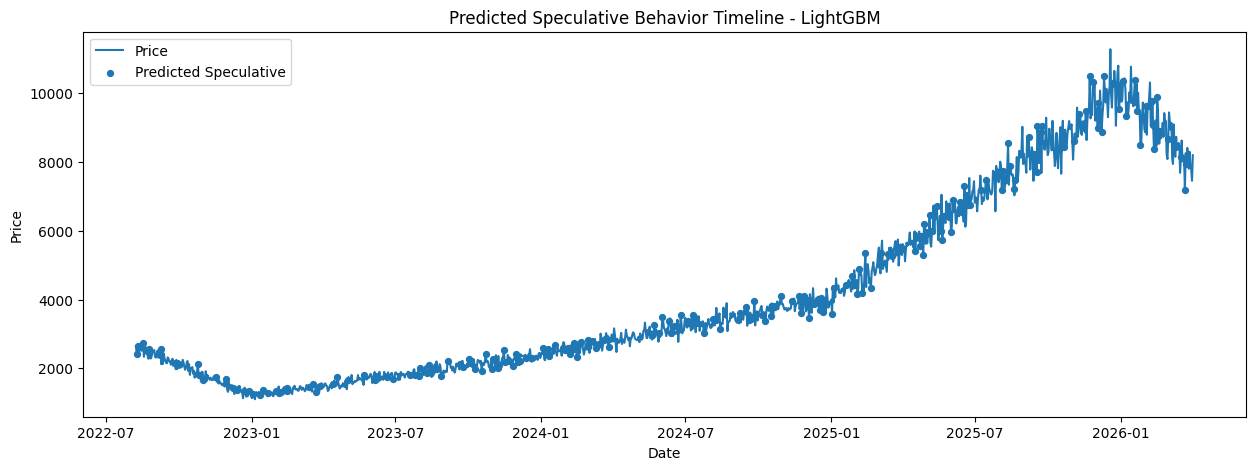

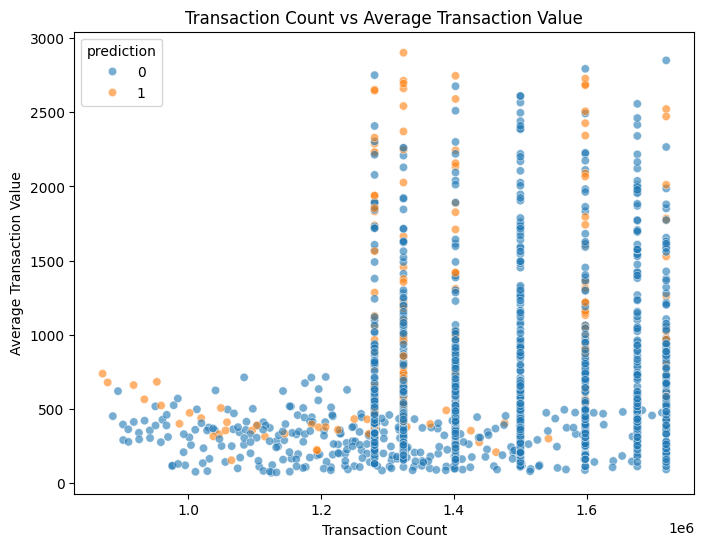

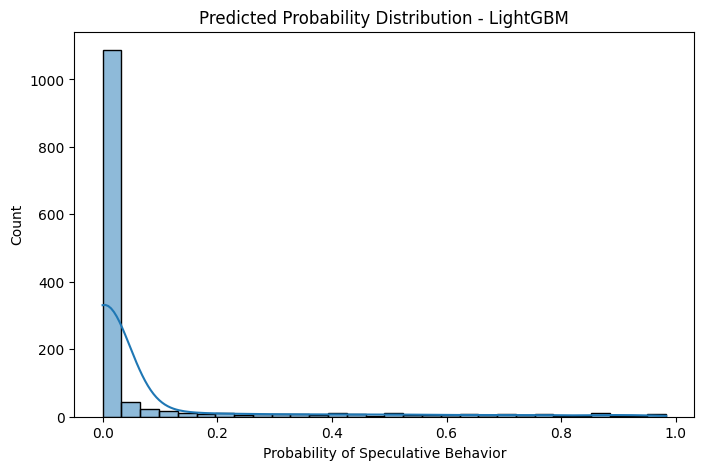

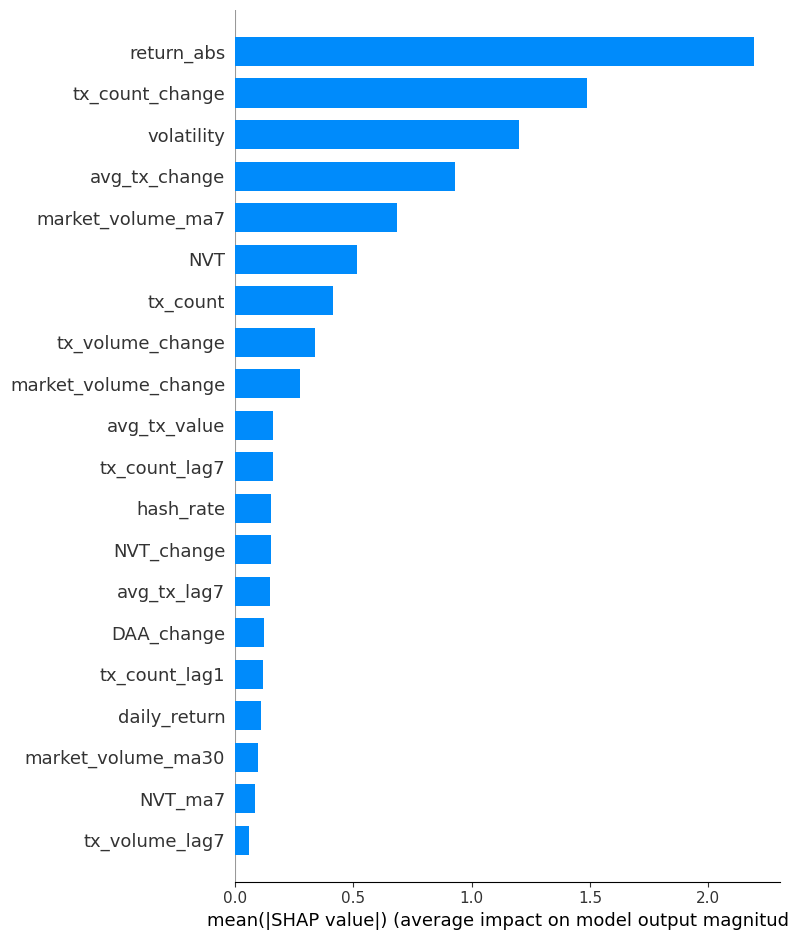

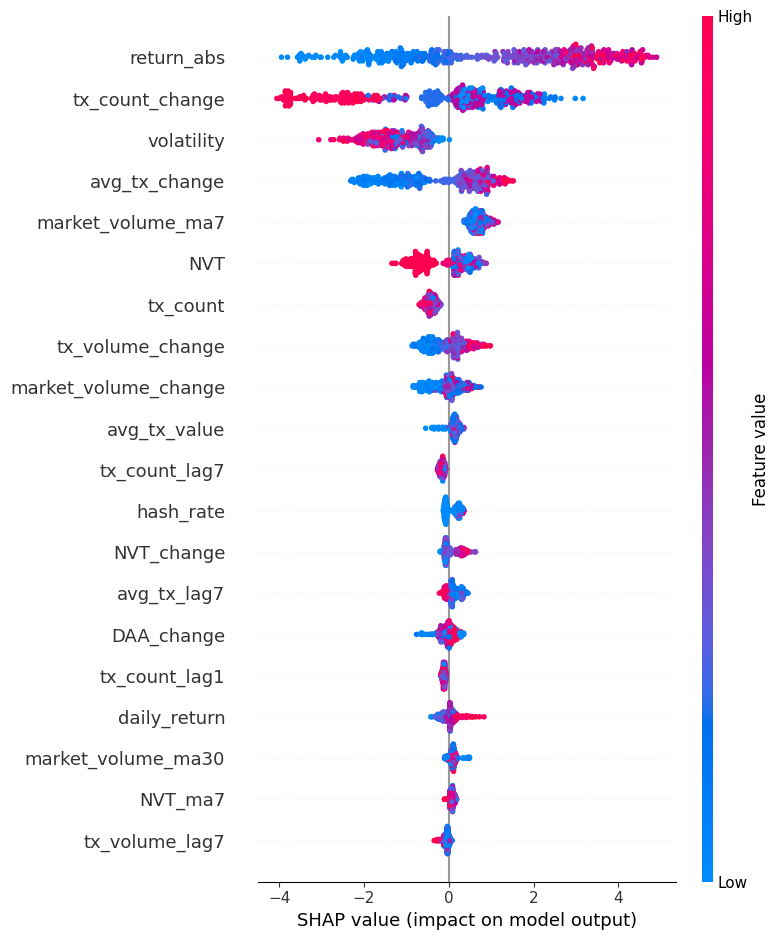


Saved files:
RQ3_elite_model_comparison.csv
RQ3_elite_feature_importance.csv
RQ3_elite_predictions.csv


In [ ]:
# ==========================================================
# ELITE RQ3 PIPELINE
# RQ3: Distinguishing genuine network usage from speculative behavior
# Models: LightGBM + XGBoost
# Includes: SMOTEENN, validation threshold tuning, heatmaps, ROC, PR, SHAP
# ==========================================================

!pip install -q xgboost lightgbm imbalanced-learn seaborn shap

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    roc_curve, auc,
    precision_recall_curve, average_precision_score
)

from imblearn.combine import SMOTEENN
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# ==========================================================
# LOAD DATA
# ==========================================================

file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)
df = df.drop(columns=["Unnamed: 0"], errors="ignore")

print("Loaded:", file_name)
print("Original shape:", df.shape)

# ==========================================================
# BASIC SETUP
# ==========================================================

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["ticker", "date"]).reset_index(drop=True)

# ==========================================================
# FEATURE ENGINEERING
# ==========================================================

df["daily_return"] = df.groupby("ticker")["price"].pct_change()
df["return_abs"] = df["daily_return"].abs()

df["avg_tx_value"] = df["tx_volume"] / (df["tx_count"] + 1)

df["tx_count_change"] = df.groupby("ticker")["tx_count"].pct_change()
df["tx_volume_change"] = df.groupby("ticker")["tx_volume"].pct_change()
df["avg_tx_change"] = df.groupby("ticker")["avg_tx_value"].pct_change()

df["tx_count_ma7"] = df.groupby("ticker")["tx_count"].transform(lambda x: x.rolling(7).mean())
df["tx_count_ma14"] = df.groupby("ticker")["tx_count"].transform(lambda x: x.rolling(14).mean())
df["tx_count_ma30"] = df.groupby("ticker")["tx_count"].transform(lambda x: x.rolling(30).mean())

df["tx_volume_ma7"] = df.groupby("ticker")["tx_volume"].transform(lambda x: x.rolling(7).mean())
df["tx_volume_ma14"] = df.groupby("ticker")["tx_volume"].transform(lambda x: x.rolling(14).mean())
df["tx_volume_ma30"] = df.groupby("ticker")["tx_volume"].transform(lambda x: x.rolling(30).mean())

df["avg_tx_ma7"] = df.groupby("ticker")["avg_tx_value"].transform(lambda x: x.rolling(7).mean())
df["avg_tx_ma14"] = df.groupby("ticker")["avg_tx_value"].transform(lambda x: x.rolling(14).mean())
df["avg_tx_ma30"] = df.groupby("ticker")["avg_tx_value"].transform(lambda x: x.rolling(30).mean())

df["tx_count_lag1"] = df.groupby("ticker")["tx_count"].shift(1)
df["tx_count_lag7"] = df.groupby("ticker")["tx_count"].shift(7)

df["tx_volume_lag1"] = df.groupby("ticker")["tx_volume"].shift(1)
df["tx_volume_lag7"] = df.groupby("ticker")["tx_volume"].shift(7)

df["avg_tx_lag1"] = df.groupby("ticker")["avg_tx_value"].shift(1)
df["avg_tx_lag7"] = df.groupby("ticker")["avg_tx_value"].shift(7)

df["tx_volume_to_count_ratio"] = df["tx_volume"] / (df["tx_count"] + 1)

if "volume" in df.columns:
    df["market_volume_change"] = df.groupby("ticker")["volume"].pct_change()
    df["market_volume_ma7"] = df.groupby("ticker")["volume"].transform(lambda x: x.rolling(7).mean())
    df["market_volume_ma30"] = df.groupby("ticker")["volume"].transform(lambda x: x.rolling(30).mean())

if "market_cap" in df.columns:
    df["market_cap_change"] = df.groupby("ticker")["market_cap"].pct_change()

if "fees" in df.columns:
    df["fees_per_tx"] = df["fees"] / (df["tx_count"] + 1)

if "NVT" in df.columns:
    df["NVT_change"] = df.groupby("ticker")["NVT"].pct_change()
    df["NVT_ma7"] = df.groupby("ticker")["NVT"].transform(lambda x: x.rolling(7).mean())

if "DAA" in df.columns:
    df["DAA_change"] = df.groupby("ticker")["DAA"].pct_change()
    df["DAA_ma7"] = df.groupby("ticker")["DAA"].transform(lambda x: x.rolling(7).mean())

# ==========================================================
# BETTER LABEL CREATION
# 0 = Genuine usage
# 1 = Speculative behavior
# ==========================================================

df["avg_tx_q65"] = df.groupby("ticker")["avg_tx_value"].transform(
    lambda x: x.rolling(30, min_periods=10).quantile(0.65)
)

df["return_q65"] = df.groupby("ticker")["return_abs"].transform(
    lambda x: x.rolling(30, min_periods=10).quantile(0.65)
)

df["tx_count_q55"] = df.groupby("ticker")["tx_count"].transform(
    lambda x: x.rolling(30, min_periods=10).quantile(0.55)
)

df["speculative"] = (
    (df["avg_tx_value"] > df["avg_tx_q65"]) &
    (df["return_abs"] > df["return_q65"]) &
    (df["tx_count"] <= df["tx_count_q55"])
).astype(int)

df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna().reset_index(drop=True)

print("\nClass distribution:")
print(df["speculative"].value_counts())
print("\nClass percentage:")
print((df["speculative"].value_counts(normalize=True) * 100).round(2))

# ==========================================================
# FEATURES
# ==========================================================

candidate_features = [
    "tx_count", "tx_volume", "avg_tx_value",
    "tx_count_change", "tx_volume_change", "avg_tx_change",
    "tx_count_ma7", "tx_count_ma14", "tx_count_ma30",
    "tx_volume_ma7", "tx_volume_ma14", "tx_volume_ma30",
    "avg_tx_ma7", "avg_tx_ma14", "avg_tx_ma30",
    "tx_count_lag1", "tx_count_lag7",
    "tx_volume_lag1", "tx_volume_lag7",
    "avg_tx_lag1", "avg_tx_lag7",
    "tx_volume_to_count_ratio",
    "daily_return", "return_abs",
    "market_volume_change", "market_volume_ma7", "market_volume_ma30",
    "market_cap", "market_cap_change",
    "fees", "fees_per_tx",
    "liquidity", "volatility",
    "DAA", "DAA_change", "DAA_ma7",
    "NVT", "NVT_change", "NVT_ma7",
    "hash_rate"
]

features = [f for f in candidate_features if f in df.columns]

print("\nFeatures used:")
print(features)

# ==========================================================
# INITIAL VISUALS
# ==========================================================

plt.figure(figsize=(6,4))
sns.countplot(x=df["speculative"])
plt.title("Class Distribution: Genuine vs Speculative")
plt.xlabel("0 = Genuine, 1 = Speculative")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(12,8))
corr = df[features + ["speculative"]].corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

# ==========================================================
# TIME-BASED TRAIN / VALIDATION / TEST SPLIT
# ==========================================================

train, temp = train_test_split(df, test_size=0.30, shuffle=False)
val, test = train_test_split(temp, test_size=0.50, shuffle=False)

X_train = train[features]
y_train = train["speculative"]

X_val = val[features]
y_val = val["speculative"]

X_test = test[features]
y_test = test["speculative"]

print("\nTrain:", train.shape)
print("Validation:", val.shape)
print("Test:", test.shape)

# ==========================================================
# SMOTEENN ONLY ON TRAINING DATA
# ==========================================================

sampler = SMOTEENN(random_state=42, sampling_strategy=0.45)

X_train_balanced, y_train_balanced = sampler.fit_resample(X_train, y_train)

print("\nBefore balancing:")
print(y_train.value_counts())

print("\nAfter SMOTEENN:")
print(pd.Series(y_train_balanced).value_counts())

# ==========================================================
# TWO STRONG MODELS
# ==========================================================

models = {
    "LightGBM": LGBMClassifier(
        n_estimators=500,
        learning_rate=0.035,
        max_depth=7,
        num_leaves=31,
        min_child_samples=15,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.1,
        reg_lambda=0.2,
        random_state=42,
        verbose=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.035,
        subsample=0.85,
        colsample_bytree=0.85,
        min_child_weight=2,
        gamma=0.1,
        reg_alpha=0.1,
        reg_lambda=1.0,
        tree_method="hist",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )
}

# ==========================================================
# TRAIN + VALIDATION THRESHOLD TUNING
# ==========================================================

results = []
predictions = {}
probabilities = {}
trained_models = {}

for name, model in models.items():

    print("\nTraining:", name)

    model.fit(X_train_balanced, y_train_balanced)

    val_probs = model.predict_proba(X_val)[:, 1]

    best_score = -1
    best_threshold = 0.5

    for threshold in np.arange(0.05, 0.91, 0.01):
        val_pred = (val_probs >= threshold).astype(int)

        precision = precision_score(y_val, val_pred, zero_division=0)
        recall = recall_score(y_val, val_pred, zero_division=0)
        f1 = f1_score(y_val, val_pred, zero_division=0)

        # balanced objective: prioritizes F1, but avoids very low precision/recall
        score = f1 + 0.15 * min(precision, recall)

        if score > best_score:
            best_score = score
            best_threshold = threshold

    test_probs = model.predict_proba(X_test)[:, 1]
    test_pred = (test_probs >= best_threshold).astype(int)

    acc = accuracy_score(y_test, test_pred)
    prec = precision_score(y_test, test_pred, zero_division=0)
    rec = recall_score(y_test, test_pred, zero_division=0)
    f1 = f1_score(y_test, test_pred, zero_division=0)

    fpr, tpr, _ = roc_curve(y_test, test_probs)
    roc_auc = auc(fpr, tpr)
    pr_auc = average_precision_score(y_test, test_probs)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc,
        "Best Threshold": best_threshold
    })

    predictions[name] = test_pred
    probabilities[name] = test_probs
    trained_models[name] = model

# ==========================================================
# FINAL RESULTS
# ==========================================================

results_df = pd.DataFrame(results).sort_values("F1 Score", ascending=False)

print("\n================ FINAL TEST RESULTS ================")
print(results_df)

best_model_name = results_df.iloc[0]["Model"]
best_pred = predictions[best_model_name]
best_probs = probabilities[best_model_name]
best_model = trained_models[best_model_name]

print("\nBest Model:", best_model_name)
print("\nClassification Report:")
print(classification_report(y_test, best_pred, zero_division=0))

# ==========================================================
# VISUALS
# ==========================================================

metric_cols = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC", "PR-AUC"]

plt.figure(figsize=(9,4))
sns.heatmap(
    results_df.set_index("Model")[metric_cols],
    annot=True,
    cmap="YlGnBu",
    fmt=".3f"
)
plt.title("RQ3 Elite Model Performance Heatmap")
plt.show()

results_melted = results_df.melt(
    id_vars="Model",
    value_vars=metric_cols,
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(10,5))
sns.barplot(data=results_melted, x="Model", y="Score", hue="Metric")
plt.ylim(0, 1)
plt.title("RQ3 Elite Model Comparison")
plt.legend(loc="lower right")
plt.show()

cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Genuine", "Speculative"],
    yticklabels=["Genuine", "Speculative"]
)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

plt.figure(figsize=(7,5))

for name in models.keys():
    fpr, tpr, _ = roc_curve(y_test, probabilities[name])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name}: AUC={roc_auc:.3f}")

plt.plot([0,1], [0,1], "--")
plt.title("ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

plt.figure(figsize=(7,5))

for name in models.keys():
    precision, recall, _ = precision_recall_curve(y_test, probabilities[name])
    ap = average_precision_score(y_test, probabilities[name])
    plt.plot(recall, precision, label=f"{name}: AP={ap:.3f}")

plt.title("Precision-Recall Curves")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": best_model.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=importance_df.head(15), x="Importance", y="Feature")
plt.title(f"Top 15 Feature Importance - {best_model_name}")
plt.show()

plot_df = test.copy()
plot_df["prediction"] = best_pred
plot_df["probability"] = best_probs

plt.figure(figsize=(15,5))
plt.plot(plot_df["date"], plot_df["price"], label="Price")

spec_days = plot_df[plot_df["prediction"] == 1]

plt.scatter(
    spec_days["date"],
    spec_days["price"],
    s=18,
    label="Predicted Speculative"
)

plt.title(f"Predicted Speculative Behavior Timeline - {best_model_name}")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=plot_df,
    x="tx_count",
    y="avg_tx_value",
    hue="prediction",
    alpha=0.6
)
plt.title("Transaction Count vs Average Transaction Value")
plt.xlabel("Transaction Count")
plt.ylabel("Average Transaction Value")
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(best_probs, bins=30, kde=True)
plt.title(f"Predicted Probability Distribution - {best_model_name}")
plt.xlabel("Probability of Speculative Behavior")
plt.show()

# ==========================================================
# SHAP
# ==========================================================

sample_size = min(500, len(X_test))
X_sample = X_test.sample(sample_size, random_state=42)

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_sample)

if isinstance(shap_values, list):
    shap_values_to_plot = shap_values[1]
else:
    shap_values_to_plot = shap_values

shap.summary_plot(shap_values_to_plot, X_sample, plot_type="bar", show=True)
shap.summary_plot(shap_values_to_plot, X_sample, show=True)

# ==========================================================
# SAVE OUTPUTS
# ==========================================================

results_df.to_csv("RQ3_elite_model_comparison.csv", index=False)
importance_df.to_csv("RQ3_elite_feature_importance.csv", index=False)
plot_df.to_csv("RQ3_elite_predictions.csv", index=False)

print("\nSaved files:")
print("RQ3_elite_model_comparison.csv")
print("RQ3_elite_feature_importance.csv")
print("RQ3_elite_predictions.csv")

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Crypto_2012_2026_En_final.csv to Crypto_2012_2026_En_final (3).csv


Loaded file: Crypto_2012_2026_En_final (3).csv
Original shape: (8951, 14)

Class distribution:
speculative
0    8335
1     554
Name: count, dtype: int64

Class percentage:
speculative
0    93.77
1     6.23
Name: proportion, dtype: float64

Features used:
['tx_count', 'tx_volume', 'avg_tx_value', 'tx_count_change', 'tx_volume_change', 'avg_tx_change', 'tx_count_ma7', 'tx_count_ma14', 'tx_count_ma30', 'tx_volume_ma7', 'tx_volume_ma14', 'tx_volume_ma30', 'avg_tx_ma7', 'avg_tx_ma14', 'avg_tx_ma30', 'tx_count_lag1', 'tx_count_lag7', 'tx_volume_lag1', 'tx_volume_lag7', 'avg_tx_lag1', 'avg_tx_lag7', 'tx_volume_to_count_ratio', 'daily_return', 'return_abs', 'market_volume_change', 'market_volume_ma7', 'market_volume_ma30', 'market_cap', 'market_cap_change', 'fees', 'fees_per_tx', 'liquidity', 'volatility', 'DAA', 'DAA_change', 'DAA_ma7', 'NVT', 'NVT_change', 'NVT_ma7', 'hash_rate']


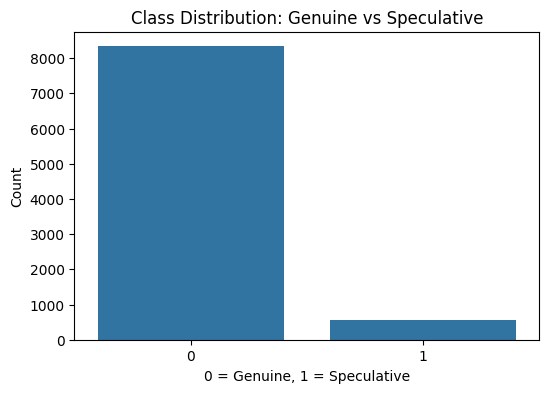

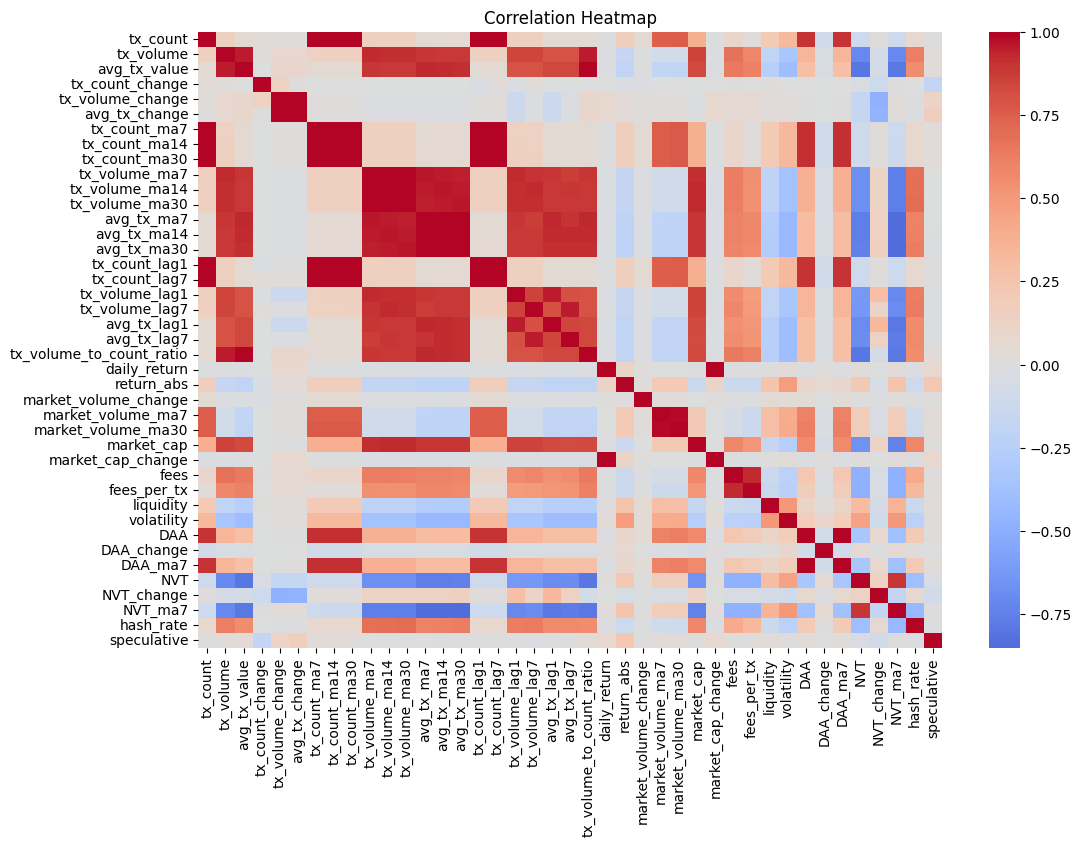


Train: (6222, 49)
Validation: (1333, 49)
Test: (1334, 49)

Train class distribution:
speculative
0    5858
1     364
Name: count, dtype: int64

Validation class distribution:
speculative
0    1255
1      78
Name: count, dtype: int64

Test class distribution:
speculative
0    1222
1     112
Name: count, dtype: int64

After SMOTE:
speculative
0    5858
1    2050
Name: count, dtype: int64

After SMOTEENN:
speculative
0    3279
1     690
Name: count, dtype: int64

Training: LightGBM_SMOTE

Training: LightGBM_SMOTEENN

Training: XGBoost_SMOTE

Training: XGBoost_SMOTEENN

================ GOD MODE FINAL TEST RESULTS ================
               Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC  \
0     LightGBM_SMOTE  0.934783   0.612613  0.607143  0.609865  0.889598   
1  LightGBM_SMOTEENN  0.880810   0.386473  0.714286  0.501567  0.906922   
3   XGBoost_SMOTEENN  0.835082   0.298507  0.714286  0.421053  0.866378   
2      XGBoost_SMOTE  0.853073   0.300000  0.562500  0.391304  0

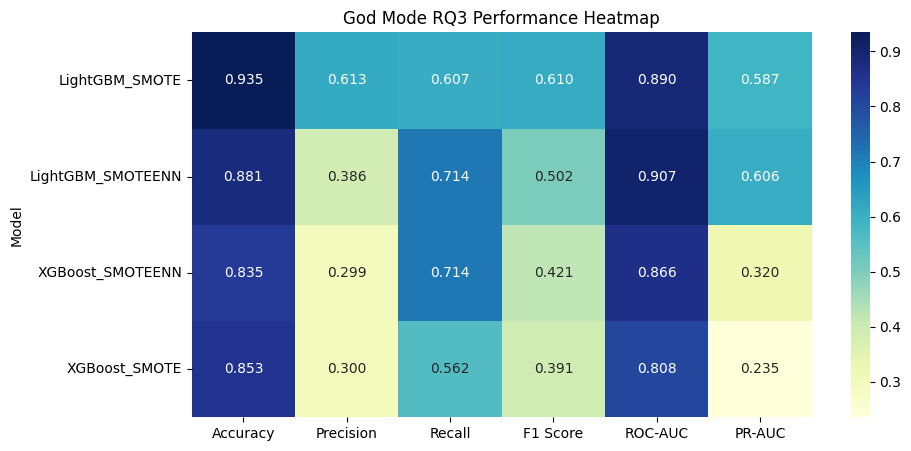

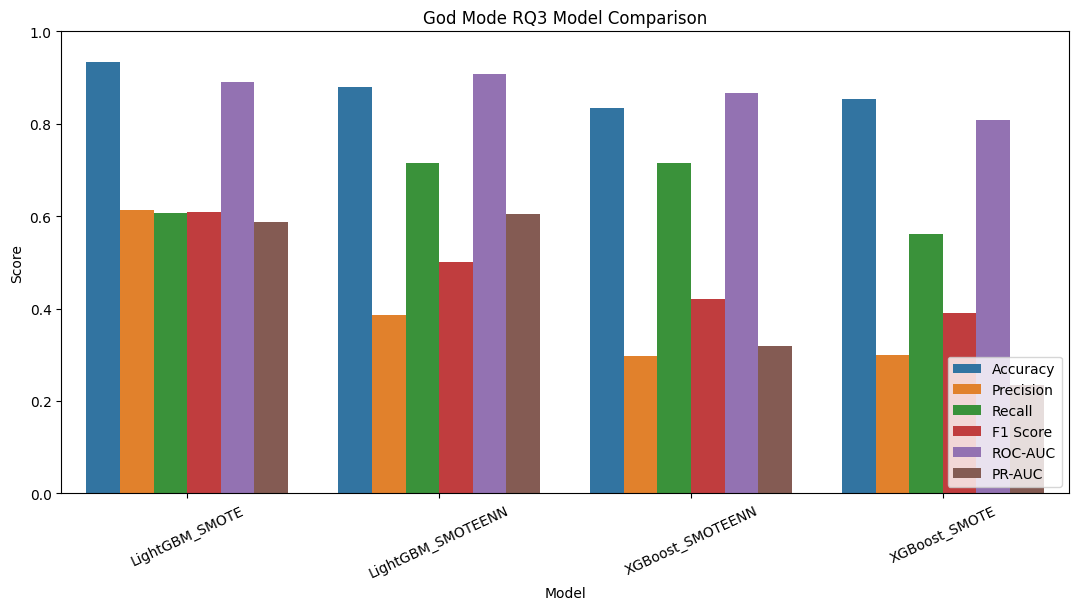

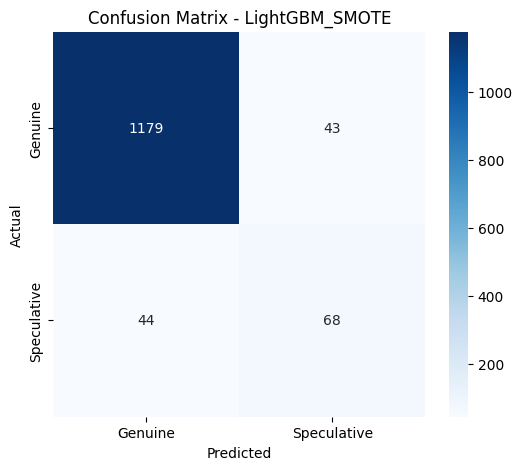

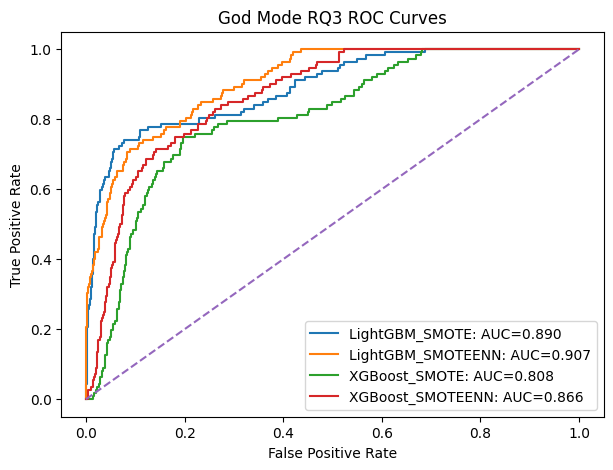

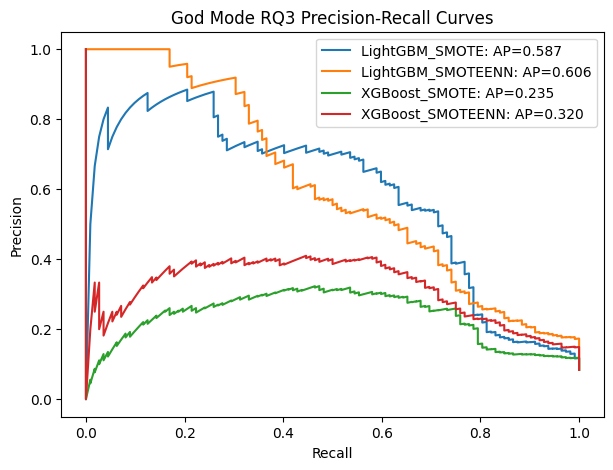

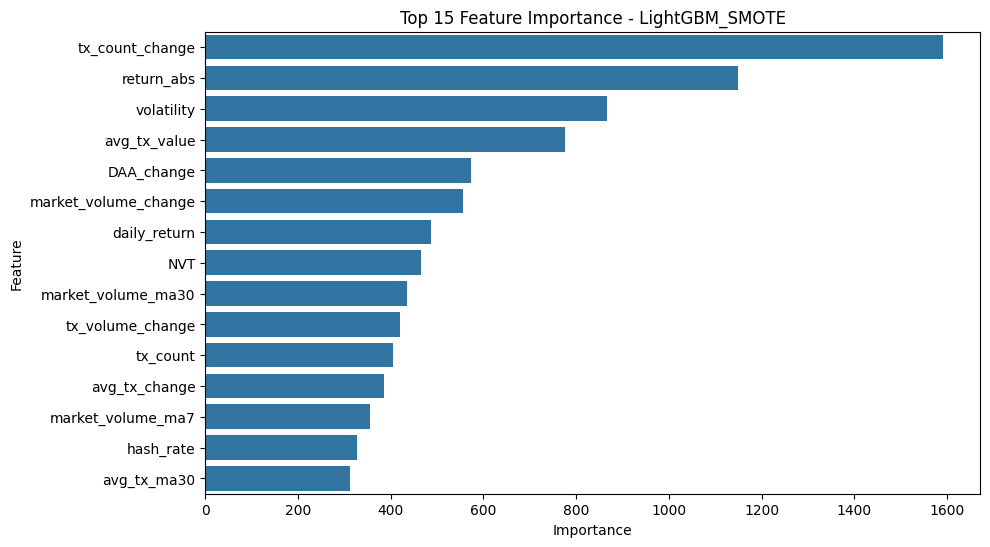

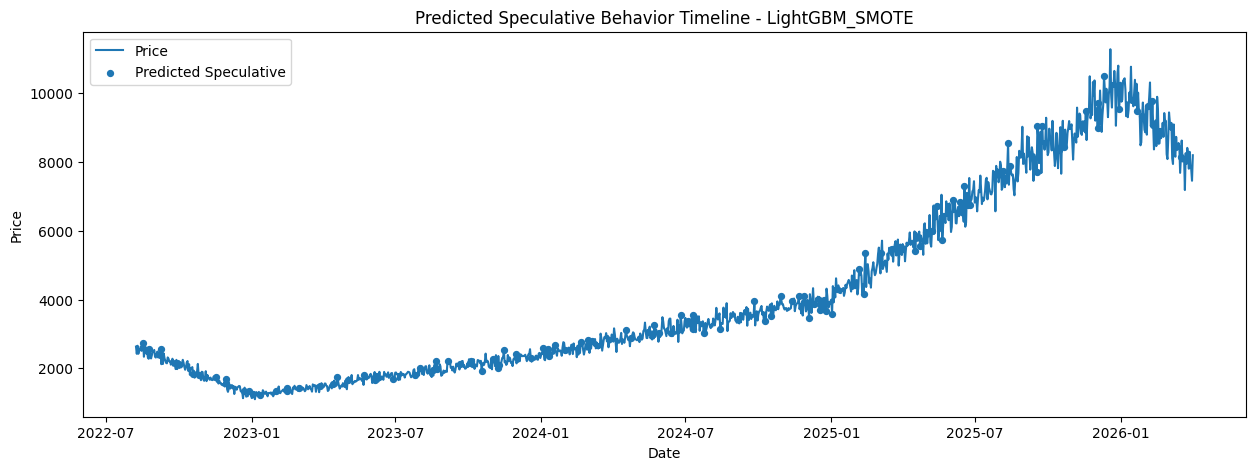

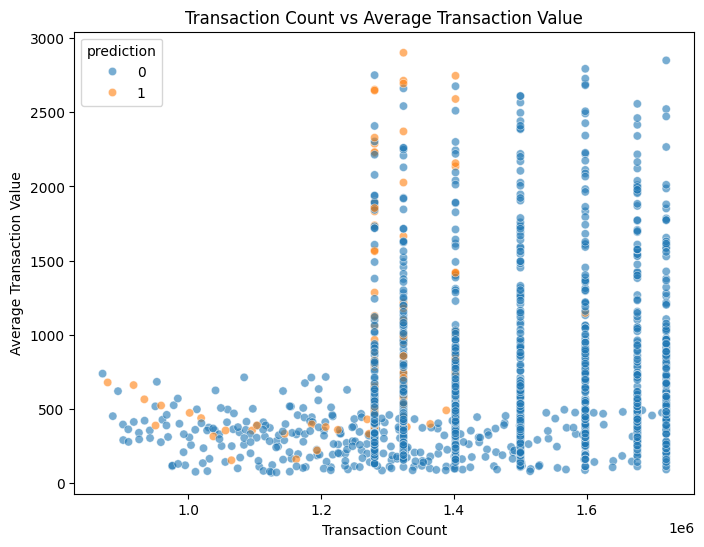

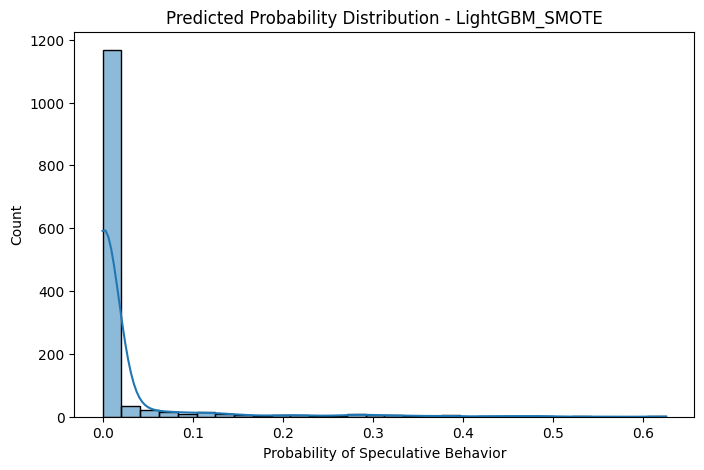

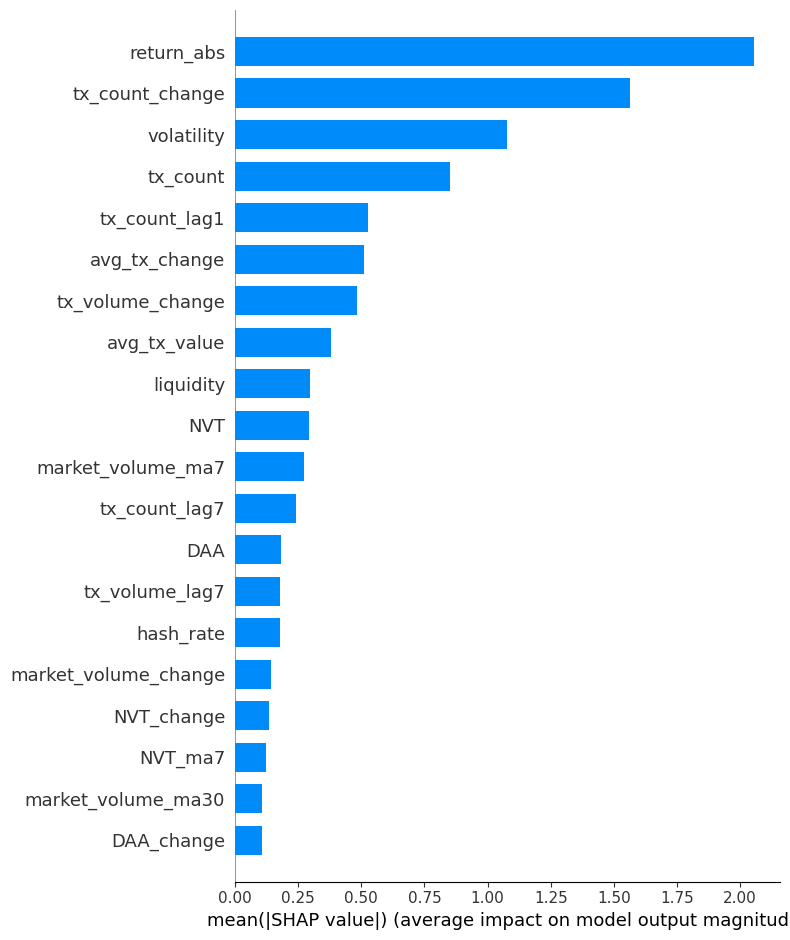

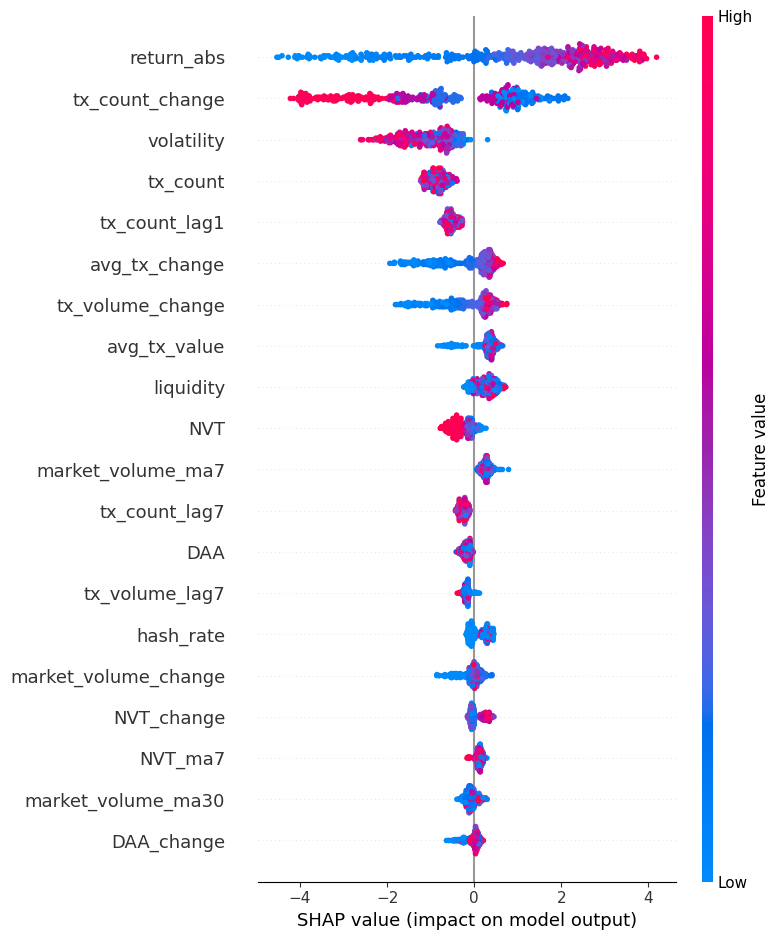


Saved files:
RQ3_god_mode_model_comparison.csv
RQ3_god_mode_feature_importance.csv
RQ3_god_mode_predictions.csv


In [ ]:
# ==========================================================
# GOD MODE RQ3 PIPELINE
# Combines OLD model strength + ELITE model strength
#
# Goal:
# - keep accuracy strong
# - improve precision compared with Elite
# - keep recall better than Old
# - use balanced threshold tuning
# ==========================================================

!pip install -q xgboost lightgbm imbalanced-learn seaborn shap

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    roc_curve, auc,
    precision_recall_curve, average_precision_score
)

from imblearn.combine import SMOTEENN
from imblearn.over_sampling import SMOTE

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

# ==========================================================
# LOAD DATA
# ==========================================================

file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)
df = df.drop(columns=["Unnamed: 0"], errors="ignore")

print("Loaded file:", file_name)
print("Original shape:", df.shape)

# ==========================================================
# BASIC SETUP
# ==========================================================

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["ticker", "date"]).reset_index(drop=True)

# ==========================================================
# FEATURE ENGINEERING
# ==========================================================

df["daily_return"] = df.groupby("ticker")["price"].pct_change()
df["return_abs"] = df["daily_return"].abs()

df["avg_tx_value"] = df["tx_volume"] / (df["tx_count"] + 1)

df["tx_count_change"] = df.groupby("ticker")["tx_count"].pct_change()
df["tx_volume_change"] = df.groupby("ticker")["tx_volume"].pct_change()
df["avg_tx_change"] = df.groupby("ticker")["avg_tx_value"].pct_change()

df["tx_count_ma7"] = df.groupby("ticker")["tx_count"].transform(lambda x: x.rolling(7).mean())
df["tx_count_ma14"] = df.groupby("ticker")["tx_count"].transform(lambda x: x.rolling(14).mean())
df["tx_count_ma30"] = df.groupby("ticker")["tx_count"].transform(lambda x: x.rolling(30).mean())

df["tx_volume_ma7"] = df.groupby("ticker")["tx_volume"].transform(lambda x: x.rolling(7).mean())
df["tx_volume_ma14"] = df.groupby("ticker")["tx_volume"].transform(lambda x: x.rolling(14).mean())
df["tx_volume_ma30"] = df.groupby("ticker")["tx_volume"].transform(lambda x: x.rolling(30).mean())

df["avg_tx_ma7"] = df.groupby("ticker")["avg_tx_value"].transform(lambda x: x.rolling(7).mean())
df["avg_tx_ma14"] = df.groupby("ticker")["avg_tx_value"].transform(lambda x: x.rolling(14).mean())
df["avg_tx_ma30"] = df.groupby("ticker")["avg_tx_value"].transform(lambda x: x.rolling(30).mean())

df["tx_count_lag1"] = df.groupby("ticker")["tx_count"].shift(1)
df["tx_count_lag7"] = df.groupby("ticker")["tx_count"].shift(7)

df["tx_volume_lag1"] = df.groupby("ticker")["tx_volume"].shift(1)
df["tx_volume_lag7"] = df.groupby("ticker")["tx_volume"].shift(7)

df["avg_tx_lag1"] = df.groupby("ticker")["avg_tx_value"].shift(1)
df["avg_tx_lag7"] = df.groupby("ticker")["avg_tx_value"].shift(7)

df["tx_volume_to_count_ratio"] = df["tx_volume"] / (df["tx_count"] + 1)

if "volume" in df.columns:
    df["market_volume_change"] = df.groupby("ticker")["volume"].pct_change()
    df["market_volume_ma7"] = df.groupby("ticker")["volume"].transform(lambda x: x.rolling(7).mean())
    df["market_volume_ma30"] = df.groupby("ticker")["volume"].transform(lambda x: x.rolling(30).mean())

if "market_cap" in df.columns:
    df["market_cap_change"] = df.groupby("ticker")["market_cap"].pct_change()

if "fees" in df.columns:
    df["fees_per_tx"] = df["fees"] / (df["tx_count"] + 1)

if "NVT" in df.columns:
    df["NVT_change"] = df.groupby("ticker")["NVT"].pct_change()
    df["NVT_ma7"] = df.groupby("ticker")["NVT"].transform(lambda x: x.rolling(7).mean())

if "DAA" in df.columns:
    df["DAA_change"] = df.groupby("ticker")["DAA"].pct_change()
    df["DAA_ma7"] = df.groupby("ticker")["DAA"].transform(lambda x: x.rolling(7).mean())

# ==========================================================
# LABEL CREATION
# Balanced label:
# 0 = Genuine usage
# 1 = Speculative behavior
# ==========================================================

df["avg_tx_q65"] = df.groupby("ticker")["avg_tx_value"].transform(
    lambda x: x.rolling(30, min_periods=10).quantile(0.65)
)

df["return_q65"] = df.groupby("ticker")["return_abs"].transform(
    lambda x: x.rolling(30, min_periods=10).quantile(0.65)
)

df["tx_count_q55"] = df.groupby("ticker")["tx_count"].transform(
    lambda x: x.rolling(30, min_periods=10).quantile(0.55)
)

df["speculative"] = (
    (df["avg_tx_value"] > df["avg_tx_q65"]) &
    (df["return_abs"] > df["return_q65"]) &
    (df["tx_count"] <= df["tx_count_q55"])
).astype(int)

df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna().reset_index(drop=True)

print("\nClass distribution:")
print(df["speculative"].value_counts())

print("\nClass percentage:")
print((df["speculative"].value_counts(normalize=True) * 100).round(2))

# ==========================================================
# FEATURES
# ==========================================================

candidate_features = [
    "tx_count", "tx_volume", "avg_tx_value",
    "tx_count_change", "tx_volume_change", "avg_tx_change",
    "tx_count_ma7", "tx_count_ma14", "tx_count_ma30",
    "tx_volume_ma7", "tx_volume_ma14", "tx_volume_ma30",
    "avg_tx_ma7", "avg_tx_ma14", "avg_tx_ma30",
    "tx_count_lag1", "tx_count_lag7",
    "tx_volume_lag1", "tx_volume_lag7",
    "avg_tx_lag1", "avg_tx_lag7",
    "tx_volume_to_count_ratio",
    "daily_return", "return_abs",
    "market_volume_change", "market_volume_ma7", "market_volume_ma30",
    "market_cap", "market_cap_change",
    "fees", "fees_per_tx",
    "liquidity", "volatility",
    "DAA", "DAA_change", "DAA_ma7",
    "NVT", "NVT_change", "NVT_ma7",
    "hash_rate"
]

features = [f for f in candidate_features if f in df.columns]

print("\nFeatures used:")
print(features)

# ==========================================================
# VISUAL: CLASS DISTRIBUTION + CORRELATION
# ==========================================================

plt.figure(figsize=(6,4))
sns.countplot(x=df["speculative"])
plt.title("Class Distribution: Genuine vs Speculative")
plt.xlabel("0 = Genuine, 1 = Speculative")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(12,8))
corr = df[features + ["speculative"]].corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

# ==========================================================
# TIME-BASED TRAIN / VALIDATION / TEST SPLIT
# ==========================================================

train, temp = train_test_split(df, test_size=0.30, shuffle=False)
val, test = train_test_split(temp, test_size=0.50, shuffle=False)

X_train = train[features]
y_train = train["speculative"]

X_val = val[features]
y_val = val["speculative"]

X_test = test[features]
y_test = test["speculative"]

print("\nTrain:", train.shape)
print("Validation:", val.shape)
print("Test:", test.shape)

print("\nTrain class distribution:")
print(y_train.value_counts())

print("\nValidation class distribution:")
print(y_val.value_counts())

print("\nTest class distribution:")
print(y_test.value_counts())

# ==========================================================
# TWO BALANCING STRATEGIES
# 1. SMOTE = less aggressive, better precision
# 2. SMOTEENN = more aggressive, better recall
# ==========================================================

smote = SMOTE(
    random_state=42,
    sampling_strategy=0.35
)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

smoteenn = SMOTEENN(
    random_state=42,
    sampling_strategy=0.45
)

X_train_smoteenn, y_train_smoteenn = smoteenn.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())

print("\nAfter SMOTEENN:")
print(pd.Series(y_train_smoteenn).value_counts())

# ==========================================================
# MODEL SETUP
# 4 variants:
# LightGBM + SMOTE
# LightGBM + SMOTEENN
# XGBoost + SMOTE
# XGBoost + SMOTEENN
# ==========================================================

model_configs = {
    "LightGBM_SMOTE": {
        "model": LGBMClassifier(
            n_estimators=450,
            learning_rate=0.035,
            max_depth=7,
            num_leaves=31,
            min_child_samples=15,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_alpha=0.1,
            reg_lambda=0.2,
            random_state=42,
            verbose=-1
        ),
        "X": X_train_smote,
        "y": y_train_smote
    },

    "LightGBM_SMOTEENN": {
        "model": LGBMClassifier(
            n_estimators=500,
            learning_rate=0.035,
            max_depth=7,
            num_leaves=31,
            min_child_samples=15,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_alpha=0.1,
            reg_lambda=0.2,
            random_state=42,
            verbose=-1
        ),
        "X": X_train_smoteenn,
        "y": y_train_smoteenn
    },

    "XGBoost_SMOTE": {
        "model": XGBClassifier(
            n_estimators=450,
            max_depth=6,
            learning_rate=0.035,
            subsample=0.85,
            colsample_bytree=0.85,
            min_child_weight=2,
            gamma=0.1,
            reg_alpha=0.1,
            reg_lambda=1.0,
            tree_method="hist",
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        ),
        "X": X_train_smote,
        "y": y_train_smote
    },

    "XGBoost_SMOTEENN": {
        "model": XGBClassifier(
            n_estimators=500,
            max_depth=6,
            learning_rate=0.035,
            subsample=0.85,
            colsample_bytree=0.85,
            min_child_weight=2,
            gamma=0.1,
            reg_alpha=0.1,
            reg_lambda=1.0,
            tree_method="hist",
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        ),
        "X": X_train_smoteenn,
        "y": y_train_smoteenn
    }
}

# ==========================================================
# TRAIN + BALANCED THRESHOLD TUNING ON VALIDATION
# ==========================================================

results = []
predictions = {}
probabilities = {}
trained_models = {}

for name, cfg in model_configs.items():

    print("\nTraining:", name)

    model = cfg["model"]
    model.fit(cfg["X"], cfg["y"])

    val_probs = model.predict_proba(X_val)[:, 1]

    best_score = -1
    best_threshold = 0.5
    best_val_metrics = None

    for threshold in np.arange(0.05, 0.91, 0.01):

        val_pred = (val_probs >= threshold).astype(int)

        precision = precision_score(y_val, val_pred, zero_division=0)
        recall = recall_score(y_val, val_pred, zero_division=0)
        f1 = f1_score(y_val, val_pred, zero_division=0)
        accuracy = accuracy_score(y_val, val_pred)

        # GOD MODE objective:
        # balances precision + recall + F1 + accuracy
        score = (
            0.30 * precision +
            0.30 * recall +
            0.30 * f1 +
            0.10 * accuracy
        )

        # avoid choosing too extreme thresholds
        if precision < 0.35 or recall < 0.35:
            score -= 0.10

        if score > best_score:
            best_score = score
            best_threshold = threshold
            best_val_metrics = (accuracy, precision, recall, f1)

    test_probs = model.predict_proba(X_test)[:, 1]
    test_pred = (test_probs >= best_threshold).astype(int)

    acc = accuracy_score(y_test, test_pred)
    prec = precision_score(y_test, test_pred, zero_division=0)
    rec = recall_score(y_test, test_pred, zero_division=0)
    f1 = f1_score(y_test, test_pred, zero_division=0)

    fpr, tpr, _ = roc_curve(y_test, test_probs)
    roc_auc = auc(fpr, tpr)
    pr_auc = average_precision_score(y_test, test_probs)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc,
        "Best Threshold": best_threshold,
        "Validation Accuracy": best_val_metrics[0],
        "Validation Precision": best_val_metrics[1],
        "Validation Recall": best_val_metrics[2],
        "Validation F1": best_val_metrics[3]
    })

    predictions[name] = test_pred
    probabilities[name] = test_probs
    trained_models[name] = model

# ==========================================================
# RESULTS
# ==========================================================

results_df = pd.DataFrame(results).sort_values("F1 Score", ascending=False)

print("\n================ GOD MODE FINAL TEST RESULTS ================")
print(results_df)

best_model_name = results_df.iloc[0]["Model"]
best_pred = predictions[best_model_name]
best_probs = probabilities[best_model_name]
best_model = trained_models[best_model_name]

print("\nBest Model:", best_model_name)
print("\nClassification Report:")
print(classification_report(y_test, best_pred, zero_division=0))

# ==========================================================
# VISUAL 1: PERFORMANCE HEATMAP
# ==========================================================

metric_cols = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC",
    "PR-AUC"
]

plt.figure(figsize=(10,5))
sns.heatmap(
    results_df.set_index("Model")[metric_cols],
    annot=True,
    cmap="YlGnBu",
    fmt=".3f"
)
plt.title("God Mode RQ3 Performance Heatmap")
plt.show()

# ==========================================================
# VISUAL 2: PERFORMANCE BAR CHART
# ==========================================================

results_melted = results_df.melt(
    id_vars="Model",
    value_vars=metric_cols,
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(13,6))
sns.barplot(
    data=results_melted,
    x="Model",
    y="Score",
    hue="Metric"
)
plt.ylim(0, 1)
plt.title("God Mode RQ3 Model Comparison")
plt.xticks(rotation=25)
plt.legend(loc="lower right")
plt.show()

# ==========================================================
# VISUAL 3: CONFUSION MATRIX
# ==========================================================

cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Genuine", "Speculative"],
    yticklabels=["Genuine", "Speculative"]
)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ==========================================================
# VISUAL 4: ROC CURVES
# ==========================================================

plt.figure(figsize=(7,5))

for name in model_configs.keys():
    fpr, tpr, _ = roc_curve(y_test, probabilities[name])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name}: AUC={roc_auc:.3f}")

plt.plot([0,1], [0,1], "--")
plt.title("God Mode RQ3 ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# ==========================================================
# VISUAL 5: PRECISION-RECALL CURVES
# ==========================================================

plt.figure(figsize=(7,5))

for name in model_configs.keys():
    precision, recall, _ = precision_recall_curve(
        y_test,
        probabilities[name]
    )
    ap = average_precision_score(y_test, probabilities[name])
    plt.plot(recall, precision, label=f"{name}: AP={ap:.3f}")

plt.title("God Mode RQ3 Precision-Recall Curves")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

# ==========================================================
# VISUAL 6: FEATURE IMPORTANCE
# ==========================================================

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": best_model.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(
    data=importance_df.head(15),
    x="Importance",
    y="Feature"
)
plt.title(f"Top 15 Feature Importance - {best_model_name}")
plt.show()

# ==========================================================
# VISUAL 7: PRICE TIMELINE
# ==========================================================

plot_df = test.copy()
plot_df["prediction"] = best_pred
plot_df["probability"] = best_probs

plt.figure(figsize=(15,5))
plt.plot(plot_df["date"], plot_df["price"], label="Price")

spec_days = plot_df[plot_df["prediction"] == 1]

plt.scatter(
    spec_days["date"],
    spec_days["price"],
    s=18,
    label="Predicted Speculative"
)

plt.title(f"Predicted Speculative Behavior Timeline - {best_model_name}")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

# ==========================================================
# VISUAL 8: TRANSACTION PATTERN SCATTER
# ==========================================================

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=plot_df,
    x="tx_count",
    y="avg_tx_value",
    hue="prediction",
    alpha=0.6
)
plt.title("Transaction Count vs Average Transaction Value")
plt.xlabel("Transaction Count")
plt.ylabel("Average Transaction Value")
plt.show()

# ==========================================================
# VISUAL 9: PROBABILITY DISTRIBUTION
# ==========================================================

plt.figure(figsize=(8,5))
sns.histplot(best_probs, bins=30, kde=True)
plt.title(f"Predicted Probability Distribution - {best_model_name}")
plt.xlabel("Probability of Speculative Behavior")
plt.show()

# ==========================================================
# VISUAL 10: SHAP EXPLAINABILITY
# ==========================================================

sample_size = min(500, len(X_test))
X_sample = X_test.sample(sample_size, random_state=42)

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_sample)

if isinstance(shap_values, list):
    shap_values_to_plot = shap_values[1]
else:
    shap_values_to_plot = shap_values

shap.summary_plot(shap_values_to_plot, X_sample, plot_type="bar", show=True)
shap.summary_plot(shap_values_to_plot, X_sample, show=True)

# ==========================================================
# SAVE OUTPUTS
# ==========================================================

results_df.to_csv("RQ3_god_mode_model_comparison.csv", index=False)
importance_df.to_csv("RQ3_god_mode_feature_importance.csv", index=False)
plot_df.to_csv("RQ3_god_mode_predictions.csv", index=False)

print("\nSaved files:")
print("RQ3_god_mode_model_comparison.csv")
print("RQ3_god_mode_feature_importance.csv")
print("RQ3_god_mode_predictions.csv")